## YouTube Predictive Model on Space Niche
#### Research a predictive model that uses neural networks on new @lisha datasets, combining video metadata with semantic representations of thumbnails and descriptions to discover what influences YouTube’s recommendation score for candidate videos. Special thanks to @Lisha's scraping effort for this initiative.

In [2]:
# 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 2: Load the dataset
data_path = r'C:\Users\akato\Desktop\NE MSDAE\IE 7945\YouTube Analysis Project\Data_Space_Science\space_science_data_202201-202510.csv'

df = pd.read_csv(data_path)

print("="*80)
print("DATASET LOADED SUCCESSFULLY")
print("="*80)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("="*80)

DATASET LOADED SUCCESSFULLY
Shape: 10,387 rows × 11 columns
Memory usage: 19.07 MB


In [4]:
# 3: Initial data inspection
print("FIRST 5 ROWS:")
print("="*80)
display(df.head())

print("\nLAST 5 ROWS:")
print("="*80)
display(df.tail())

FIRST 5 ROWS:


,video_id,title,channel,published_at,view_count,duration_seconds,is_short,tags,thumbnail_url,description,url
0,ImWenmB12M8,weirdest things astronauts have seen,GabeSweats,2022-02-09T15:30:02Z,30788396,59,True,"gabesweats, theory, astronauts, top 10 terrify...",https://i.ytimg.com/vi/ImWenmB12M8/hqdefault.jpg,hey it's me gabe (@gabesweats) from tiktok! in...,https://www.youtube.com/watch?v=ImWenmB12M8
1,nw3ALxTRvKc,Biggest Volcano Eruption of 21st Century,Dhruv Rathee Shorts,2022-02-17T14:37:32Z,13040241,60,True,"Dhruv Rathee, Dhruvrathee, Dhruv Rathee Shorts...",https://i.ytimg.com/vi/nw3ALxTRvKc/hqdefault.jpg,#shorts \n\nLink to Main Channel: https://www....,https://www.youtube.com/watch?v=nw3ALxTRvKc
2,PzGwXMtw7sI,विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing fact...,Crazy Mind Factz,2022-02-10T15:36:01Z,7752516,43,True,"Most amazing facts, interesting facts, 7 amazi...",https://i.ytimg.com/vi/PzGwXMtw7sI/hqdefault.jpg,विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing fact...,https://www.youtube.com/watch?v=PzGwXMtw7sI
3,gTsYN2txgAE,Largest Black Hole In The Universe | Sizes Of ...,Peekaboo Kidz,2022-02-25T12:30:18Z,3874127,353,False,"Largest Black Hole In The Universe, which is t...",https://i.ytimg.com/vi/gTsYN2txgAE/hqdefault.jpg,Which Is the Largest Black Hole In The Univers...,https://www.youtube.com/watch?v=gTsYN2txgAE
4,sIjmf8n8Ggs,Suns and Moons of the Universe | Space Science...,KLT,2022-02-19T12:00:27Z,2348562,3973,False,"geography, solar system, educational videos, e...",https://i.ytimg.com/vi/sIjmf8n8Ggs/hqdefault.jpg,Subscribe to KLT: https://www.youtube.com/chan...,https://www.youtube.com/watch?v=sIjmf8n8Ggs



LAST 5 ROWS:


,video_id,title,channel,published_at,view_count,duration_seconds,is_short,tags,thumbnail_url,description,url
10382,WyV2MY27WW8,Are We Living In A Multiverse? 🤯 #space #scien...,SPACE FRENZ,2024-06-29T00:31:31Z,119,27,True,No tags,https://i.ytimg.com/vi/WyV2MY27WW8/hqdefault.jpg,NaN,https://www.youtube.com/watch?v=WyV2MY27WW8
10383,dzMCvIoa1sM,Aliens Among Us? Unveiling the U.S. Government...,Solar Sights,2024-06-08T07:00:30Z,115,57,True,No tags,https://i.ytimg.com/vi/dzMCvIoa1sM/hqdefault.jpg,The Pentagon UFO videos are selected visual re...,https://www.youtube.com/watch?v=dzMCvIoa1sM
10384,tzgyH-sh90c,KCS Video Series - Lowell Center for Space Sci...,Kennedy College of Sciences at UMass Lowell,2024-06-04T18:37:30Z,114,134,False,No tags,https://i.ytimg.com/vi/tzgyH-sh90c/hqdefault.jpg,NaN,https://www.youtube.com/watch?v=tzgyH-sh90c
10385,DQB97uhBiDM,The Big Bang #youtubeshorts #shorts #education...,shorts. guy,2024-06-09T10:11:07Z,107,58,True,No tags,https://i.ytimg.com/vi/DQB97uhBiDM/hqdefault.jpg,The Big Bang Theory is the leading explanation...,https://www.youtube.com/watch?v=DQB97uhBiDM
10386,4WmVNgcolAg,If a White Hole and Black Hole Collide #space...,Raj kumar,2024-06-28T21:48:59Z,105,59,True,No tags,https://i.ytimg.com/vi/4WmVNgcolAg/hqdefault.jpg,If a White Hole and Black Hole Collide #space...,https://www.youtube.com/watch?v=4WmVNgcolAg


In [5]:
# 4: Data types and basic info
print("COLUMN DATA TYPES & NON-NULL COUNTS:")
print("="*80)
df.info()

print("\n" + "="*80)
print("COLUMN NAMES:")
print("="*80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


COLUMN DATA TYPES & NON-NULL COUNTS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10387 entries, 0 to 10386
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   video_id          10387 non-null  object
 1   title             10387 non-null  object
 2   channel           10387 non-null  object
 3   published_at      10387 non-null  object
 4   view_count        10387 non-null  int64 
 5   duration_seconds  10387 non-null  int64 
 6   is_short          10387 non-null  bool  
 7   tags              10387 non-null  object
 8   thumbnail_url     10387 non-null  object
 9   description       6705 non-null   object
 10  url               10387 non-null  object
dtypes: bool(1), int64(2), object(8)
memory usage: 821.8+ KB

COLUMN NAMES:
 1. video_id
 2. title
 3. channel
 4. published_at
 5. view_count
 6. duration_seconds
 7. is_short
 8. tags
 9. thumbnail_url
10. description
11. url
<class 'pandas.core.frame.Da

In [6]:
# 5: Missing values analysis
print("MISSING VALUES ANALYSIS:")
print("="*80)

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})

missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

if len(missing) > 0:
    print(missing.to_string(index=False))
    print(f"\n⚠ Total columns with missing values: {len(missing)}/{len(df.columns)}")
else:
    print("✓ No missing values found!")


MISSING VALUES ANALYSIS:
     Column  Missing_Count  Missing_Percent Data_Type
description           3682            35.45    object

⚠ Total columns with missing values: 1/11
     Column  Missing_Count  Missing_Percent Data_Type
description           3682            35.45    object

⚠ Total columns with missing values: 1/11


In [7]:
# 6: Duplicate rows check
print("DUPLICATE ROWS CHECK:")
print("="*80)

duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

if duplicates > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))

DUPLICATE ROWS CHECK:
Total duplicate rows: 0 (0.00%)


In [8]:
# 7: Numerical columns summary statistics
print("NUMERICAL COLUMNS SUMMARY:")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Found {len(numeric_cols)} numerical columns\n")

if numeric_cols:
    display(df[numeric_cols].describe().T.style.format("{:.2f}"))

# 8: Categorical columns summary
print("CATEGORICAL COLUMNS SUMMARY:")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Found {len(categorical_cols)} categorical/text columns\n")

if categorical_cols:
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"\n{col}:")
        print(f"  • Unique values: {unique_count:,}")
        print(f"  • Most common: {df[col].value_counts().head(3).to_dict()}")


NUMERICAL COLUMNS SUMMARY:
Found 2 numerical columns

Found 2 numerical columns



,count,mean,std,min,25%,50%,75%,max
view_count,10387.00,459961.38,3578130.27,100.00,539.00,1318.00,5851.50,170055190.00
duration_seconds,10387.00,193.21,1236.16,0.00,29.00,44.00,58.00,41255.00


CATEGORICAL COLUMNS SUMMARY:
Found 8 categorical/text columns


video_id:
  • Unique values: 10,257
  • Most common: {'#NAME?': 131, 'ImWenmB12M8': 1, 'CiYuqJyCK1Q': 1}

title:
  • Unique values: 10,286
  • Most common: {'#space #night #moon #earth #stars #technology #space #science #universe #galaxy #alien #planet #like': 14, 'This Fact Will Blow Your Mind #space #science #facts #factsunkejaa': 6, 'Amazing Space Science Facts #shortsviral #shortsfeed #shortsyoutube #shorts #shorts_video': 4}

channel:
  • Unique values: 5,299
  • Most common: {'Things to know': 166, 'Be Antariksh Yatri': 137, 'Cosmoknowledge': 129}

published_at:
  • Unique values: 10,381
  • Most common: {'2022-11-11T18:45:00Z': 2, '2023-11-02T19:00:02Z': 2, '2023-11-30T22:00:25Z': 2}

tags:
  • Unique values: 4,244
  • Most common: {'No tags': 5664, 'astronomy, space, science, technology, news, podcast, spacetime with stuart gary, science news, astronomy news, space news, spacetime podcast, space time podcast, stuar

### Data Preprocessing and Feature Engineering

#### Filter the datasets to include only shorts, our model will be only focusing on shorts

In [9]:
# 9: Filter for YouTube Shorts only (is_short = TRUE)
print("="*80)
print("FILTERING FOR YOUTUBE SHORTS (is_short = TRUE)")
print("="*80)

# Check the is_short column distribution first
print("\nOriginal dataset 'is_short' distribution:")
print(df['is_short'].value_counts())
print(f"\nTotal videos: {len(df):,}")

# Filter for Shorts only
df_shorts = df[df['is_short'] == True].copy()

print(f"\n✓ Filtered dataset created")
print(f"  • Original rows: {len(df):,}")
print(f"  • Shorts rows: {len(df_shorts):,}")
print(f"  • Percentage: {len(df_shorts)/len(df)*100:.2f}%")
print(f"  • Columns retained: {df_shorts.shape[1]}")

# Display first few rows
print("\nFIRST 5 ROWS OF SHORTS DATASET:")
print("="*80)
display(df_shorts.head())

# Display basic statistics
print("\nSHORTS DATASET SUMMARY:")
print("="*80)
print(f"Shape: {df_shorts.shape[0]:,} rows × {df_shorts.shape[1]} columns")
print(f"Memory usage: {df_shorts.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date range: {df_shorts['publishedAt'].min() if 'publishedAt' in df_shorts.columns else 'N/A'} to {df_shorts['publishedAt'].max() if 'publishedAt' in df_shorts.columns else 'N/A'}")

# Save the filtered dataset
output_path = r'C:\Users\akato\Desktop\NE MSDAE\IE 7945\YouTube Analysis Project\Data_Space_Science\space_science_shorts_only.csv'

df_shorts.to_csv(output_path, index=False)

print("\n" + "="*80)
print("✓ SHORTS DATASET SAVED SUCCESSFULLY")
print("="*80)
print(f"File path: {output_path}")
print(f"File size: {pd.read_csv(output_path).memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("="*80)

# Quick validation
print("\nVALIDATION:")
print(f"✓ All rows have is_short = TRUE: {df_shorts['is_short'].all()}")
print(f"✓ No missing is_short values: {df_shorts['is_short'].notna().all()}")

FILTERING FOR YOUTUBE SHORTS (is_short = TRUE)

Original dataset 'is_short' distribution:
is_short
True     9011
False    1376
Name: count, dtype: int64

Total videos: 10,387

✓ Filtered dataset created
  • Original rows: 10,387
  • Shorts rows: 9,011
  • Percentage: 86.75%
  • Columns retained: 11

FIRST 5 ROWS OF SHORTS DATASET:


,video_id,title,channel,published_at,view_count,duration_seconds,is_short,tags,thumbnail_url,description,url
0,ImWenmB12M8,weirdest things astronauts have seen,GabeSweats,2022-02-09T15:30:02Z,30788396,59,True,"gabesweats, theory, astronauts, top 10 terrify...",https://i.ytimg.com/vi/ImWenmB12M8/hqdefault.jpg,hey it's me gabe (@gabesweats) from tiktok! in...,https://www.youtube.com/watch?v=ImWenmB12M8
1,nw3ALxTRvKc,Biggest Volcano Eruption of 21st Century,Dhruv Rathee Shorts,2022-02-17T14:37:32Z,13040241,60,True,"Dhruv Rathee, Dhruvrathee, Dhruv Rathee Shorts...",https://i.ytimg.com/vi/nw3ALxTRvKc/hqdefault.jpg,#shorts \n\nLink to Main Channel: https://www....,https://www.youtube.com/watch?v=nw3ALxTRvKc
2,PzGwXMtw7sI,विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing fact...,Crazy Mind Factz,2022-02-10T15:36:01Z,7752516,43,True,"Most amazing facts, interesting facts, 7 amazi...",https://i.ytimg.com/vi/PzGwXMtw7sI/hqdefault.jpg,विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing fact...,https://www.youtube.com/watch?v=PzGwXMtw7sI
6,dMT2SH_3KLo,ISRO 🇮🇳 vs SUPARCO 🇵🇰 #shorts,FactBaji,2022-02-18T14:32:43Z,2195975,60,True,No tags,https://i.ytimg.com/vi/dMT2SH_3KLo/hqdefault.jpg,#shorts #AShortADay #youtubeshorts,https://www.youtube.com/watch?v=dMT2SH_3KLo
7,6NCcrn8NBTs,ブラックホールに入ると時間と空間が入れ替わる#Shorts #宇宙 #科学 #bossb #...,天文物理学者BossB,2022-02-16T11:07:57Z,1439139,56,True,No tags,https://i.ytimg.com/vi/6NCcrn8NBTs/hqdefault.jpg,@bossb5553,https://www.youtube.com/watch?v=6NCcrn8NBTs



SHORTS DATASET SUMMARY:
Shape: 9,011 rows × 11 columns
Memory usage: 15.94 MB
Date range: N/A to N/A

✓ SHORTS DATASET SAVED SUCCESSFULLY
File path: C:\Users\akato\Desktop\NE MSDAE\IE 7945\YouTube Analysis Project\Data_Space_Science\space_science_shorts_only.csv
File size: 15.51 MB

VALIDATION:
✓ All rows have is_short = TRUE: True
✓ No missing is_short values: True

✓ SHORTS DATASET SAVED SUCCESSFULLY
File path: C:\Users\akato\Desktop\NE MSDAE\IE 7945\YouTube Analysis Project\Data_Space_Science\space_science_shorts_only.csv
File size: 15.51 MB

VALIDATION:
✓ All rows have is_short = TRUE: True
✓ No missing is_short values: True


#### Temporal Feature Extraction
##### Extracting "published_at" timestamp into cyclical time features: Hour of day; Day of week; Month; all in sin/cos encoding for better conditions for Neural Netwroks

TEMPORAL FEATURE EXTRACTION - CYCLICAL ENCODING

✓ Cyclical features created:
  • Hour (sin/cos): Captures 24-hour daily patterns
  • Day of week (sin/cos): Captures weekly patterns
  • Month (sin/cos): Captures seasonal patterns

SAMPLE OF TEMPORAL FEATURES:

✓ Cyclical features created:
  • Hour (sin/cos): Captures 24-hour daily patterns
  • Day of week (sin/cos): Captures weekly patterns
  • Month (sin/cos): Captures seasonal patterns

SAMPLE OF TEMPORAL FEATURES:


,published_at,hour,hour_sin,hour_cos,day_of_week,day_sin,day_cos,month,month_sin,month_cos
0,2022-02-09 15:30:02+00:00,15,-0.707107,-0.707107,2,0.974928,-0.222521,2,0.866025,0.500000
1,2022-02-17 14:37:32+00:00,14,-0.500000,-0.866025,3,0.433884,-0.900969,2,0.866025,0.500000
2,2022-02-10 15:36:01+00:00,15,-0.707107,-0.707107,3,0.433884,-0.900969,2,0.866025,0.500000
6,2022-02-18 14:32:43+00:00,14,-0.500000,-0.866025,4,-0.433884,-0.900969,2,0.866025,0.500000
7,2022-02-16 11:07:57+00:00,11,0.258819,-0.965926,2,0.974928,-0.222521,2,0.866025,0.500000
9,2022-01-17 14:00:00+00:00,14,-0.500000,-0.866025,0,0.000000,1.000000,1,0.500000,0.866025
10,2022-01-30 15:00:28+00:00,15,-0.707107,-0.707107,6,-0.781831,0.623490,1,0.500000,0.866025
12,2022-01-30 13:30:13+00:00,13,-0.258819,-0.965926,6,-0.781831,0.623490,1,0.500000,0.866025
13,2022-02-14 11:45:13+00:00,11,0.258819,-0.965926,0,0.000000,1.000000,2,0.866025,0.500000
15,2022-02-24 05:30:30+00:00,5,0.965926,0.258819,3,0.433884,-0.900969,2,0.866025,0.500000


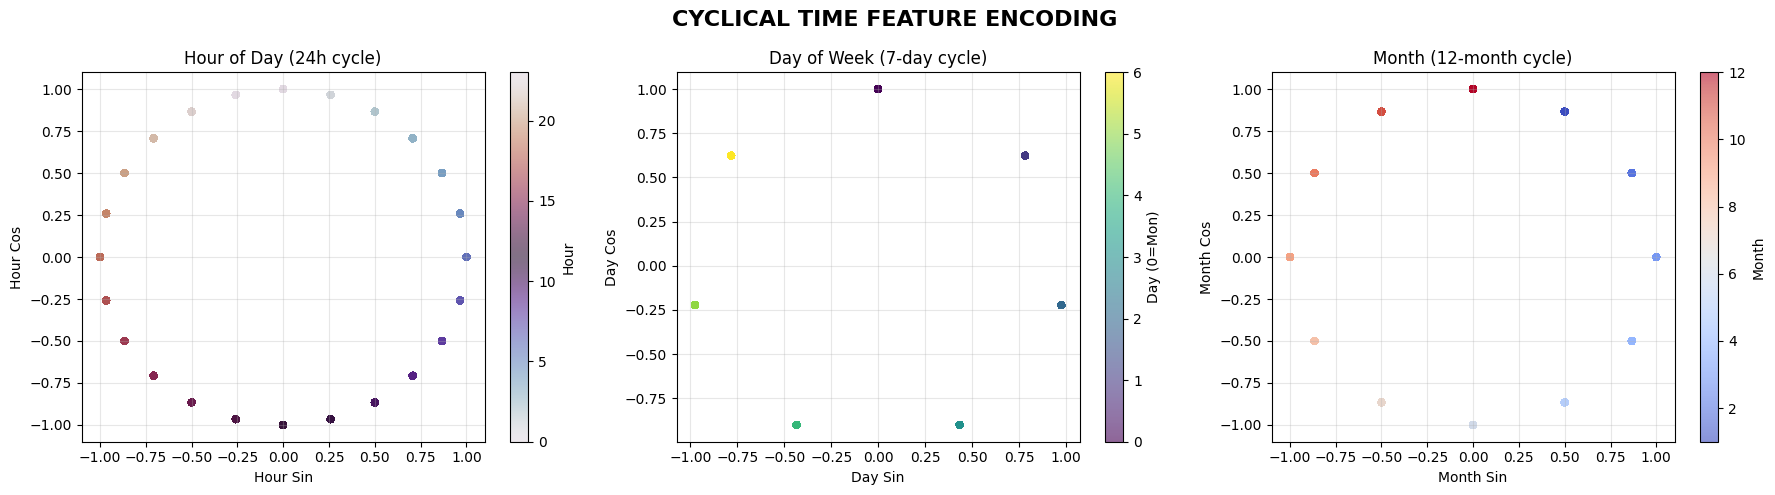


TEMPORAL DISTRIBUTION ANALYSIS:

Hour Distribution:
hour
0     242
1     294
2     358
3     373
4     330
5     343
6     374
7     346
8     266
9     300
10    340
11    419
12    574
13    650
14    659
15    532
16    464
17    437
18    413
19    317
20    273
21    289
22    240
23    178
Name: count, dtype: int64

Day of Week Distribution:
  Monday: 1,243 (13.79%)
  Tuesday: 1,318 (14.63%)
  Wednesday: 1,317 (14.62%)
  Thursday: 1,361 (15.10%)
  Friday: 1,239 (13.75%)
  Saturday: 1,280 (14.20%)
  Sunday: 1,253 (13.91%)

Month Distribution:
  Jan: 746 (8.28%)
  Feb: 657 (7.29%)
  Mar: 717 (7.96%)
  Apr: 631 (7.00%)
  May: 772 (8.57%)
  Jun: 854 (9.48%)
  Jul: 841 (9.33%)
  Aug: 947 (10.51%)
  Sep: 924 (10.25%)
  Oct: 1,000 (11.10%)
  Nov: 506 (5.62%)
  Dec: 416 (4.62%)

✓ TEMPORAL FEATURE EXTRACTION COMPLETE
Total new features created: 9
  • Raw: hour, day_of_week, month (3)
  • Cyclical: hour_sin/cos, day_sin/cos, month_sin/cos (6)

Updated dataset shape: 9,011 rows × 20 colum

In [10]:
# 10: Temporal Feature Extraction - Cyclical Encoding
print("="*80)
print("TEMPORAL FEATURE EXTRACTION - CYCLICAL ENCODING")
print("="*80)

# Convert published_at to datetime
df_shorts['published_at'] = pd.to_datetime(df_shorts['published_at'])

# Extract basic time components
df_shorts['hour'] = df_shorts['published_at'].dt.hour
df_shorts['day_of_week'] = df_shorts['published_at'].dt.dayofweek  # Monday=0, Sunday=6
df_shorts['month'] = df_shorts['published_at'].dt.month

# Create cyclical features using sin/cos transformation
# Hour (24-hour cycle)
df_shorts['hour_sin'] = np.sin(2 * np.pi * df_shorts['hour'] / 24)
df_shorts['hour_cos'] = np.cos(2 * np.pi * df_shorts['hour'] / 24)

# Day of week (7-day cycle)
df_shorts['day_sin'] = np.sin(2 * np.pi * df_shorts['day_of_week'] / 7)
df_shorts['day_cos'] = np.cos(2 * np.pi * df_shorts['day_of_week'] / 7)

# Month (12-month cycle)
df_shorts['month_sin'] = np.sin(2 * np.pi * df_shorts['month'] / 12)
df_shorts['month_cos'] = np.cos(2 * np.pi * df_shorts['month'] / 12)

print("\n✓ Cyclical features created:")
print("  • Hour (sin/cos): Captures 24-hour daily patterns")
print("  • Day of week (sin/cos): Captures weekly patterns")
print("  • Month (sin/cos): Captures seasonal patterns")

# Display sample of new features
print("\nSAMPLE OF TEMPORAL FEATURES:")
print("="*80)
temporal_cols = ['published_at', 'hour', 'hour_sin', 'hour_cos', 
                 'day_of_week', 'day_sin', 'day_cos',
                 'month', 'month_sin', 'month_cos']
display(df_shorts[temporal_cols].head(10))

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CYCLICAL TIME FEATURE ENCODING', fontsize=16, fontweight='bold')

# Hour visualization
scatter1 = axes[0].scatter(df_shorts['hour_sin'], df_shorts['hour_cos'], 
                          c=df_shorts['hour'], cmap='twilight', alpha=0.6, s=20)
axes[0].set_xlabel('Hour Sin')
axes[0].set_ylabel('Hour Cos')
axes[0].set_title('Hour of Day (24h cycle)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Hour')

# Day of week visualization
scatter2 = axes[1].scatter(df_shorts['day_sin'], df_shorts['day_cos'], 
                          c=df_shorts['day_of_week'], cmap='viridis', alpha=0.6, s=20)
axes[1].set_xlabel('Day Sin')
axes[1].set_ylabel('Day Cos')
axes[1].set_title('Day of Week (7-day cycle)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Day (0=Mon)')

# Month visualization
scatter3 = axes[2].scatter(df_shorts['month_sin'], df_shorts['month_cos'], 
                          c=df_shorts['month'], cmap='coolwarm', alpha=0.6, s=20)
axes[2].set_xlabel('Month Sin')
axes[2].set_ylabel('Month Cos')
axes[2].set_title('Month (12-month cycle)')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[2], label='Month')

plt.tight_layout()
plt.show()

# Distribution analysis
print("\nTEMPORAL DISTRIBUTION ANALYSIS:")
print("="*80)

print("\nHour Distribution:")
print(df_shorts['hour'].value_counts().sort_index())

print("\nDay of Week Distribution:")
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_dist = df_shorts['day_of_week'].value_counts().sort_index()
for idx, count in day_dist.items():
    print(f"  {day_names[idx]}: {count:,} ({count/len(df_shorts)*100:.2f}%)")

print("\nMonth Distribution:")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_dist = df_shorts['month'].value_counts().sort_index()
for idx, count in month_dist.items():
    print(f"  {month_names[idx-1]}: {count:,} ({count/len(df_shorts)*100:.2f}%)")

# Summary
print("\n" + "="*80)
print("✓ TEMPORAL FEATURE EXTRACTION COMPLETE")
print("="*80)
print(f"Total new features created: 9")
print(f"  • Raw: hour, day_of_week, month (3)")
print(f"  • Cyclical: hour_sin/cos, day_sin/cos, month_sin/cos (6)")
print(f"\nUpdated dataset shape: {df_shorts.shape[0]:,} rows × {df_shorts.shape[1]} columns")
print("="*80)

#### Transforming "tags" from text into numerical data that works better with Neural Networks. Using Sentence Transformers (SBERT, MiniLM) to capture full tag context

TAG TEXT EMBEDDING - SENTENCE TRANSFORMERS

Loading Sentence Transformer model (all-MiniLM-L6-v2)...

Loading Sentence Transformer model (all-MiniLM-L6-v2)...
✓ Model loaded successfully
  • Embedding dimension: 384
  • Model: all-MiniLM-L6-v2 (lightweight & fast)

TAGS COLUMN INSPECTION:
Data type: object
Sample tags (first 5):
  1. gabesweats, theory, astronauts, top 10 terrifying things said by astronauts, scary astronaut, astronaut, astronauts in space, astronaut encounters, scary astronaut encounters, dark things, things said by astronauts, nasa astronaut, chilling things said by astronauts, things seen byn astronauts, 10 creepiest things seen by astronauts, said by astronauts, hardest tongue twister, hachiko, loyalest dog
  2. Dhruv Rathee, Dhruvrathee, Dhruv Rathee Shorts, Education, Informative
  3. Most amazing facts, interesting facts, 7 amazing facts about science, amazing facts, facts, unbelievable facts in hindi, random facts, top 7 interesting facts, fact education, amazi

Batches:   0%|          | 0/282 [00:00<?, ?it/s]


✓ Embeddings generated successfully!
  • Shape: (9011, 384)
  • Size: 13.20 MB

EMBEDDING STATISTICS:
Embedding dimensions: 384
Mean embedding value: 0.0003
Std embedding value: 0.0510
Min embedding value: -0.2390
Max embedding value: 0.2868


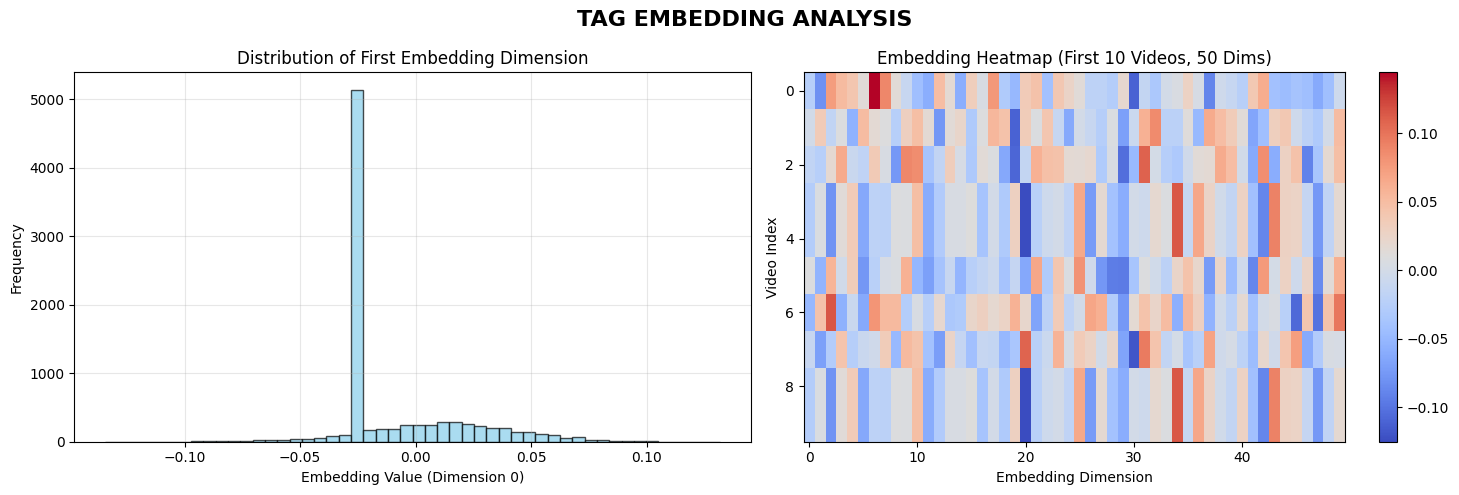


SEMANTIC SIMILARITY DEMO:
Comparing embeddings of videos with different tags...

Video 0:
  Tags: gabesweats, theory, astronauts, top 10 terrifying things said by astronauts, scary astronaut, astron...
  Embedding norm: 1.0000

Video 1:
  Tags: Dhruv Rathee, Dhruvrathee, Dhruv Rathee Shorts, Education, Informative...
  Embedding norm: 1.0000

Video 2:
  Tags: Most amazing facts, interesting facts, 7 amazing facts about science, amazing facts, facts, unbeliev...
  Embedding norm: 1.0000

✓ TAG EMBEDDING COMPLETE
Total features added: 384
  • Original tags column: tags
  • Processed tags: tags_processed
  • Embedding columns: tag_emb_0 to tag_emb_383

Updated dataset shape: 9,011 rows × 405 columns


In [11]:
# 11: Tag Text Embedding using Sentence Transformers
print("="*80)
print("TAG TEXT EMBEDDING - SENTENCE TRANSFORMERS")
print("="*80)

# Install sentence-transformers if needed
# Run in terminal: pip install sentence-transformers

from sentence_transformers import SentenceTransformer
import ast
import os

# Clear any existing HuggingFace token that might be causing issues
os.environ.pop('HF_TOKEN', None)
os.environ.pop('HUGGING_FACE_HUB_TOKEN', None)

# Load pre-trained sentence transformer model
print("\nLoading Sentence Transformer model (all-MiniLM-L6-v2)...")
try:
    # Try loading without authentication
    model = SentenceTransformer('all-MiniLM-L6-v2', token=False)
    print("✓ Model loaded successfully")
except Exception as e:
    print(f"⚠ Error loading model: {e}")
    print("\nTrying alternative loading method...")
    # Alternative: download manually first
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', use_auth_token=False)
    print("✓ Model loaded successfully (alternative method)")

print(f"  • Embedding dimension: 384")
print(f"  • Model: all-MiniLM-L6-v2 (lightweight & fast)")

# Inspect tags column
print("\n" + "="*80)
print("TAGS COLUMN INSPECTION:")
print("="*80)
print(f"Data type: {df_shorts['tags'].dtype}")
print(f"Sample tags (first 5):")
for i, tags in enumerate(df_shorts['tags'].head(5), 1):
    print(f"  {i}. {tags}")

# Handle missing tags
missing_tags = df_shorts['tags'].isnull().sum()
print(f"\nMissing tags: {missing_tags:,} ({missing_tags/len(df_shorts)*100:.2f}%)")

# Fill missing tags with empty string
df_shorts['tags'] = df_shorts['tags'].fillna('')

# Convert tags to string if they're lists/arrays
def process_tags(tags):
    """Convert tags to clean string format"""
    if isinstance(tags, str):
        # If already string, try to parse if it looks like a list
        if tags.startswith('['):
            try:
                tags = ast.literal_eval(tags)
                return ', '.join(tags)
            except:
                return tags
        return tags
    elif isinstance(tags, list):
        return ', '.join(tags)
    else:
        return ''

print("\nProcessing tags into clean text format...")
df_shorts['tags_processed'] = df_shorts['tags'].apply(process_tags)

# Generate embeddings (this may take a few minutes)
print("\n" + "="*80)
print("GENERATING TAG EMBEDDINGS...")
print("="*80)
print(f"Processing {len(df_shorts):,} videos...")
print("⏳ This may take 2-5 minutes depending on dataset size...")

# Encode all tags
tag_embeddings = model.encode(
    df_shorts['tags_processed'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\n✓ Embeddings generated successfully!")
print(f"  • Shape: {tag_embeddings.shape}")
print(f"  • Size: {tag_embeddings.nbytes / 1024**2:.2f} MB")

# Convert to DataFrame for easier handling
tag_embedding_df = pd.DataFrame(
    tag_embeddings,
    columns=[f'tag_emb_{i}' for i in range(tag_embeddings.shape[1])],
    index=df_shorts.index
)

# Add embeddings to main dataframe
df_shorts = pd.concat([df_shorts, tag_embedding_df], axis=1)

print("\n" + "="*80)
print("EMBEDDING STATISTICS:")
print("="*80)
print(f"Embedding dimensions: {tag_embeddings.shape[1]}")
print(f"Mean embedding value: {tag_embeddings.mean():.4f}")
print(f"Std embedding value: {tag_embeddings.std():.4f}")
print(f"Min embedding value: {tag_embeddings.min():.4f}")
print(f"Max embedding value: {tag_embeddings.max():.4f}")

# Visualize embedding distribution (sample)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('TAG EMBEDDING ANALYSIS', fontsize=16, fontweight='bold')

# Distribution of first embedding dimension
axes[0].hist(tag_embeddings[:, 0], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Value (Dimension 0)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of First Embedding Dimension')
axes[0].grid(True, alpha=0.3)

# Heatmap of first 10 videos, first 50 dimensions
sample_embeddings = tag_embeddings[:10, :50]
im = axes[1].imshow(sample_embeddings, cmap='coolwarm', aspect='auto')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Video Index')
axes[1].set_title('Embedding Heatmap (First 10 Videos, 50 Dims)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

# Sample comparison: similar tags should have similar embeddings
print("\n" + "="*80)
print("SEMANTIC SIMILARITY DEMO:")
print("="*80)
print("Comparing embeddings of videos with different tags...")

# Get a few sample videos with tags
sample_indices = df_shorts[df_shorts['tags_processed'].str.len() > 10].head(3).index
for idx in sample_indices:
    tags = df_shorts.loc[idx, 'tags_processed'][:100]  # First 100 chars
    embedding_norm = np.linalg.norm(tag_embeddings[df_shorts.index.get_loc(idx)])
    print(f"\nVideo {idx}:")
    print(f"  Tags: {tags}...")
    print(f"  Embedding norm: {embedding_norm:.4f}")

# Summary
print("\n" + "="*80)
print("✓ TAG EMBEDDING COMPLETE")
print("="*80)
print(f"Total features added: {tag_embeddings.shape[1]}")
print(f"  • Original tags column: tags")
print(f"  • Processed tags: tags_processed")
print(f"  • Embedding columns: tag_emb_0 to tag_emb_{tag_embeddings.shape[1]-1}")
print(f"\nUpdated dataset shape: {df_shorts.shape[0]:,} rows × {df_shorts.shape[1]} columns")
print("="*80)

#### Transforming "description" from text into numerical data that works better with Neural Networks. Using Sentence Transformers (SBERT, MiniLM) to capture full tag context

DESCRIPTION TEXT EMBEDDING - SENTENCE TRANSFORMERS

DESCRIPTION COLUMN INSPECTION:
Data type: object
Sample descriptions (first 3, truncated to 200 chars):
  1. hey it's me gabe (@gabesweats) from tiktok! in this video, i go over the weirdest things astronauts have seen.
make sure to subscribe for more! #shorts

check out my socials:
twitter: gabesweats
twitc...
  2. #shorts 

Link to Main Channel: https://www.youtube.com/dhruvrathee
  3. विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing facts about science #shorts 

#viralshorts #sciencefacts #facts #factstar #facteducation #ytshortsvideo #short #cra#youtubeshorts #amazingfacts #shorts


amaz...

Missing descriptions: 3,296 (36.58%)

Processing descriptions into clean text format...

Description length statistics:
  • Mean length: 375 characters
  • Median length: 116 characters
  • Max length: 5000 characters
  • Min length: 0 characters
  • Empty descriptions: 3,296 (36.58%)

GENERATING DESCRIPTION EMBEDDINGS...
Processing 9,011 videos...
⏳

Batches:   0%|          | 0/282 [00:00<?, ?it/s]


✓ Embeddings generated successfully!
  • Shape: (9011, 384)
  • Size: 13.20 MB

EMBEDDING STATISTICS:
Embedding dimensions: 384
Mean embedding value: 0.0000
Std embedding value: 0.0510
Min embedding value: -0.2554
Max embedding value: 0.4062


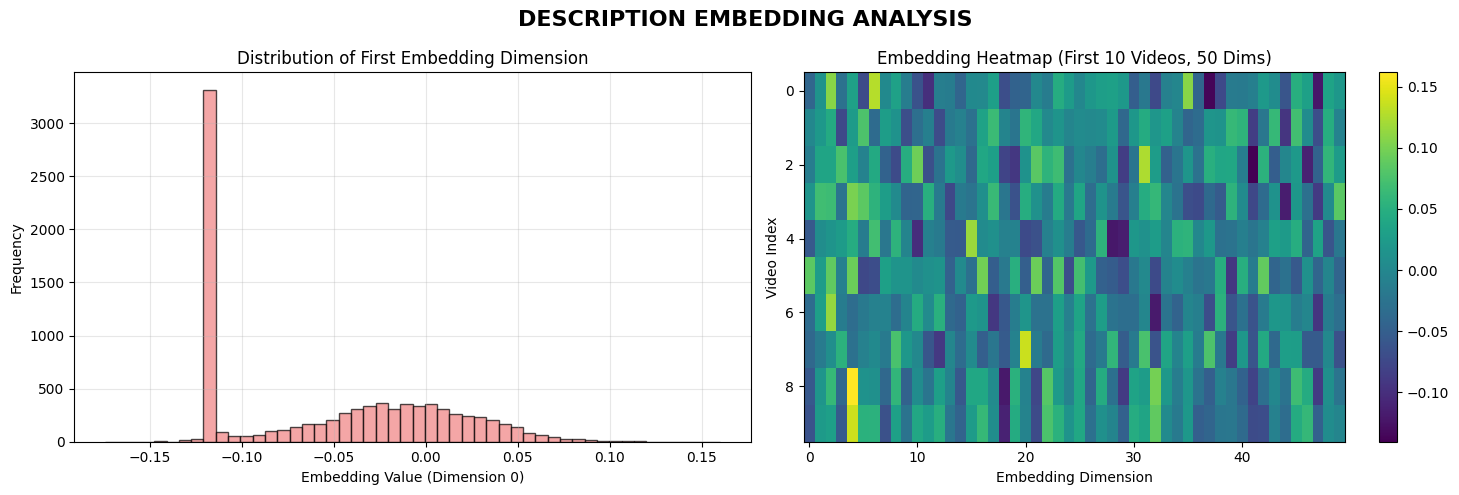


SEMANTIC SIMILARITY DEMO:
Comparing embeddings of videos with different descriptions...

Video 0:
  Description: hey it's me gabe (@gabesweats) from tiktok! in this video, i go over the weirdest things astronauts have seen.
make sure to subscribe for more! #short...
  Embedding norm: 1.0000

Video 1:
  Description: #shorts 

Link to Main Channel: https://www.youtube.com/dhruvrathee...
  Embedding norm: 1.0000

Video 2:
  Description: विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing facts about science #shorts 

#viralshorts #sciencefacts #facts #factstar #facteducation #ytshortsvideo #sho...
  Embedding norm: 1.0000

TAG vs DESCRIPTION EMBEDDING COMPARISON:
Tag embeddings shape: (9011, 384)
Description embeddings shape: (9011, 384)

Both use same 384-dimensional space from all-MiniLM-L6-v2 model
This allows the neural network to learn relationships between tags and descriptions!

✓ DESCRIPTION EMBEDDING COMPLETE
Total features added: 384
  • Original description column: description
  • Proce

In [12]:
# 12: Description Text Embedding using Sentence Transformers
print("="*80)
print("DESCRIPTION TEXT EMBEDDING - SENTENCE TRANSFORMERS")
print("="*80)

# Inspect description column
print("\n" + "="*80)
print("DESCRIPTION COLUMN INSPECTION:")
print("="*80)
print(f"Data type: {df_shorts['description'].dtype}")
print(f"Sample descriptions (first 3, truncated to 200 chars):")
for i, desc in enumerate(df_shorts['description'].head(3), 1):
    desc_preview = str(desc)[:200] + "..." if len(str(desc)) > 200 else str(desc)
    print(f"  {i}. {desc_preview}")

# Handle missing descriptions
missing_desc = df_shorts['description'].isnull().sum()
print(f"\nMissing descriptions: {missing_desc:,} ({missing_desc/len(df_shorts)*100:.2f}%)")

# Fill missing descriptions with empty string
df_shorts['description'] = df_shorts['description'].fillna('')

# Convert descriptions to string and clean
def process_description(desc):
    """Convert description to clean string format"""
    if isinstance(desc, str):
        return desc.strip()
    else:
        return ''

print("\nProcessing descriptions into clean text format...")
df_shorts['description_processed'] = df_shorts['description'].apply(process_description)

# Check description lengths
desc_lengths = df_shorts['description_processed'].str.len()
print(f"\nDescription length statistics:")
print(f"  • Mean length: {desc_lengths.mean():.0f} characters")
print(f"  • Median length: {desc_lengths.median():.0f} characters")
print(f"  • Max length: {desc_lengths.max():.0f} characters")
print(f"  • Min length: {desc_lengths.min():.0f} characters")
print(f"  • Empty descriptions: {(desc_lengths == 0).sum():,} ({(desc_lengths == 0).sum()/len(df_shorts)*100:.2f}%)")

# Generate embeddings (this may take a few minutes)
print("\n" + "="*80)
print("GENERATING DESCRIPTION EMBEDDINGS...")
print("="*80)
print(f"Processing {len(df_shorts):,} videos...")
print("⏳ This may take 3-7 minutes depending on dataset size...")
print("Note: Descriptions are longer than tags, so this will take more time.")

# Encode all descriptions using the same model
desc_embeddings = model.encode(
    df_shorts['description_processed'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\n✓ Embeddings generated successfully!")
print(f"  • Shape: {desc_embeddings.shape}")
print(f"  • Size: {desc_embeddings.nbytes / 1024**2:.2f} MB")

# Convert to DataFrame for easier handling
desc_embedding_df = pd.DataFrame(
    desc_embeddings,
    columns=[f'desc_emb_{i}' for i in range(desc_embeddings.shape[1])],
    index=df_shorts.index
)

# Add embeddings to main dataframe
df_shorts = pd.concat([df_shorts, desc_embedding_df], axis=1)

print("\n" + "="*80)
print("EMBEDDING STATISTICS:")
print("="*80)
print(f"Embedding dimensions: {desc_embeddings.shape[1]}")
print(f"Mean embedding value: {desc_embeddings.mean():.4f}")
print(f"Std embedding value: {desc_embeddings.std():.4f}")
print(f"Min embedding value: {desc_embeddings.min():.4f}")
print(f"Max embedding value: {desc_embeddings.max():.4f}")

# Visualize embedding distribution (sample)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('DESCRIPTION EMBEDDING ANALYSIS', fontsize=16, fontweight='bold')

# Distribution of first embedding dimension
axes[0].hist(desc_embeddings[:, 0], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Value (Dimension 0)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of First Embedding Dimension')
axes[0].grid(True, alpha=0.3)

# Heatmap of first 10 videos, first 50 dimensions
sample_embeddings = desc_embeddings[:10, :50]
im = axes[1].imshow(sample_embeddings, cmap='viridis', aspect='auto')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Video Index')
axes[1].set_title('Embedding Heatmap (First 10 Videos, 50 Dims)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

# Sample comparison: similar descriptions should have similar embeddings
print("\n" + "="*80)
print("SEMANTIC SIMILARITY DEMO:")
print("="*80)
print("Comparing embeddings of videos with different descriptions...")

# Get a few sample videos with descriptions
sample_indices = df_shorts[df_shorts['description_processed'].str.len() > 50].head(3).index
for idx in sample_indices:
    desc = df_shorts.loc[idx, 'description_processed'][:150]  # First 150 chars
    embedding_norm = np.linalg.norm(desc_embeddings[df_shorts.index.get_loc(idx)])
    print(f"\nVideo {idx}:")
    print(f"  Description: {desc}...")
    print(f"  Embedding norm: {embedding_norm:.4f}")

# Compare tag vs description embeddings
print("\n" + "="*80)
print("TAG vs DESCRIPTION EMBEDDING COMPARISON:")
print("="*80)
print(f"Tag embeddings shape: {tag_embeddings.shape}")
print(f"Description embeddings shape: {desc_embeddings.shape}")
print(f"\nBoth use same 384-dimensional space from all-MiniLM-L6-v2 model")
print(f"This allows the neural network to learn relationships between tags and descriptions!")

# Summary
print("\n" + "="*80)
print("✓ DESCRIPTION EMBEDDING COMPLETE")
print("="*80)
print(f"Total features added: {desc_embeddings.shape[1]}")
print(f"  • Original description column: description")
print(f"  • Processed description: description_processed")
print(f"  • Embedding columns: desc_emb_0 to desc_emb_{desc_embeddings.shape[1]-1}")
print(f"\nUpdated dataset shape: {df_shorts.shape[0]:,} rows × {df_shorts.shape[1]} columns")
print("\nCOMBINED TEXT FEATURES:")
print(f"  • Tag embeddings: 384 dimensions")
print(f"  • Description embeddings: 384 dimensions")
print(f"  • Total text embedding features: 768 dimensions")
print("="*80)

#### Thumbnail Image Embedding
##### Convert thumbnails into semantically meaningful, 512-D CLIP embeddings so image content can be fused with text and temporal features to improve prediction models (e.g., trending likelihood) in a compact, comparable way.

THUMBNAIL IMAGE EMBEDDING - CLIP (Vision-Language Model)

Loading CLIP model (openai/clip-vit-base-patch32)...

Loading CLIP model (openai/clip-vit-base-patch32)...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✓ CLIP model loaded successfully
  • Model: CLIP ViT-B/32 (Vision Transformer)
  • Embedding dimension: 512
  • Special feature: Image-Text aligned embeddings!

THUMBNAIL URL INSPECTION:
Data type: object
Sample URLs (first 3):
  1. https://i.ytimg.com/vi/ImWenmB12M8/hqdefault.jpg
  2. https://i.ytimg.com/vi/nw3ALxTRvKc/hqdefault.jpg
  3. https://i.ytimg.com/vi/PzGwXMtw7sI/hqdefault.jpg

Missing thumbnail URLs: 0 (0.00%)

GENERATING THUMBNAIL EMBEDDINGS...
Processing 9,011 thumbnails...
⏳ This may take 10-20 minutes depending on dataset size and internet speed...
Note: Downloading images from URLs - progress will be slower

Processing strategy:
  • Batch processing with progress updates every 50 images
  • Automatic retry on download failures (max 3 attempts)
  • Zero vectors for failed downloads (will note in summary)
  Progress: 0/9,011 (0.0%) | Failed: 0
  Progress: 50/9,011 (0.6%) | Failed: 0
  Progress: 50/9,011 (0.6%) | Failed: 0
  Progress: 100/9,011 (1.1%) | Failed: 0
  Progres

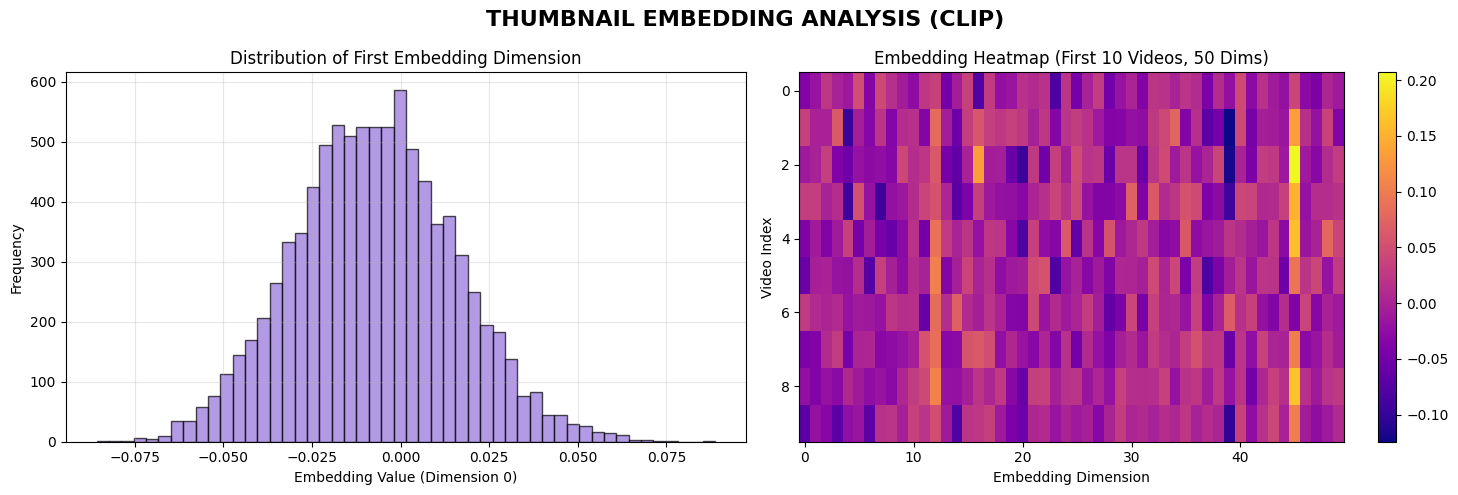


THUMBNAIL EMBEDDING SAMPLES:
Comparing embedding norms (magnitude) for different videos...

Video 0:
  URL: https://i.ytimg.com/vi/ImWenmB12M8/hqdefault.jpg...
  Embedding norm: 1.0000

Video 1:
  URL: https://i.ytimg.com/vi/nw3ALxTRvKc/hqdefault.jpg...
  Embedding norm: 1.0000

Video 2:
  URL: https://i.ytimg.com/vi/PzGwXMtw7sI/hqdefault.jpg...
  Embedding norm: 1.0000

Video 6:
  URL: https://i.ytimg.com/vi/dMT2SH_3KLo/hqdefault.jpg...
  Embedding norm: 1.0000

Video 7:
  URL: https://i.ytimg.com/vi/6NCcrn8NBTs/hqdefault.jpg...
  Embedding norm: 1.0000

CROSS-MODAL FEATURE COMPARISON:
🔥 CLIP creates a unified embedding space for images and text!

Thumbnail embeddings: 512 dimensions
Tag embeddings: 384 dimensions
Description embeddings: 384 dimensions

Note: While CLIP uses 512D and SBERT uses 384D, both capture
semantic meaning. Your neural network will learn to align them!

✓ THUMBNAIL EMBEDDING COMPLETE
Total features added: 512
  • Embedding columns: thumb_emb_0 to thumb_emb_511

In [13]:
# 13: Thumbnail Image Embedding using CLIP
print("="*80)
print("THUMBNAIL IMAGE EMBEDDING - CLIP (Vision-Language Model)")
print("="*80)

# Install required packages if needed
# Run in terminal: pip install transformers pillow requests

from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO
import torch
import os

# Clear any HuggingFace tokens that might be causing auth issues
os.environ.pop('HF_TOKEN', None)
os.environ.pop('HUGGING_FACE_HUB_TOKEN', None)
os.environ.pop('HUGGINGFACE_TOKEN', None)

# Load CLIP model
print("\nLoading CLIP model (openai/clip-vit-base-patch32)...")
try:
    # Load without authentication token
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", token=False)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", token=False)
    print("✓ CLIP model loaded successfully")
    print(f"  • Model: CLIP ViT-B/32 (Vision Transformer)")
    print(f"  • Embedding dimension: 512")
    print(f"  • Special feature: Image-Text aligned embeddings!")
except Exception as e:
    print(f"⚠ Error loading CLIP model: {e}")
    print("\nTrying alternative method (using trust_remote_code)...")
    try:
        clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", 
                                               trust_remote_code=True, 
                                               token=False,
                                               use_auth_token=False)
        clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", 
                                                       trust_remote_code=True,
                                                       token=False,
                                                       use_auth_token=False)
        print("✓ CLIP model loaded successfully (alternative method)")
    except Exception as e2:
        print(f"⚠ Alternative method also failed: {e2}")
        print("\nPlease install required packages:")
        print("  pip install transformers pillow requests torch")
        raise

# Inspect thumbnail_url column
print("\n" + "="*80)
print("THUMBNAIL URL INSPECTION:")
print("="*80)
print(f"Data type: {df_shorts['thumbnail_url'].dtype}")
print(f"Sample URLs (first 3):")
for i, url in enumerate(df_shorts['thumbnail_url'].head(3), 1):
    print(f"  {i}. {url}")

# Check for missing URLs
missing_urls = df_shorts['thumbnail_url'].isnull().sum()
print(f"\nMissing thumbnail URLs: {missing_urls:,} ({missing_urls/len(df_shorts)*100:.2f}%)")

# Function to download and process thumbnail
def download_and_process_thumbnail(url, max_retries=3):
    """
    Download thumbnail from URL and convert to PIL Image
    Returns None if download fails
    """
    if pd.isna(url) or url == '':
        return None
    
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=10, stream=True)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content))
            # Convert to RGB if needed (some images might be RGBA)
            if image.mode != 'RGB':
                image = image.convert('RGB')
            return image
        except Exception as e:
            if attempt == max_retries - 1:
                # Only print errors occasionally to avoid spam
                if np.random.random() < 0.05:  # 5% of failures
                    print(f"  ⚠ Failed: {url[:60]}...")
                return None
            continue
    return None

# Function to generate CLIP embedding for a single image
def get_clip_embedding(image):
    """Generate CLIP embedding for an image"""
    if image is None:
        # Return zero vector for failed downloads
        return np.zeros(512)
    
    try:
        inputs = clip_processor(images=image, return_tensors="pt")
        with torch.no_grad():
            image_features = clip_model.get_image_features(**inputs)
        # Normalize the embedding (CLIP standard practice)
        embedding = image_features / image_features.norm(dim=-1, keepdim=True)
        return embedding.squeeze().numpy()
    except Exception as e:
        # Only print errors occasionally
        if np.random.random() < 0.05:
            print(f"  ⚠ Embedding failed: {str(e)[:30]}...")
        return np.zeros(512)

# Generate embeddings with progress tracking
print("\n" + "="*80)
print("GENERATING THUMBNAIL EMBEDDINGS...")
print("="*80)
print(f"Processing {len(df_shorts):,} thumbnails...")
print("⏳ This may take 10-20 minutes depending on dataset size and internet speed...")
print("Note: Downloading images from URLs - progress will be slower")
print("\nProcessing strategy:")
print("  • Batch processing with progress updates every 50 images")
print("  • Automatic retry on download failures (max 3 attempts)")
print("  • Zero vectors for failed downloads (will note in summary)")

thumbnail_embeddings = []
failed_downloads = 0
batch_size = 50

for idx, url in enumerate(df_shorts['thumbnail_url'].tolist()):
    # Progress update every batch
    if idx % batch_size == 0:
        progress = (idx / len(df_shorts)) * 100
        print(f"  Progress: {idx:,}/{len(df_shorts):,} ({progress:.1f}%) | Failed: {failed_downloads}")
    
    # Download and process image
    image = download_and_process_thumbnail(url)
    if image is None:
        failed_downloads += 1
    
    # Generate embedding
    embedding = get_clip_embedding(image)
    thumbnail_embeddings.append(embedding)

# Convert to numpy array
thumbnail_embeddings = np.array(thumbnail_embeddings)

print(f"\n✓ Embeddings generated successfully!")
print(f"  • Shape: {thumbnail_embeddings.shape}")
print(f"  • Size: {thumbnail_embeddings.nbytes / 1024**2:.2f} MB")
print(f"  • Failed downloads: {failed_downloads:,} ({failed_downloads/len(df_shorts)*100:.2f}%)")
print(f"  • Successful: {len(df_shorts) - failed_downloads:,} ({(len(df_shorts)-failed_downloads)/len(df_shorts)*100:.2f}%)")

# Convert to DataFrame
thumbnail_embedding_df = pd.DataFrame(
    thumbnail_embeddings,
    columns=[f'thumb_emb_{i}' for i in range(thumbnail_embeddings.shape[1])],
    index=df_shorts.index
)

# Add embeddings to main dataframe
df_shorts = pd.concat([df_shorts, thumbnail_embedding_df], axis=1)

print("\n" + "="*80)
print("EMBEDDING STATISTICS:")
print("="*80)
print(f"Embedding dimensions: {thumbnail_embeddings.shape[1]}")
print(f"Mean embedding value: {thumbnail_embeddings.mean():.4f}")
print(f"Std embedding value: {thumbnail_embeddings.std():.4f}")
print(f"Min embedding value: {thumbnail_embeddings.min():.4f}")
print(f"Max embedding value: {thumbnail_embeddings.max():.4f}")

# Check for zero vectors (failed downloads)
zero_vectors = np.all(thumbnail_embeddings == 0, axis=1).sum()
print(f"\nZero vectors (failed embeddings): {zero_vectors:,}")

# Visualize embedding distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('THUMBNAIL EMBEDDING ANALYSIS (CLIP)', fontsize=16, fontweight='bold')

# Distribution of first embedding dimension
axes[0].hist(thumbnail_embeddings[:, 0], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Value (Dimension 0)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of First Embedding Dimension')
axes[0].grid(True, alpha=0.3)

# Heatmap of first 10 videos, first 50 dimensions
sample_embeddings = thumbnail_embeddings[:10, :50]
im = axes[1].imshow(sample_embeddings, cmap='plasma', aspect='auto')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Video Index')
axes[1].set_title('Embedding Heatmap (First 10 Videos, 50 Dims)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

# Sample comparison
print("\n" + "="*80)
print("THUMBNAIL EMBEDDING SAMPLES:")
print("="*80)
print("Comparing embedding norms (magnitude) for different videos...")

# Get sample videos with successful embeddings
successful_mask = ~np.all(thumbnail_embeddings == 0, axis=1)
sample_indices = df_shorts[successful_mask].head(5).index

for idx in sample_indices:
    url = df_shorts.loc[idx, 'thumbnail_url'][:70]
    embedding_norm = np.linalg.norm(thumbnail_embeddings[df_shorts.index.get_loc(idx)])
    print(f"\nVideo {idx}:")
    print(f"  URL: {url}...")
    print(f"  Embedding norm: {embedding_norm:.4f}")

# Cross-modal comparison: Thumbnails vs Text
print("\n" + "="*80)
print("CROSS-MODAL FEATURE COMPARISON:")
print("="*80)
print("🔥 CLIP creates a unified embedding space for images and text!")
print(f"\nThumbnail embeddings: {thumbnail_embeddings.shape[1]} dimensions")
print(f"Tag embeddings: {tag_embeddings.shape[1]} dimensions")
print(f"Description embeddings: {desc_embeddings.shape[1]} dimensions")
print(f"\nNote: While CLIP uses 512D and SBERT uses 384D, both capture")
print(f"semantic meaning. Your neural network will learn to align them!")

# Summary
print("\n" + "="*80)
print("✓ THUMBNAIL EMBEDDING COMPLETE")
print("="*80)
print(f"Total features added: {thumbnail_embeddings.shape[1]}")
print(f"  • Embedding columns: thumb_emb_0 to thumb_emb_{thumbnail_embeddings.shape[1]-1}")
print(f"  • Model: OpenAI CLIP ViT-B/32")
print(f"  • Embedding space: Image-Text aligned (512D)")
print(f"\nUpdated dataset shape: {df_shorts.shape[0]:,} rows × {df_shorts.shape[1]} columns")
print("\nCOMBINED MULTIMODAL FEATURES:")
print(f"  • Thumbnail embeddings (CLIP): 512 dimensions")
print(f"  • Tag embeddings (SBERT): 384 dimensions")
print(f"  • Description embeddings (SBERT): 384 dimensions")
print(f"  • Total embedding features: 1,280 dimensions")
print(f"  • Plus temporal features: 9 dimensions")
print(f"  • Plus metadata: ~10 dimensions")
print(f"  📊 TOTAL INPUT FEATURES: ~1,300 dimensions for neural network!")
print("="*80)

# Optional: Save checkpoint
print("\n💾 Saving checkpoint with all embeddings...")
checkpoint_path = r'C:\Users\akato\Desktop\NE MSDAE\IE 7945\YouTube Analysis Project\Data_Space_Science\df_shorts_with_embeddings.pkl'
df_shorts.to_pickle(checkpoint_path)
print(f"✓ Checkpoint saved: {checkpoint_path}")
print(f"  Size: {os.path.getsize(checkpoint_path) / 1024**2:.2f} MB")

#### Transforming "title" from text into numerical data that works better with Neural Networks. Using Sentence Transformers (SBERT, MiniLM) to capture full tag context

TITLE TEXT EMBEDDING - SENTENCE TRANSFORMERS

TITLE COLUMN INSPECTION:
Data type: object
Sample titles (first 3, truncated to 100 chars):
  1. weirdest things astronauts have seen
  2. Biggest Volcano Eruption of 21st Century
  3. विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing facts about science #shorts

Missing titles: 0 (0.00%)

Processing titles into clean text format...

Title length statistics:
  • Mean length: 75 characters
  • Median length: 78 characters
  • Max length: 100 characters
  • Min length: 10 characters
  • Empty titles: 0 (0.00%)

GENERATING TITLE EMBEDDINGS...
Processing 9,011 videos...
⏳ This may take 2-5 minutes depending on dataset size...
Note: Titles are typically shorter than descriptions, so this should be faster.


Batches:   0%|          | 0/282 [00:00<?, ?it/s]


✓ Embeddings generated successfully!
  • Shape: (9011, 384)
  • Size: 13.20 MB

EMBEDDING STATISTICS:
Embedding dimensions: 384
Mean embedding value: -0.0007
Std embedding value: 0.0510
Min embedding value: -0.2302
Max embedding value: 0.2451


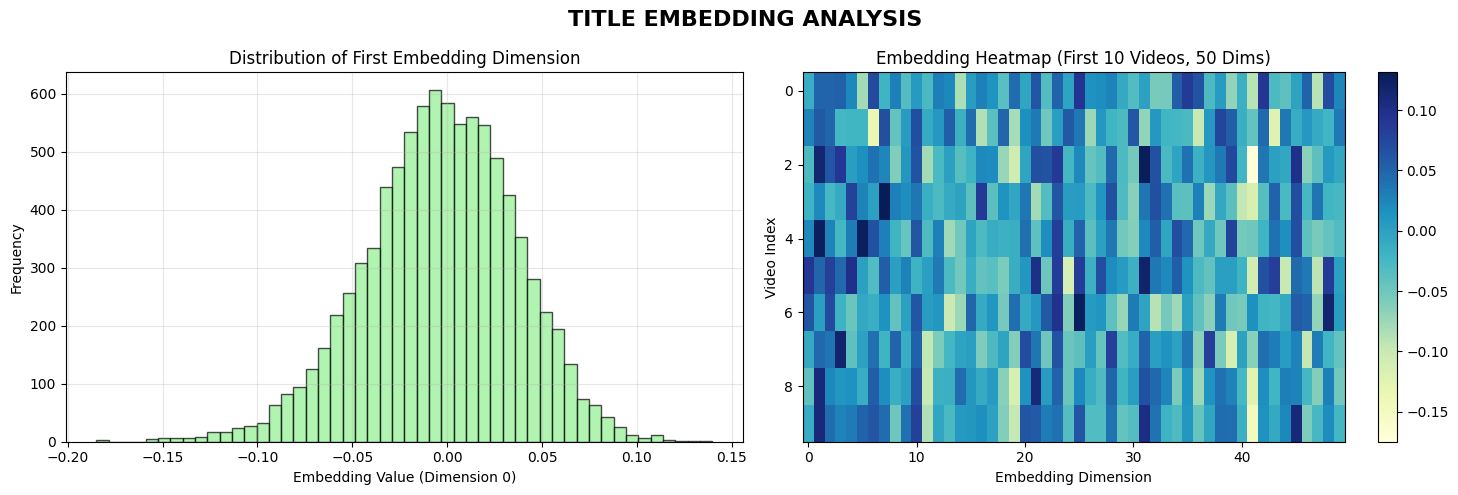


SEMANTIC SIMILARITY DEMO:
Comparing embeddings of videos with different titles...

Video 0:
  Title: weirdest things astronauts have seen...
  Embedding norm: 1.0000

Video 1:
  Title: Biggest Volcano Eruption of 21st Century...
  Embedding norm: 1.0000

Video 2:
  Title: विज्ञान से जुड़ी दिलचस्प बाते | 7 Amazing facts about science #shorts...
  Embedding norm: 1.0000

TITLE vs TAG vs DESCRIPTION EMBEDDING COMPARISON:
Title embeddings shape: (9011, 384)
Tag embeddings shape: (9011, 384)
Description embeddings shape: (9011, 384)

All use same 384-dimensional space from all-MiniLM-L6-v2 model
This allows the neural network to learn relationships between titles, tags, and descriptions!

✓ TITLE EMBEDDING COMPLETE
Total features added: 384
  • Original title column: title
  • Processed title: title_processed
  • Embedding columns: title_emb_0 to title_emb_383

Updated dataset shape: 9,011 rows × 1687 columns

COMBINED TEXT FEATURES:
  • Title embeddings: 384 dimensions
  • Tag embeddings:

In [14]:
# 14: Title Text Embedding using Sentence Transformers
print("="*80)
print("TITLE TEXT EMBEDDING - SENTENCE TRANSFORMERS")
print("="*80)

# Inspect title column
print("\n" + "="*80)
print("TITLE COLUMN INSPECTION:")
print("="*80)
print(f"Data type: {df_shorts['title'].dtype}")
print(f"Sample titles (first 3, truncated to 100 chars):")
for i, title in enumerate(df_shorts['title'].head(3), 1):
    title_preview = str(title)[:100] + "..." if len(str(title)) > 100 else str(title)
    print(f"  {i}. {title_preview}")

# Handle missing titles
missing_title = df_shorts['title'].isnull().sum()
print(f"\nMissing titles: {missing_title:,} ({missing_title/len(df_shorts)*100:.2f}%)")

# Fill missing titles with empty string
df_shorts['title'] = df_shorts['title'].fillna('')

# Convert titles to string and clean
def process_title(title):
    """Convert title to clean string format"""
    if isinstance(title, str):
        return title.strip()
    else:
        return ''

print("\nProcessing titles into clean text format...")
df_shorts['title_processed'] = df_shorts['title'].apply(process_title)

# Check title lengths
title_lengths = df_shorts['title_processed'].str.len()
print(f"\nTitle length statistics:")
print(f"  • Mean length: {title_lengths.mean():.0f} characters")
print(f"  • Median length: {title_lengths.median():.0f} characters")
print(f"  • Max length: {title_lengths.max():.0f} characters")
print(f"  • Min length: {title_lengths.min():.0f} characters")
print(f"  • Empty titles: {(title_lengths == 0).sum():,} ({(title_lengths == 0).sum()/len(df_shorts)*100:.2f}%)")

# Generate embeddings (this may take a few minutes)
print("\n" + "="*80)
print("GENERATING TITLE EMBEDDINGS...")
print("="*80)
print(f"Processing {len(df_shorts):,} videos...")
print("⏳ This may take 2-5 minutes depending on dataset size...")
print("Note: Titles are typically shorter than descriptions, so this should be faster.")

# Encode all titles using the same model
title_embeddings = model.encode(
    df_shorts['title_processed'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\n✓ Embeddings generated successfully!")
print(f"  • Shape: {title_embeddings.shape}")
print(f"  • Size: {title_embeddings.nbytes / 1024**2:.2f} MB")

# Convert to DataFrame for easier handling
title_embedding_df = pd.DataFrame(
    title_embeddings,
    columns=[f'title_emb_{i}' for i in range(title_embeddings.shape[1])],
    index=df_shorts.index
)

# Add embeddings to main dataframe
df_shorts = pd.concat([df_shorts, title_embedding_df], axis=1)

print("\n" + "="*80)
print("EMBEDDING STATISTICS:")
print("="*80)
print(f"Embedding dimensions: {title_embeddings.shape[1]}")
print(f"Mean embedding value: {title_embeddings.mean():.4f}")
print(f"Std embedding value: {title_embeddings.std():.4f}")
print(f"Min embedding value: {title_embeddings.min():.4f}")
print(f"Max embedding value: {title_embeddings.max():.4f}")

# Visualize embedding distribution (sample)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('TITLE EMBEDDING ANALYSIS', fontsize=16, fontweight='bold')

# Distribution of first embedding dimension
axes[0].hist(title_embeddings[:, 0], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Value (Dimension 0)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of First Embedding Dimension')
axes[0].grid(True, alpha=0.3)

# Heatmap of first 10 videos, first 50 dimensions
sample_embeddings = title_embeddings[:10, :50]
im = axes[1].imshow(sample_embeddings, cmap='YlGnBu', aspect='auto')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Video Index')
axes[1].set_title('Embedding Heatmap (First 10 Videos, 50 Dims)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

# Sample comparison: similar titles should have similar embeddings
print("\n" + "="*80)
print("SEMANTIC SIMILARITY DEMO:")
print("="*80)
print("Comparing embeddings of videos with different titles...")

# Get a few sample videos with titles
sample_indices = df_shorts[df_shorts['title_processed'].str.len() > 10].head(3).index
for idx in sample_indices:
    title = df_shorts.loc[idx, 'title_processed'][:80]  # First 80 chars
    embedding_norm = np.linalg.norm(title_embeddings[df_shorts.index.get_loc(idx)])
    print(f"\nVideo {idx}:")
    print(f"  Title: {title}...")
    print(f"  Embedding norm: {embedding_norm:.4f}")

# Compare title vs tag vs description embeddings
print("\n" + "="*80)
print("TITLE vs TAG vs DESCRIPTION EMBEDDING COMPARISON:")
print("="*80)
print(f"Title embeddings shape: {title_embeddings.shape}")
print(f"Tag embeddings shape: {tag_embeddings.shape}")
print(f"Description embeddings shape: {desc_embeddings.shape}")
print(f"\nAll use same 384-dimensional space from all-MiniLM-L6-v2 model")
print(f"This allows the neural network to learn relationships between titles, tags, and descriptions!")

# Summary
print("\n" + "="*80)
print("✓ TITLE EMBEDDING COMPLETE")
print("="*80)
print(f"Total features added: {title_embeddings.shape[1]}")
print(f"  • Original title column: title")
print(f"  • Processed title: title_processed")
print(f"  • Embedding columns: title_emb_0 to title_emb_{title_embeddings.shape[1]-1}")
print(f"\nUpdated dataset shape: {df_shorts.shape[0]:,} rows × {df_shorts.shape[1]} columns")
print("\nCOMBINED TEXT FEATURES:")
print(f"  • Title embeddings: 384 dimensions")
print(f"  • Tag embeddings: 384 dimensions")
print(f"  • Description embeddings: 384 dimensions")
print(f"  • Total text embedding features: 1,152 dimensions")
print("="*80)

### Training Dataset Preparation/ Feature Selection
#### Prepare feature matrix for neural network training

PREPARING TRAINING DATAFRAME - FEATURE SELECTION

 FEATURE SELECTION:
✓ Temporal features: 6
  ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']

✓ Title embeddings: 384 dimensions
✓ Tag embeddings: 384 dimensions
✓ Description embeddings: 384 dimensions
✓ Thumbnail embeddings: 512 dimensions

FEATURE SUMMARY:
 Total input features: 1,670
  • Temporal: 6
  • Title embeddings: 384
  • Tag embeddings: 384
  • Description embeddings: 384
  • Thumbnail embeddings: 512

 Target variable: view_count
 Identifier: video_id

VALIDATING FEATURES:
✓ All features validated successfully!

CREATING TRAINING DATAFRAME:
✓ Training dataframe created
  • Shape: 9,011 rows × 1,672 columns
✓ Training dataframe created
  • Shape: 9,011 rows × 1,672 columns
  • Memory: 76.18 MB

✓ No missing values in training dataframe!

TRAINING DATAFRAME SAMPLE:

First 5 rows (showing identifier + first 10 features + target):
  • Memory: 76.18 MB

✓ No missing values in training dataframe!

TRAININ

,video_id,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,title_emb_0,title_emb_1,title_emb_2,title_emb_3,view_count
0,ImWenmB12M8,-0.707107,-0.707107,0.974928,-0.222521,0.866025,0.5,-0.012423,0.049922,0.049703,0.051728,30788396
1,nw3ALxTRvKc,-0.500000,-0.866025,0.433884,-0.900969,0.866025,0.5,0.026330,0.059488,0.048042,-0.024038,13040241
2,PzGwXMtw7sI,-0.707107,-0.707107,0.433884,-0.900969,0.866025,0.5,-0.029098,0.114565,0.062922,0.089583,7752516
6,dMT2SH_3KLo,-0.500000,-0.866025,-0.433884,-0.900969,0.866025,0.5,-0.018508,0.021623,-0.026130,-0.010248,2195975
7,6NCcrn8NBTs,0.258819,-0.965926,0.974928,-0.222521,0.866025,0.5,0.022411,0.125584,0.026338,-0.025049,1439139



DATA TYPES:
float32    1152
float64     518
object        1
int64         1
Name: count, dtype: int64

INPUT FEATURES STATISTICS:

Summary of 1,670 input features:
  • Mean: -0.000604
  • Std: 0.037603
  • Min: -1.000000
  • Max: 1.000000

TARGET VARIABLE STATISTICS:

Target: view_count
count    9.011000e+03
mean     4.392977e+05
std      3.469900e+06
min      1.000000e+02
25%      5.500000e+02
50%      1.338000e+03
75%      5.083500e+03
max      1.700552e+08
Name: view_count, dtype: float64

Summary of 1,670 input features:
  • Mean: -0.000604
  • Std: 0.037603
  • Min: -1.000000
  • Max: 1.000000

TARGET VARIABLE STATISTICS:

Target: view_count
count    9.011000e+03
mean     4.392977e+05
std      3.469900e+06
min      1.000000e+02
25%      5.500000e+02
50%      1.338000e+03
75%      5.083500e+03
max      1.700552e+08
Name: view_count, dtype: float64


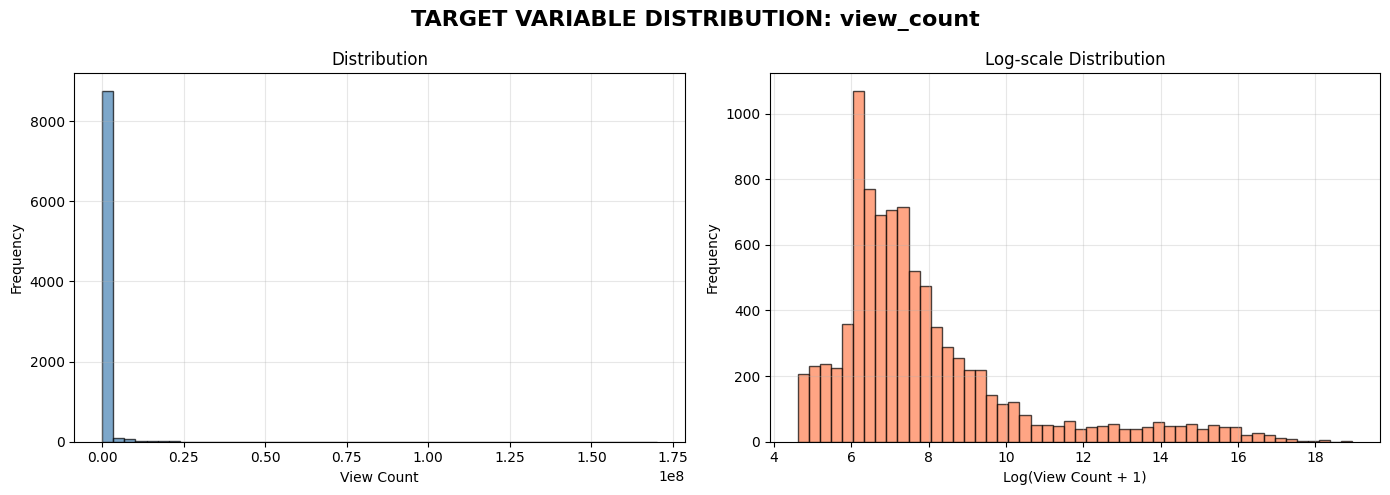


✓ TRAINING DATAFRAME PREPARATION COMPLETE
Ready for train-test split with:
  • 9,011 samples
  • 1,670 input features
  • 1 target variable (view_count)
  • 1 identifier (video_id)


In [15]:
# 15: Prepare Training DataFrame with Feature Selection
print("="*80)
print("PREPARING TRAINING DATAFRAME - FEATURE SELECTION")
print("="*80)

# Define feature categories
print("\n FEATURE SELECTION:")
print("="*80)

# 1. Temporal features (cyclical encoding)
temporal_features = [
    'hour_sin', 'hour_cos',
    'day_sin', 'day_cos',
    'month_sin', 'month_cos'
]
print(f"✓ Temporal features: {len(temporal_features)}")
print(f"  {temporal_features}")

# 2. Title embedding features
title_emb_features = [f'title_emb_{i}' for i in range(384)]
print(f"\n✓ Title embeddings: {len(title_emb_features)} dimensions")

# 3. Tag embedding features
tag_emb_features = [f'tag_emb_{i}' for i in range(384)]
print(f"✓ Tag embeddings: {len(tag_emb_features)} dimensions")

# 4. Description embedding features
desc_emb_features = [f'desc_emb_{i}' for i in range(384)]
print(f"✓ Description embeddings: {len(desc_emb_features)} dimensions")

# 5. Thumbnail embedding features
thumb_emb_features = [f'thumb_emb_{i}' for i in range(512)]
print(f"✓ Thumbnail embeddings: {len(thumb_emb_features)} dimensions")

# Combine all input features
input_features = (
    temporal_features +
    title_emb_features +
    tag_emb_features +
    desc_emb_features +
    thumb_emb_features
)

# Identifier and target
identifier = 'video_id'
target = 'view_count'

print("\n" + "="*80)
print("FEATURE SUMMARY:")
print("="*80)
print(f" Total input features: {len(input_features):,}")
print(f"  • Temporal: {len(temporal_features)}")
print(f"  • Title embeddings: {len(title_emb_features)}")
print(f"  • Tag embeddings: {len(tag_emb_features)}")
print(f"  • Description embeddings: {len(desc_emb_features)}")
print(f"  • Thumbnail embeddings: {len(thumb_emb_features)}")
print(f"\n Target variable: {target}")
print(f" Identifier: {identifier}")

# Verify all features exist in dataframe
print("\n" + "="*80)
print("VALIDATING FEATURES:")
print("="*80)

missing_features = []
for feature in input_features + [target, identifier]:
    if feature not in df_shorts.columns:
        missing_features.append(feature)

if missing_features:
    print(f"⚠ WARNING: {len(missing_features)} features not found in dataframe:")
    for feat in missing_features[:10]:  # Show first 10
        print(f"  • {feat}")
    if len(missing_features) > 10:
        print(f"  ... and {len(missing_features) - 10} more")
else:
    print("✓ All features validated successfully!")

# Create training dataframe
print("\n" + "="*80)
print("CREATING TRAINING DATAFRAME:")
print("="*80)

# Select features (input + target + identifier)
df_train = df_shorts[[identifier] + input_features + [target]].copy()

print(f"✓ Training dataframe created")
print(f"  • Shape: {df_train.shape[0]:,} rows × {df_train.shape[1]:,} columns")
print(f"  • Memory: {df_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Check for missing values
missing_check = df_train.isnull().sum()
if missing_check.sum() > 0:
    print(f"\n⚠ Found {missing_check.sum():,} missing values:")
    print(missing_check[missing_check > 0])
else:
    print("\n✓ No missing values in training dataframe!")

# Display sample
print("\n" + "="*80)
print("TRAINING DATAFRAME SAMPLE:")
print("="*80)
print("\nFirst 5 rows (showing identifier + first 10 features + target):")
sample_cols = [identifier] + input_features[:10] + [target]
display(df_train[sample_cols].head())

# Data types check
print("\n" + "="*80)
print("DATA TYPES:")
print("="*80)
dtype_counts = df_train.dtypes.value_counts()
print(dtype_counts)

# Summary statistics for input features
print("\n" + "="*80)
print("INPUT FEATURES STATISTICS:")
print("="*80)
feature_stats = df_train[input_features].describe().T
print(f"\nSummary of {len(input_features):,} input features:")
print(f"  • Mean: {feature_stats['mean'].mean():.6f}")
print(f"  • Std: {feature_stats['std'].mean():.6f}")
print(f"  • Min: {feature_stats['min'].min():.6f}")
print(f"  • Max: {feature_stats['max'].max():.6f}")

# Target variable statistics
print("\n" + "="*80)
print("TARGET VARIABLE STATISTICS:")
print("="*80)
print(f"\nTarget: {target}")
print(df_train[target].describe())

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'TARGET VARIABLE DISTRIBUTION: {target}', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df_train[target], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('View Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution')
axes[0].grid(True, alpha=0.3)

# Log-scale histogram (better for skewed data)
axes[1].hist(np.log1p(df_train[target]), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(View Count + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-scale Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*80)
print("✓ TRAINING DATAFRAME PREPARATION COMPLETE")
print("="*80)
print(f"Ready for train-test split with:")
print(f"  • {df_train.shape[0]:,} samples")
print(f"  • {len(input_features):,} input features")
print(f"  • 1 target variable ({target})")
print(f"  • 1 identifier ({identifier})")
print("="*80)

### Train-Test Split
Perform stratified split with 80-20 ratio for model training and evaluation

TRAIN-TEST SPLIT

⚙ SPLIT CONFIGURATION:
  • Test size: 20%
  • Random state: 42
  • Stratification bins: 10

CREATING STRATIFICATION BINS:
✓ Created 10 stratification bins

Bin distribution:
  Bin 0: 902 samples (10.0%)
  Bin 1: 903 samples (10.0%)
  Bin 2: 900 samples (10.0%)
  Bin 3: 901 samples (10.0%)
  Bin 4: 900 samples (10.0%)
  Bin 5: 903 samples (10.0%)
  Bin 6: 900 samples (10.0%)
  Bin 7: 900 samples (10.0%)
  Bin 8: 901 samples (10.0%)
  Bin 9: 901 samples (10.0%)

PREPARING FEATURES AND TARGET:
✓ Feature matrix (X): (9011, 1670)
✓ Target vector (y): (9011,)
✓ Video IDs: (9011,)
✓ Stratification labels: (9011,)

PERFORMING TRAIN-TEST SPLIT:
✓ Split completed successfully!

📊 TRAIN SET:
  • Samples: 7,208
  • Features: 1,670
  • Target range: [100, 170,055,190]
  • Target mean: 442,329.07
  • Target median: 1,338.50
  • Target std: 3,519,943.43

📊 TEST SET:
  • Samples: 1,803
  • Features: 1,670
  • Target range: [100, 84,820,251]
  • Target mean: 427,179.17
  • Target medi

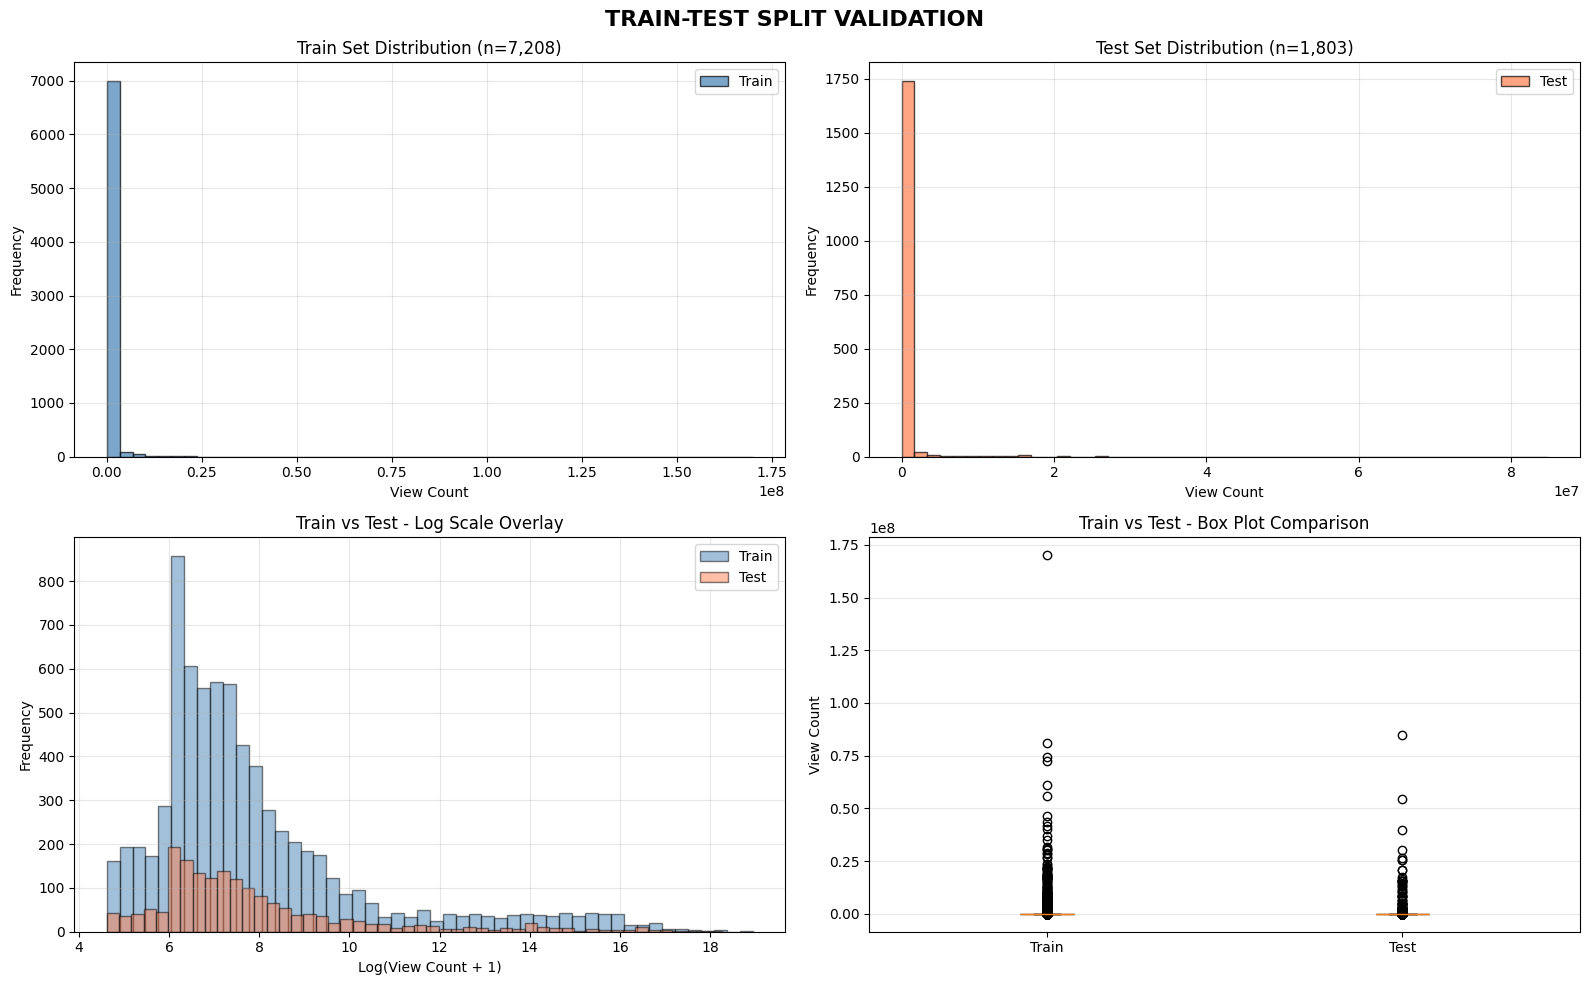


DISTRIBUTION COMPARISON:


,Metric,Train,Test,Difference %
0,Count,7.208000e+03,1.803000e+03,-74.99
1,Mean,4.423291e+05,4.271792e+05,-3.43
2,Median,1.338500e+03,1.338000e+03,-0.04
3,Std,3.519943e+06,3.261126e+06,-7.35
4,Min,1.000000e+02,1.000000e+02,0.00
5,25%,5.500000e+02,5.475000e+02,-0.45
6,50%,1.338500e+03,1.338000e+03,-0.04
7,75%,5.108750e+03,4.997500e+03,-2.18
8,Max,1.700552e+08,8.482025e+07,-50.12



FEATURE NORMALIZATION:
✓ Features standardized (mean=0, std=1)
  Train mean: -0.000000, std: 1.000000
  Test mean: 0.000362, std: 0.998077

TARGET TRANSFORMATION:
✓ Log transformation: log(view_count + 1)
  Original - Train mean: 442,329, Test mean: 427,179
  Log scale - Train mean: 7.8846, Test mean: 7.8669
  Skewness reduced: 23.64 → 1.73

CREATING PYTORCH DATASETS:
✓ PyTorch datasets created
  Train: 7,208 samples, 113 batches
  Test: 1,803 samples, 29 batches
  Batch size: 64

✓ DATA PREPARATION COMPLETE - READY FOR TRAINING
Training data:
  • Samples: 7,208
  • Features: 1,670 (normalized)
  • Target: log(view_count) - normalized distribution

Test data:
  • Samples: 1,803
  • Features: 1,670 (normalized)
  • Target: log(view_count) - normalized distribution
✓ Features standardized (mean=0, std=1)
  Train mean: -0.000000, std: 1.000000
  Test mean: 0.000362, std: 0.998077

TARGET TRANSFORMATION:
✓ Log transformation: log(view_count + 1)
  Original - Train mean: 442,329, Test mean

In [16]:
# 16: Train-Test Split with Stratification
from sklearn.model_selection import train_test_split

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Configuration
TEST_SIZE = 0.2
RANDOM_STATE = 42
STRATIFY_BINS = 10

print(f"\n⚙ SPLIT CONFIGURATION:")
print(f"  • Test size: {TEST_SIZE*100:.0f}%")
print(f"  • Random state: {RANDOM_STATE}")
print(f"  • Stratification bins: {STRATIFY_BINS}")

# Create stratification bins for view_count (continuous target)
# This ensures similar distribution of view counts in train and test sets
print("\n" + "="*80)
print("CREATING STRATIFICATION BINS:")
print("="*80)

# Use quantile-based binning for stratification
df_train['view_count_bins'] = pd.qcut(
    df_train[target], 
    q=STRATIFY_BINS, 
    labels=False, 
    duplicates='drop'
)

bin_counts = df_train['view_count_bins'].value_counts().sort_index()
print(f"✓ Created {len(bin_counts)} stratification bins")
print(f"\nBin distribution:")
for bin_idx, count in bin_counts.items():
    print(f"  Bin {bin_idx}: {count:,} samples ({count/len(df_train)*100:.1f}%)")

# Prepare features and target
print("\n" + "="*80)
print("PREPARING FEATURES AND TARGET:")
print("="*80)

X = df_train[input_features].values
y = df_train[target].values
video_ids = df_train[identifier].values
stratify_labels = df_train['view_count_bins'].values

print(f"✓ Feature matrix (X): {X.shape}")
print(f"✓ Target vector (y): {y.shape}")
print(f"✓ Video IDs: {video_ids.shape}")
print(f"✓ Stratification labels: {stratify_labels.shape}")

# Perform train-test split
print("\n" + "="*80)
print("PERFORMING TRAIN-TEST SPLIT:")
print("="*80)

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, video_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels
)

print(f"✓ Split completed successfully!")
print(f"\n📊 TRAIN SET:")
print(f"  • Samples: {X_train.shape[0]:,}")
print(f"  • Features: {X_train.shape[1]:,}")
print(f"  • Target range: [{y_train.min():,.0f}, {y_train.max():,.0f}]")
print(f"  • Target mean: {y_train.mean():,.2f}")
print(f"  • Target median: {np.median(y_train):,.2f}")
print(f"  • Target std: {y_train.std():,.2f}")

print(f"\n📊 TEST SET:")
print(f"  • Samples: {X_test.shape[0]:,}")
print(f"  • Features: {X_test.shape[1]:,}")
print(f"  • Target range: [{y_test.min():,.0f}, {y_test.max():,.0f}]")
print(f"  • Target mean: {y_test.mean():,.2f}")
print(f"  • Target median: {np.median(y_test):,.2f}")
print(f"  • Target std: {y_test.std():,.2f}")

print(f"\n📏 SPLIT RATIO:")
print(f"  • Train: {len(X_train)/len(X)*100:.1f}%")
print(f"  • Test: {len(X_test)/len(X)*100:.1f}%")

# Verify stratification
print("\n" + "="*80)
print("VERIFYING STRATIFICATION:")
print("="*80)

# Compare target distributions using KS test
from scipy import stats

ks_statistic, ks_pvalue = stats.ks_2samp(y_train, y_test)
print(f"Kolmogorov-Smirnov Test:")
print(f"  • Statistic: {ks_statistic:.6f}")
print(f"  • P-value: {ks_pvalue:.6f}")
if ks_pvalue > 0.05:
    print(f"  ✓ Distributions are similar (p > 0.05)")
else:
    print(f"  ⚠ Distributions may differ (p <= 0.05)")

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('TRAIN-TEST SPLIT VALIDATION', fontsize=16, fontweight='bold')

# Original scale - Train
axes[0, 0].hist(y_train, bins=50, color='steelblue', alpha=0.7, edgecolor='black', label='Train')
axes[0, 0].set_xlabel('View Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Train Set Distribution (n={len(y_train):,})')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Original scale - Test
axes[0, 1].hist(y_test, bins=50, color='coral', alpha=0.7, edgecolor='black', label='Test')
axes[0, 1].set_xlabel('View Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Test Set Distribution (n={len(y_test):,})')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Log scale - Train vs Test overlay
axes[1, 0].hist(np.log1p(y_train), bins=50, color='steelblue', alpha=0.5, edgecolor='black', label='Train')
axes[1, 0].hist(np.log1p(y_test), bins=50, color='coral', alpha=0.5, edgecolor='black', label='Test')
axes[1, 0].set_xlabel('Log(View Count + 1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Train vs Test - Log Scale Overlay')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Box plot comparison
box_data = [y_train, y_test]
box_labels = ['Train', 'Test']
bp = axes[1, 1].boxplot(box_data, labels=box_labels, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1, 1].set_ylabel('View Count')
axes[1, 1].set_title('Train vs Test - Box Plot Comparison')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics comparison
print("\n" + "="*80)
print("DISTRIBUTION COMPARISON:")
print("="*80)
comparison_df = pd.DataFrame({
    'Metric': ['Count', 'Mean', 'Median', 'Std', 'Min', '25%', '50%', '75%', 'Max'],
    'Train': [
        len(y_train),
        y_train.mean(),
        np.median(y_train),
        y_train.std(),
        y_train.min(),
        np.percentile(y_train, 25),
        np.percentile(y_train, 50),
        np.percentile(y_train, 75),
        y_train.max()
    ],
    'Test': [
        len(y_test),
        y_test.mean(),
        np.median(y_test),
        y_test.std(),
        y_test.min(),
        np.percentile(y_test, 25),
        np.percentile(y_test, 50),
        np.percentile(y_test, 75),
        y_test.max()
    ]
})
comparison_df['Difference %'] = ((comparison_df['Test'] - comparison_df['Train']) / comparison_df['Train'] * 100).round(2)
display(comparison_df)

# Standardize features (required for neural networks)
print("\n" + "="*80)
print("FEATURE NORMALIZATION:")
print("="*80)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features standardized (mean=0, std=1)")
print(f"  Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"  Test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

# Log-transform targets (handles skewed distribution)
print("\n" + "="*80)
print("TARGET TRANSFORMATION:")
print("="*80)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"✓ Log transformation: log(view_count + 1)")
print(f"  Original - Train mean: {y_train.mean():,.0f}, Test mean: {y_test.mean():,.0f}")
print(f"  Log scale - Train mean: {y_train_log.mean():.4f}, Test mean: {y_test_log.mean():.4f}")
print(f"  Skewness reduced: {pd.Series(y_train).skew():.2f} → {pd.Series(y_train_log).skew():.2f}")

# Create PyTorch datasets
print("\n" + "="*80)
print("CREATING PYTORCH DATASETS:")
print("="*80)

# Define dataset class
class YouTubeShortsDataset(torch.utils.data.Dataset):
    def __init__(self, features, targets):
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

train_dataset = YouTubeShortsDataset(X_train_scaled, y_train_log)
test_dataset = YouTubeShortsDataset(X_test_scaled, y_test_log)

BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ PyTorch datasets created")
print(f"  Train: {len(train_dataset):,} samples, {len(train_loader)} batches")
print(f"  Test: {len(test_dataset):,} samples, {len(test_loader)} batches")
print(f"  Batch size: {BATCH_SIZE}")

# Final summary
print("\n" + "="*80)
print("✓ DATA PREPARATION COMPLETE - READY FOR TRAINING")
print("="*80)
print(f"Training data:")
print(f"  • Samples: {X_train_scaled.shape[0]:,}")
print(f"  • Features: {X_train_scaled.shape[1]:,} (normalized)")
print(f"  • Target: log(view_count) - normalized distribution")
print(f"\nTest data:")
print(f"  • Samples: {X_test_scaled.shape[0]:,}")
print(f"  • Features: {X_test_scaled.shape[1]:,} (normalized)")
print(f"  • Target: log(view_count) - normalized distribution")
print("="*80)

### Deep Learning Model Architecture
Building a multimodal neural network for YouTube Shorts view count prediction

DEEP LEARNING MODEL ARCHITECTURE

🖥️ Device: cpu
  • Running on CPU (training will be slower)

MODEL CONFIGURATION:

Input dimensions:
  • Temporal features: 6
  • Title embeddings: 384
  • Tag embeddings: 384
  • Description embeddings: 384
  • Thumbnail embeddings: 512
  • Total input features: 1670

Architecture:
  • Hidden layers: [512, 256, 128]
  • Dropout rate: 0.3
  • Activation: ReLU
  • Normalization: BatchNorm1d

Model parameters:
  • Total: 660,001
  • Trainable: 660,001
  • Memory: ~2.52 MB (float32)

MODEL ARCHITECTURE SUMMARY:
MultimodalViewPredictor(
  (temporal_branch): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
  )
  (title_branch): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_s

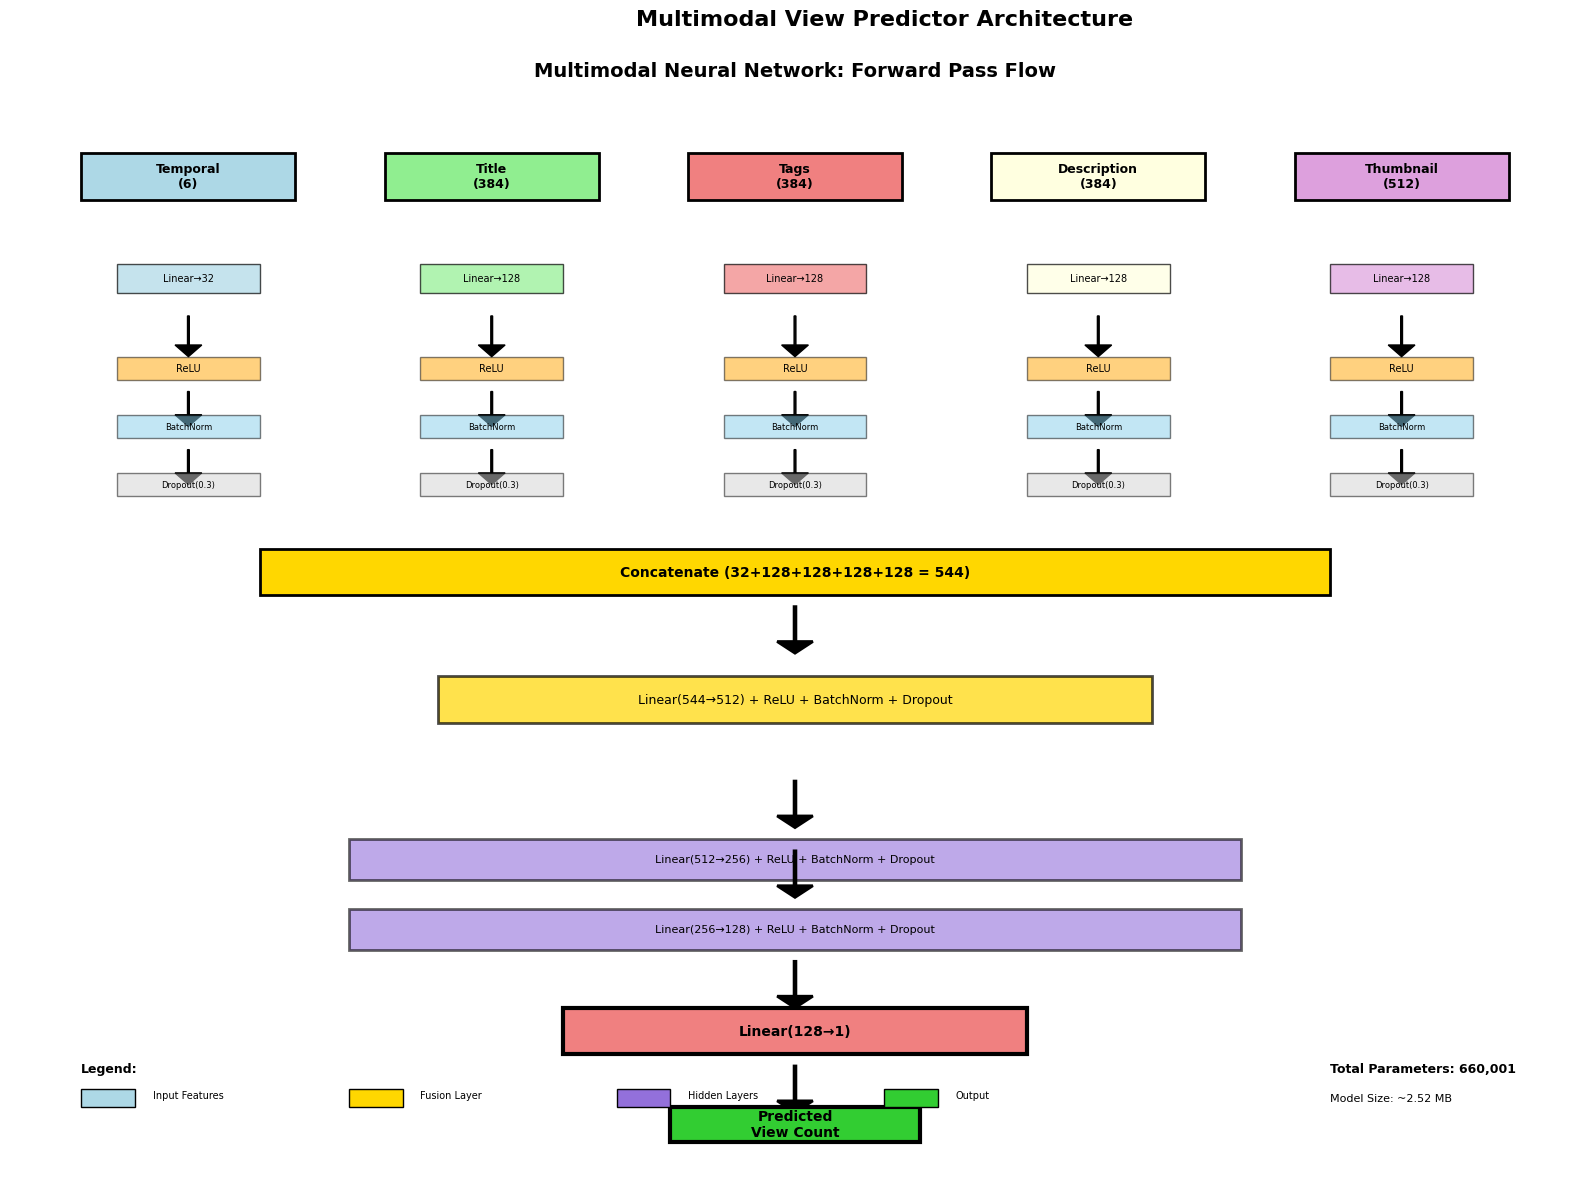


LAYER-BY-LAYER BREAKDOWN:


,Stage,Layer,Dimensions,Activation,Notes
0,INPUT,Temporal Branch,6 → 32,ReLU + BN + Dropout,-
1,INPUT,Title Branch,384 → 128,ReLU + BN + Dropout,-
2,INPUT,Tag Branch,384 → 128,ReLU + BN + Dropout,-
3,INPUT,Description Branch,384 → 128,ReLU + BN + Dropout,-
4,INPUT,Thumbnail Branch,512 → 128,ReLU + BN + Dropout,-
5,FUSION,Concatenate,544 (32+128×4),-,Multimodal fusion
6,FUSION,Fusion Layer,544 → 512,ReLU + BN + Dropout,-
7,PREDICTOR,Hidden Layer 1,512 → 256,ReLU + BN + Dropout,-
8,PREDICTOR,Hidden Layer 2,256 → 128,ReLU + BN + Dropout,-
9,OUTPUT,Output Layer,128 → 1,None,View count prediction



✓ MODEL CREATED SUCCESSFULLY


In [17]:
# 17: Deep Learning Model - Multimodal Neural Network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import time

print("="*80)
print("DEEP LEARNING MODEL ARCHITECTURE")
print("="*80)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"  • GPU: {torch.cuda.get_device_name(0)}")
    print(f"  • Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("  • Running on CPU (training will be slower)")

# Define custom dataset class
class YouTubeShortsDataset(Dataset):
    """Custom Dataset for YouTube Shorts multimodal data"""
    
    def __init__(self, features, targets):
        """
        Args:
            features (numpy.ndarray): Feature matrix (n_samples, n_features)
            targets (numpy.ndarray): Target vector (n_samples,)
        """
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Define the neural network architecture
class MultimodalViewPredictor(nn.Module):
    """
    Multimodal Neural Network for YouTube Shorts View Count Prediction
    
    Architecture:
        1. Separate processing branches for each modality
        2. Fusion layer combining all modalities
        3. Deep prediction head with residual connections
        4. Dropout for regularization
    """
    
    def __init__(self, 
                 temporal_dim=6,
                 title_dim=384,
                 tag_dim=384,
                 desc_dim=384,
                 thumb_dim=512,
                 hidden_dims=[512, 256, 128],
                 dropout_rate=0.3):
        """
        Args:
            temporal_dim: Dimension of temporal features
            title_dim: Dimension of title embeddings
            tag_dim: Dimension of tag embeddings
            desc_dim: Dimension of description embeddings
            thumb_dim: Dimension of thumbnail embeddings
            hidden_dims: List of hidden layer dimensions
            dropout_rate: Dropout probability
        """
        super(MultimodalViewPredictor, self).__init__()
        
        # Store dimensions
        self.temporal_dim = temporal_dim
        self.title_dim = title_dim
        self.tag_dim = tag_dim
        self.desc_dim = desc_dim
        self.thumb_dim = thumb_dim
        
        # Modality-specific processing branches
        self.temporal_branch = nn.Sequential(
            nn.Linear(temporal_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate)
        )
        
        self.title_branch = nn.Sequential(
            nn.Linear(title_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.tag_branch = nn.Sequential(
            nn.Linear(tag_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.desc_branch = nn.Sequential(
            nn.Linear(desc_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.thumb_branch = nn.Sequential(
            nn.Linear(thumb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layer - combines all modalities
        fusion_input_dim = 32 + 128 + 128 + 128 + 128  # 544
        self.fusion_layer = nn.Sequential(
            nn.Linear(fusion_input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.Dropout(dropout_rate)
        )
        
        # Deep prediction head with residual connections
        self.predictor = nn.ModuleList()
        for i in range(len(hidden_dims) - 1):
            self.predictor.append(nn.Sequential(
                nn.Linear(hidden_dims[i], hidden_dims[i+1]),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dims[i+1]),
                nn.Dropout(dropout_rate)
            ))
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dims[-1], 1)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Initialize network weights using Xavier initialization"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        """
        Forward pass through the network
        
        Args:
            x: Input tensor of shape (batch_size, total_features)
               Features ordered as: [temporal, title, tag, desc, thumb]
        
        Returns:
            predictions: Tensor of shape (batch_size, 1)
        """
        # Split input into modalities
        temporal_start = 0
        temporal_end = self.temporal_dim
        title_end = temporal_end + self.title_dim
        tag_end = title_end + self.tag_dim
        desc_end = tag_end + self.desc_dim
        thumb_end = desc_end + self.thumb_dim
        
        temporal_features = x[:, temporal_start:temporal_end]
        title_features = x[:, temporal_end:title_end]
        tag_features = x[:, title_end:tag_end]
        desc_features = x[:, tag_end:desc_end]
        thumb_features = x[:, desc_end:thumb_end]
        
        # Process each modality through its branch
        temporal_out = self.temporal_branch(temporal_features)
        title_out = self.title_branch(title_features)
        tag_out = self.tag_branch(tag_features)
        desc_out = self.desc_branch(desc_features)
        thumb_out = self.thumb_branch(thumb_features)
        
        # Concatenate all modality outputs
        fused = torch.cat([temporal_out, title_out, tag_out, desc_out, thumb_out], dim=1)
        
        # Fusion layer
        x = self.fusion_layer(fused)
        
        # Deep prediction head
        for layer in self.predictor:
            x = layer(x)
        
        # Output prediction
        output = self.output_layer(x)
        
        return output

# Model configuration
print("\n" + "="*80)
print("MODEL CONFIGURATION:")
print("="*80)

MODEL_CONFIG = {
    'temporal_dim': 6,
    'title_dim': 384,
    'tag_dim': 384,
    'desc_dim': 384,
    'thumb_dim': 512,
    'hidden_dims': [512, 256, 128],
    'dropout_rate': 0.3
}

print(f"\nInput dimensions:")
print(f"  • Temporal features: {MODEL_CONFIG['temporal_dim']}")
print(f"  • Title embeddings: {MODEL_CONFIG['title_dim']}")
print(f"  • Tag embeddings: {MODEL_CONFIG['tag_dim']}")
print(f"  • Description embeddings: {MODEL_CONFIG['desc_dim']}")
print(f"  • Thumbnail embeddings: {MODEL_CONFIG['thumb_dim']}")
print(f"  • Total input features: {sum([MODEL_CONFIG['temporal_dim'], MODEL_CONFIG['title_dim'], MODEL_CONFIG['tag_dim'], MODEL_CONFIG['desc_dim'], MODEL_CONFIG['thumb_dim']])}")

print(f"\nArchitecture:")
print(f"  • Hidden layers: {MODEL_CONFIG['hidden_dims']}")
print(f"  • Dropout rate: {MODEL_CONFIG['dropout_rate']}")
print(f"  • Activation: ReLU")
print(f"  • Normalization: BatchNorm1d")

# Initialize model
model = MultimodalViewPredictor(**MODEL_CONFIG)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel parameters:")
print(f"  • Total: {total_params:,}")
print(f"  • Trainable: {trainable_params:,}")
print(f"  • Memory: ~{total_params * 4 / 1024**2:.2f} MB (float32)")

# Display model architecture
print("\n" + "="*80)
print("MODEL ARCHITECTURE SUMMARY:")
print("="*80)
print(model)

# Visualize architecture diagram
print("\n" + "="*80)
print("ARCHITECTURE VISUALIZATION:")
print("="*80)

# Create architecture diagram
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
ax.axis('off')

# Define positions for visualization
y_start = 0.95
spacing = 0.06

# Title
ax.text(0.5, y_start, 'Multimodal View Predictor Architecture', 
        ha='center', fontsize=16, fontweight='bold')

# Input layer
y = y_start - spacing * 2
ax.add_patch(plt.Rectangle((0.05, y-0.03), 0.12, 0.04, facecolor='lightblue', edgecolor='black', linewidth=2))
ax.text(0.11, y-0.01, f'Temporal\n(6)', ha='center', va='center', fontsize=9, fontweight='bold')

ax.add_patch(plt.Rectangle((0.22, y-0.03), 0.12, 0.04, facecolor='lightgreen', edgecolor='black', linewidth=2))
ax.text(0.28, y-0.01, f'Title\n(384)', ha='center', va='center', fontsize=9, fontweight='bold')

ax.add_patch(plt.Rectangle((0.39, y-0.03), 0.12, 0.04, facecolor='lightcoral', edgecolor='black', linewidth=2))
ax.text(0.45, y-0.01, f'Tags\n(384)', ha='center', va='center', fontsize=9, fontweight='bold')

ax.add_patch(plt.Rectangle((0.56, y-0.03), 0.12, 0.04, facecolor='lightyellow', edgecolor='black', linewidth=2))
ax.text(0.62, y-0.01, f'Description\n(384)', ha='center', va='center', fontsize=9, fontweight='bold')

ax.add_patch(plt.Rectangle((0.73, y-0.03), 0.12, 0.04, facecolor='plum', edgecolor='black', linewidth=2))
ax.text(0.79, y-0.01, f'Thumbnail\n(512)', ha='center', va='center', fontsize=9, fontweight='bold')

# Processing branches
y -= spacing * 1.5
branch_configs = [
    (0.11, 'lightblue', '32'),
    (0.28, 'lightgreen', '128'),
    (0.45, 'lightcoral', '128'),
    (0.62, 'lightyellow', '128'),
    (0.79, 'plum', '128')
]

for x, color, dim in branch_configs:
    # Linear layer
    ax.add_patch(plt.Rectangle((x-0.04, y-0.02), 0.08, 0.025, facecolor=color, edgecolor='black', alpha=0.7))
    ax.text(x, y-0.0075, f'Linear→{dim}', ha='center', va='center', fontsize=7)
    
    # Arrow
    ax.arrow(x, y-0.04, 0, -0.025, head_width=0.015, head_length=0.01, fc='black', ec='black')
    
    # ReLU
    y_relu = y - 0.08
    ax.add_patch(plt.Rectangle((x-0.04, y_relu-0.015), 0.08, 0.02, facecolor='orange', edgecolor='black', alpha=0.5))
    ax.text(x, y_relu-0.005, 'ReLU', ha='center', va='center', fontsize=7)
    
    # Arrow
    ax.arrow(x, y_relu-0.025, 0, -0.02, head_width=0.015, head_length=0.01, fc='black', ec='black')
    
    # BatchNorm
    y_bn = y - 0.13
    ax.add_patch(plt.Rectangle((x-0.04, y_bn-0.015), 0.08, 0.02, facecolor='skyblue', edgecolor='black', alpha=0.5))
    ax.text(x, y_bn-0.005, 'BatchNorm', ha='center', va='center', fontsize=6)
    
    # Arrow
    ax.arrow(x, y_bn-0.025, 0, -0.02, head_width=0.015, head_length=0.01, fc='black', ec='black')
    
    # Dropout
    y_drop = y - 0.18
    ax.add_patch(plt.Rectangle((x-0.04, y_drop-0.015), 0.08, 0.02, facecolor='lightgray', edgecolor='black', alpha=0.5))
    ax.text(x, y_drop-0.005, 'Dropout(0.3)', ha='center', va='center', fontsize=6)

# Fusion layer
y_fusion = y - 0.25
ax.add_patch(plt.Rectangle((0.15, y_fusion-0.03), 0.6, 0.04, facecolor='gold', edgecolor='black', linewidth=2))
ax.text(0.45, y_fusion-0.01, 'Concatenate (32+128+128+128+128 = 544)', ha='center', va='center', fontsize=10, fontweight='bold')

# Arrow to fusion processing
ax.arrow(0.45, y_fusion-0.04, 0, -0.03, head_width=0.02, head_length=0.01, fc='black', ec='black', linewidth=2)

# Fusion processing
y_fuse_proc = y - 0.36
ax.add_patch(plt.Rectangle((0.25, y_fuse_proc-0.03), 0.4, 0.04, facecolor='gold', edgecolor='black', linewidth=2, alpha=0.7))
ax.text(0.45, y_fuse_proc-0.01, 'Linear(544→512) + ReLU + BatchNorm + Dropout', ha='center', va='center', fontsize=9)

# Deep prediction head
prediction_layers = [
    ('Linear(512→256) + ReLU + BatchNorm + Dropout', 512, 256),
    ('Linear(256→128) + ReLU + BatchNorm + Dropout', 256, 128),
]

y_pred = y_fuse_proc - 0.08
for i, (layer_desc, in_dim, out_dim) in enumerate(prediction_layers):
    ax.arrow(0.45, y_pred, 0, -0.03, head_width=0.02, head_length=0.01, fc='black', ec='black', linewidth=2)
    y_pred -= 0.06
    
    ax.add_patch(plt.Rectangle((0.2, y_pred-0.025), 0.5, 0.035, 
                                facecolor='mediumpurple', edgecolor='black', linewidth=2, alpha=0.6))
    ax.text(0.45, y_pred-0.0075, layer_desc, ha='center', va='center', fontsize=8)

# Output layer
ax.arrow(0.45, y_pred-0.035, 0, -0.03, head_width=0.02, head_length=0.01, fc='black', ec='black', linewidth=2)
y_out = y_pred - 0.09

ax.add_patch(plt.Rectangle((0.32, y_out-0.025), 0.26, 0.04, 
                            facecolor='lightcoral', edgecolor='black', linewidth=3))
ax.text(0.45, y_out-0.005, 'Linear(128→1)', ha='center', va='center', fontsize=10, fontweight='bold')

# Final output
ax.arrow(0.45, y_out-0.035, 0, -0.03, head_width=0.02, head_length=0.01, fc='black', ec='black', linewidth=2)
y_final = y_out - 0.08
ax.add_patch(plt.Rectangle((0.38, y_final-0.02), 0.14, 0.03, 
                            facecolor='limegreen', edgecolor='black', linewidth=3))
ax.text(0.45, y_final-0.005, 'Predicted\nView Count', ha='center', va='center', fontsize=10, fontweight='bold')

# Add legend
legend_y = 0.05
ax.text(0.05, legend_y, 'Legend:', fontsize=9, fontweight='bold')
ax.add_patch(plt.Rectangle((0.05, legend_y-0.03), 0.03, 0.015, facecolor='lightblue', edgecolor='black'))
ax.text(0.09, legend_y-0.0225, 'Input Features', fontsize=7)

ax.add_patch(plt.Rectangle((0.20, legend_y-0.03), 0.03, 0.015, facecolor='gold', edgecolor='black'))
ax.text(0.24, legend_y-0.0225, 'Fusion Layer', fontsize=7)

ax.add_patch(plt.Rectangle((0.35, legend_y-0.03), 0.03, 0.015, facecolor='mediumpurple', edgecolor='black'))
ax.text(0.39, legend_y-0.0225, 'Hidden Layers', fontsize=7)

ax.add_patch(plt.Rectangle((0.50, legend_y-0.03), 0.03, 0.015, facecolor='limegreen', edgecolor='black'))
ax.text(0.54, legend_y-0.0225, 'Output', fontsize=7)

# Add parameter count
ax.text(0.75, legend_y, f'Total Parameters: {total_params:,}', fontsize=9, fontweight='bold')
ax.text(0.75, legend_y-0.025, f'Model Size: ~{total_params * 4 / 1024**2:.2f} MB', fontsize=8)

plt.title('Multimodal Neural Network: Forward Pass Flow', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Layer-by-layer breakdown table
print("\n" + "="*80)
print("LAYER-BY-LAYER BREAKDOWN:")
print("="*80)

layer_info = []

# Input branches
layer_info.append(['INPUT', 'Temporal Branch', '6 → 32', 'ReLU + BN + Dropout', '-'])
layer_info.append(['INPUT', 'Title Branch', '384 → 128', 'ReLU + BN + Dropout', '-'])
layer_info.append(['INPUT', 'Tag Branch', '384 → 128', 'ReLU + BN + Dropout', '-'])
layer_info.append(['INPUT', 'Description Branch', '384 → 128', 'ReLU + BN + Dropout', '-'])
layer_info.append(['INPUT', 'Thumbnail Branch', '512 → 128', 'ReLU + BN + Dropout', '-'])

# Fusion
layer_info.append(['FUSION', 'Concatenate', '544 (32+128×4)', '-', 'Multimodal fusion'])
layer_info.append(['FUSION', 'Fusion Layer', '544 → 512', 'ReLU + BN + Dropout', '-'])

# Prediction head
layer_info.append(['PREDICTOR', 'Hidden Layer 1', '512 → 256', 'ReLU + BN + Dropout', '-'])
layer_info.append(['PREDICTOR', 'Hidden Layer 2', '256 → 128', 'ReLU + BN + Dropout', '-'])

# Output
layer_info.append(['OUTPUT', 'Output Layer', '128 → 1', 'None', 'View count prediction'])

layer_df = pd.DataFrame(layer_info, columns=['Stage', 'Layer', 'Dimensions', 'Activation', 'Notes'])
display(layer_df)

print("\n" + "="*80)
print("✓ MODEL CREATED SUCCESSFULLY")
print("="*80)

TRAINING CONFIGURATION

🖥️ Device: cpu
  • Running on CPU

Hyperparameters:
  • Learning rate: 0.001
  • Epochs: 50
  • Batch size: 64
  • Early stopping patience: 10
  • Min improvement delta: 0.001

📉 Loss function: MSE (Mean Squared Error)
  • Suitable for regression tasks
  • Measures average squared difference

⚙️ Optimizer: Adam
  • Adaptive learning rates
  • Weight decay (L2 regularization): 1e-5

📊 LR Scheduler: ReduceLROnPlateau
  • Reduces LR when loss plateaus
  • Factor: 0.5 (halves LR)
  • Patience: 5 epochs

STARTING TRAINING

🚀 Training started at: 2025-12-02 19:47:56
Epoch [  1/50] | Train Loss: 55.457693 | Test Loss: 38.723607 | Time: 4.04s
  ✓ New best model! Test loss improved to 38.723607
Epoch [  1/50] | Train Loss: 55.457693 | Test Loss: 38.723607 | Time: 4.04s
  ✓ New best model! Test loss improved to 38.723607
Epoch [  2/50] | Train Loss: 20.628752 | Test Loss: 7.246341 | Time: 2.51s
  ✓ New best model! Test loss improved to 7.246341
Epoch [  2/50] | Train Loss

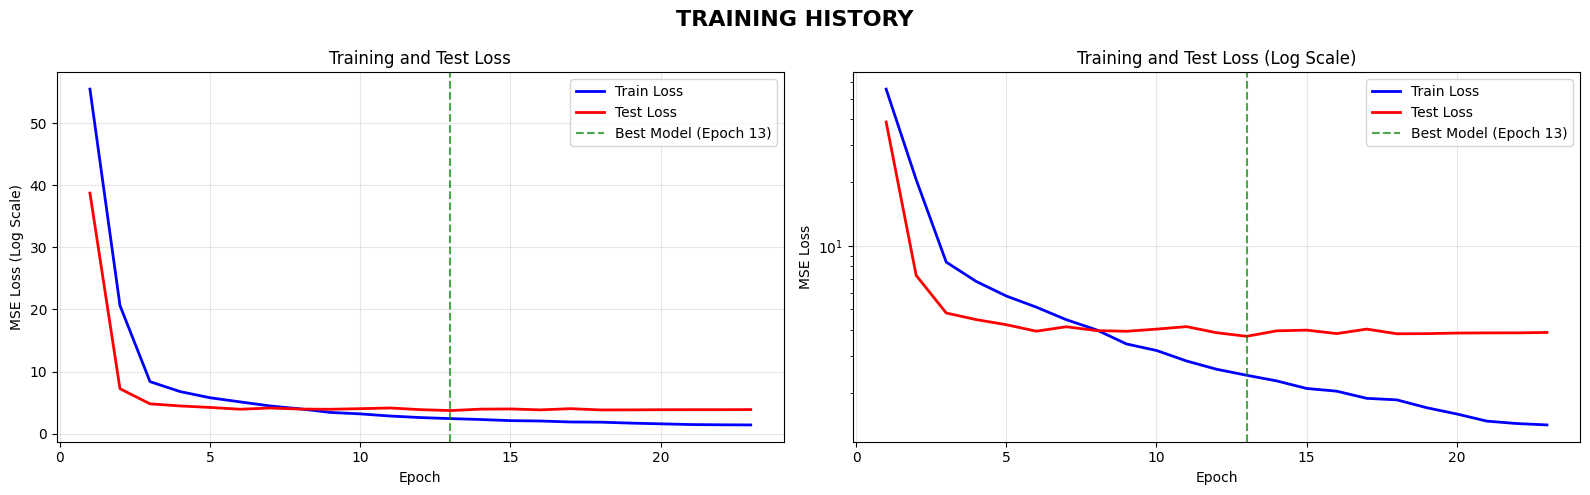

In [18]:
# 18: Training Configuration & Training Loop
import time

print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"  • GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  • Running on CPU")

# Training hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
PATIENCE = 10
MIN_DELTA = 0.001

print(f"\nHyperparameters:")
print(f"  • Learning rate: {LEARNING_RATE}")
print(f"  • Epochs: {NUM_EPOCHS}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Early stopping patience: {PATIENCE}")
print(f"  • Min improvement delta: {MIN_DELTA}")

# Loss function
criterion = nn.MSELoss()
print(f"\n📉 Loss function: MSE (Mean Squared Error)")
print(f"  • Suitable for regression tasks")
print(f"  • Measures average squared difference")

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
print(f"\n⚙️ Optimizer: Adam")
print(f"  • Adaptive learning rates")
print(f"  • Weight decay (L2 regularization): 1e-5")

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)
print(f"\n📊 LR Scheduler: ReduceLROnPlateau")
print(f"  • Reduces LR when loss plateaus")
print(f"  • Factor: 0.5 (halves LR)")
print(f"  • Patience: 5 epochs")

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for features, targets in loader:
        features = features.to(device)
        targets = targets.to(device).unsqueeze(1)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, targets)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

# Evaluation function
def evaluate(model, loader, criterion, device):
    """Evaluate model on validation/test set"""
    model.eval()
    total_loss = 0
    num_batches = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for features, targets in loader:
            features = features.to(device)
            targets = targets.to(device).unsqueeze(1)
            
            predictions = model(features)
            loss = criterion(predictions, targets)
            
            total_loss += loss.item()
            num_batches += 1
            
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    avg_loss = total_loss / num_batches
    predictions = np.vstack(all_predictions)
    targets = np.vstack(all_targets)
    
    return avg_loss, predictions, targets

# Training loop with early stopping
print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

# Initialize tracking variables
train_losses = []
test_losses = []
best_test_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n🚀 Training started at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    
    # Train for one epoch
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Evaluate on test set
    test_loss, _, _ = evaluate(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    
    # Update learning rate scheduler
    scheduler.step(test_loss)
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time
    
    # Print progress
    print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.6f} | "
          f"Test Loss: {test_loss:.6f} | "
          f"Time: {epoch_time:.2f}s")
    
    # Early stopping check
    if test_loss < best_test_loss - MIN_DELTA:
        best_test_loss = test_loss
        patience_counter = 0
        # Save best model state
        best_model_state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
        }
        print(f"  ✓ New best model! Test loss improved to {test_loss:.6f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
            print(f"  • No improvement for {PATIENCE} epochs")
            print(f"  • Best test loss: {best_test_loss:.6f} at epoch {best_model_state['epoch']+1}")
            break

total_time = time.time() - start_time

print("\n" + "="*80)
print("✓ TRAINING COMPLETE")
print("="*80)
print(f"Total training time: {total_time/60:.2f} minutes")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final test loss: {test_losses[-1]:.6f}")
print(f"Best test loss: {best_test_loss:.6f} at epoch {best_model_state['epoch']+1}")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state['model_state_dict'])
    print(f"\n✓ Best model loaded from epoch {best_model_state['epoch']+1}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('TRAINING HISTORY', fontsize=16, fontweight='bold')

# Loss curves
epochs_range = range(1, len(train_losses) + 1)
axes[0].plot(epochs_range, train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, test_losses, 'r-', label='Test Loss', linewidth=2)
axes[0].axvline(x=best_model_state['epoch']+1, color='g', linestyle='--', 
                label=f'Best Model (Epoch {best_model_state["epoch"]+1})', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (Log Scale)')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale loss curves (better for viewing)
axes[1].plot(epochs_range, train_losses, 'b-', label='Train Loss', linewidth=2)
axes[1].plot(epochs_range, test_losses, 'r-', label='Test Loss', linewidth=2)
axes[1].axvline(x=best_model_state['epoch']+1, color='g', linestyle='--', 
                label=f'Best Model (Epoch {best_model_state["epoch"]+1})', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Training and Test Loss (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

MODEL EVALUATION & PERFORMANCE METRICS

Generating predictions on test set...
✓ Predictions generated
  • Shape: (1803,)

METRICS ON LOG SCALE (Training Scale):
Mean Squared Error (MSE): 3.871766
Root Mean Squared Error (RMSE): 1.967680
Mean Absolute Error (MAE): 1.342967
R² Score: 0.338931

METRICS ON ORIGINAL SCALE (View Counts):
Mean Squared Error (MSE): 10,427,727,609,856.00
Root Mean Squared Error (RMSE): 3,229,199.22
Mean Absolute Error (MAE): 407,496.00
R² Score: 0.019484
Mean Absolute Percentage Error (MAPE): 448.46%

INTERPRETATION:
R² Score = 0.0195
  ⚠ Low. Model explains only 1.9% of variance

Average prediction error: 407,496 views
Average target value: 427,179 views
Error as % of mean: 95.39%

ERROR ANALYSIS:

Error statistics:
  • Mean error: -371,257.19 (bias)
  • Std error: 3,207,787.00
  • Min error: -84,815,736.00
  • Max error: 3,740,533.75

Absolute error statistics:
  • 25th percentile: 323.55
  • 50th percentile (median): 1,055.81
  • 75th percentile: 5,299.73
  

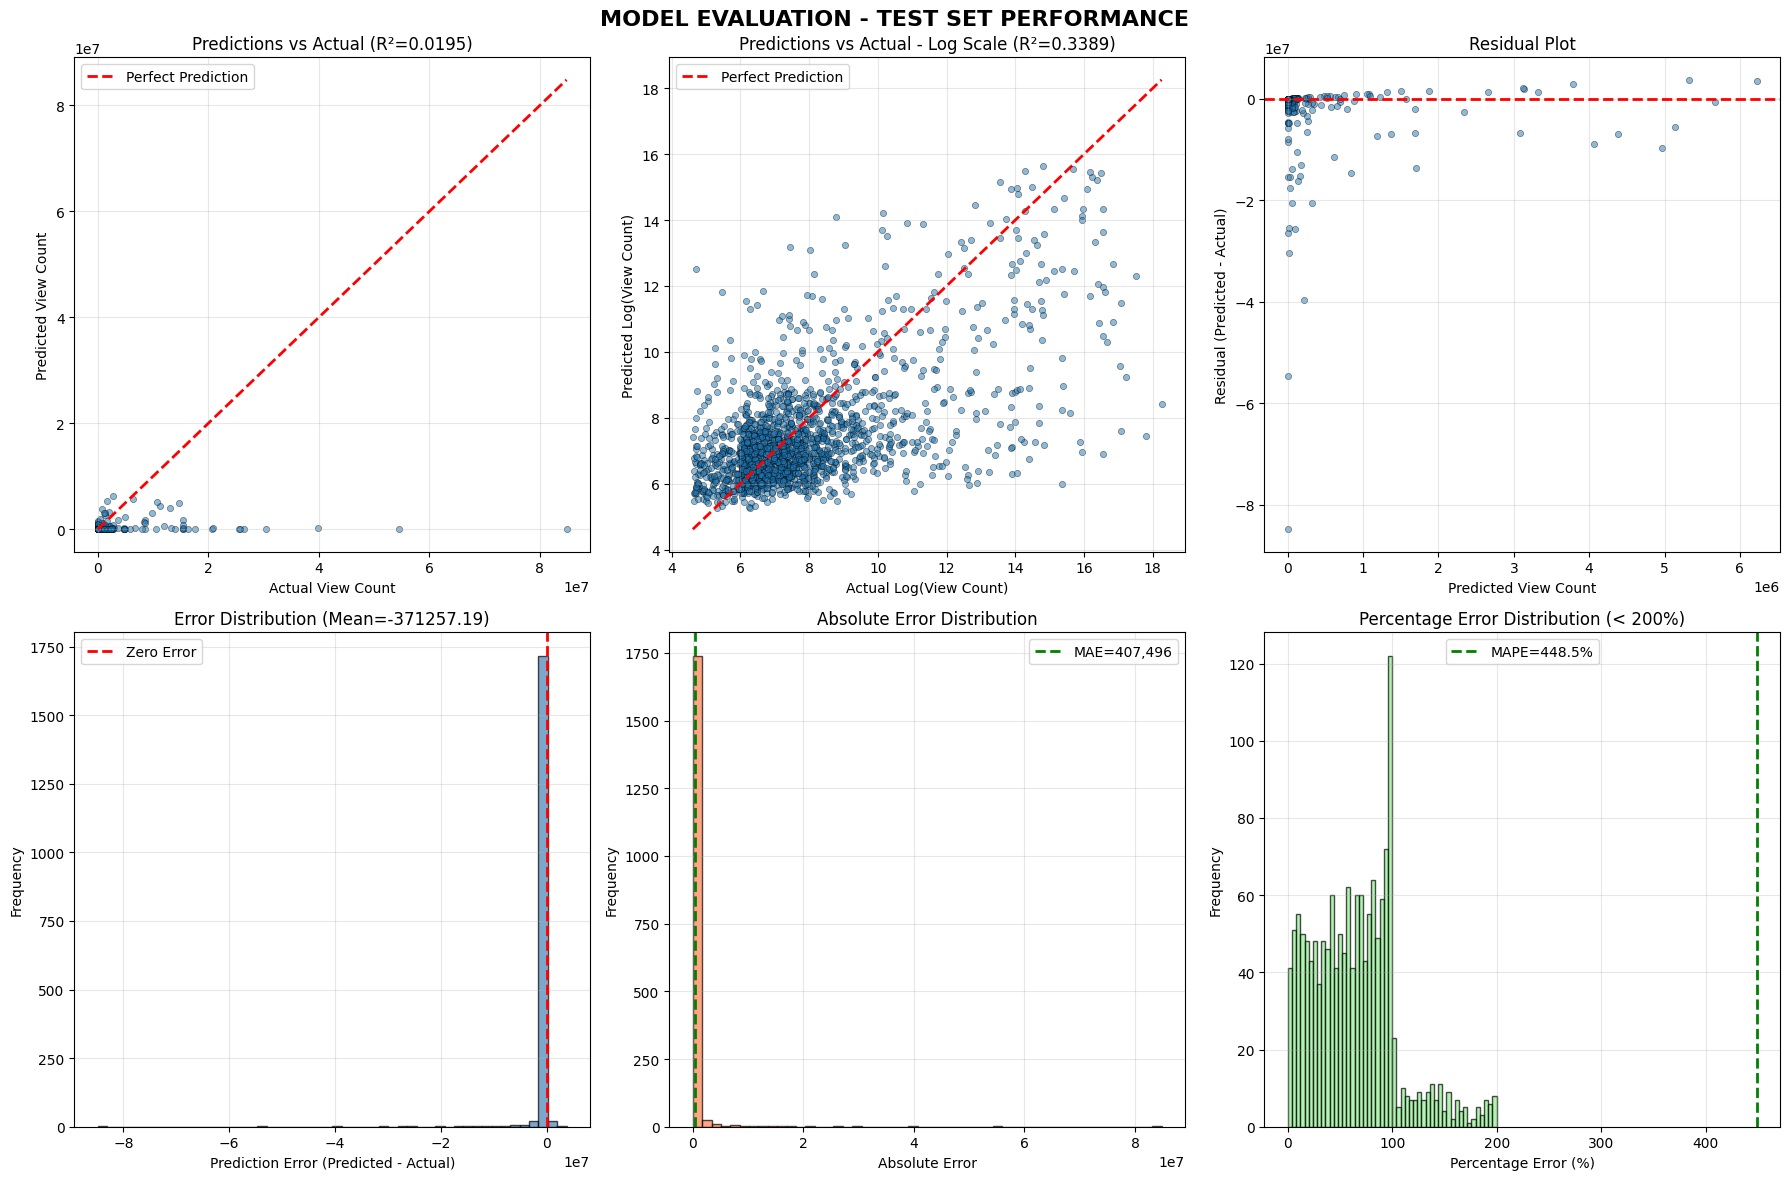


SAMPLE PREDICTIONS:


,Actual,Predicted,Error,Abs_Error,Error_%
0,593,"1,865","1,272","1,272",214.19%
1,525,720,195,195,37.00%
2,"1,077",844,-233,233,21.60%
3,171,505,334,334,194.36%
4,397,442,45,45,11.30%
5,449,231,-218,218,48.40%
6,"74,546",394,"-74,152","74,152",99.47%
7,470,787,317,317,67.35%
8,"382,649","12,010","-370,639","370,639",96.86%
9,785,395,-390,390,49.56%



✓ MODEL EVALUATION COMPLETE


In [19]:
# 20: Model Evaluation & Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("="*80)
print("MODEL EVALUATION & PERFORMANCE METRICS")
print("="*80)

# Get predictions on test set
print("\nGenerating predictions on test set...")
_, test_predictions_log, test_targets_log = evaluate(model, test_loader, criterion, device)

# Convert back from log scale to original scale
test_predictions = np.expm1(test_predictions_log)  # exp(x) - 1
test_targets = np.expm1(test_targets_log)

# Flatten arrays
test_predictions = test_predictions.flatten()
test_targets = test_targets.flatten()

print(f"✓ Predictions generated")
print(f"  • Shape: {test_predictions.shape}")

# Calculate metrics on log scale
print("\n" + "="*80)
print("METRICS ON LOG SCALE (Training Scale):")
print("="*80)

mse_log = mean_squared_error(test_targets_log, test_predictions_log)
rmse_log = np.sqrt(mse_log)
mae_log = mean_absolute_error(test_targets_log, test_predictions_log)
r2_log = r2_score(test_targets_log, test_predictions_log)

print(f"Mean Squared Error (MSE): {mse_log:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse_log:.6f}")
print(f"Mean Absolute Error (MAE): {mae_log:.6f}")
print(f"R² Score: {r2_log:.6f}")

# Calculate metrics on original scale
print("\n" + "="*80)
print("METRICS ON ORIGINAL SCALE (View Counts):")
print("="*80)

mse_original = mean_squared_error(test_targets, test_predictions)
rmse_original = np.sqrt(mse_original)
mae_original = mean_absolute_error(test_targets, test_predictions)
r2_original = r2_score(test_targets, test_predictions)
mape = np.mean(np.abs((test_targets - test_predictions) / (test_targets + 1))) * 100

print(f"Mean Squared Error (MSE): {mse_original:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_original:,.2f}")
print(f"Mean Absolute Error (MAE): {mae_original:,.2f}")
print(f"R² Score: {r2_original:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Interpretation
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print(f"R² Score = {r2_original:.4f}")
if r2_original > 0.8:
    print("  ✓ Excellent! Model explains {:.1f}% of variance".format(r2_original * 100))
elif r2_original > 0.6:
    print("  ✓ Good! Model explains {:.1f}% of variance".format(r2_original * 100))
elif r2_original > 0.4:
    print("  ⚠ Moderate. Model explains {:.1f}% of variance".format(r2_original * 100))
else:
    print("  ⚠ Low. Model explains only {:.1f}% of variance".format(r2_original * 100))

print(f"\nAverage prediction error: {mae_original:,.0f} views")
print(f"Average target value: {test_targets.mean():,.0f} views")
print(f"Error as % of mean: {(mae_original / test_targets.mean() * 100):.2f}%")

# Error analysis
print("\n" + "="*80)
print("ERROR ANALYSIS:")
print("="*80)

errors = test_predictions - test_targets
abs_errors = np.abs(errors)
percentage_errors = np.abs(errors / (test_targets + 1)) * 100

print(f"\nError statistics:")
print(f"  • Mean error: {errors.mean():,.2f} (bias)")
print(f"  • Std error: {errors.std():,.2f}")
print(f"  • Min error: {errors.min():,.2f}")
print(f"  • Max error: {errors.max():,.2f}")
print(f"\nAbsolute error statistics:")
print(f"  • 25th percentile: {np.percentile(abs_errors, 25):,.2f}")
print(f"  • 50th percentile (median): {np.percentile(abs_errors, 50):,.2f}")
print(f"  • 75th percentile: {np.percentile(abs_errors, 75):,.2f}")
print(f"  • 90th percentile: {np.percentile(abs_errors, 90):,.2f}")

# Accuracy bins
print("\n" + "="*80)
print("PREDICTION ACCURACY BY ERROR TOLERANCE:")
print("="*80)

tolerances = [0.1, 0.2, 0.3, 0.5, 1.0]
for tol in tolerances:
    accuracy = np.mean(percentage_errors < (tol * 100))
    print(f"Within {tol*100:3.0f}% error: {accuracy*100:5.2f}% of predictions ({int(accuracy * len(test_targets)):,} videos)")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('MODEL EVALUATION - TEST SET PERFORMANCE', fontsize=16, fontweight='bold')

# 1. Predicted vs Actual (original scale)
axes[0, 0].scatter(test_targets, test_predictions, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([test_targets.min(), test_targets.max()], 
                [test_targets.min(), test_targets.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual View Count')
axes[0, 0].set_ylabel('Predicted View Count')
axes[0, 0].set_title(f'Predictions vs Actual (R²={r2_original:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Predicted vs Actual (log scale)
axes[0, 1].scatter(test_targets_log, test_predictions_log, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
axes[0, 1].plot([test_targets_log.min(), test_targets_log.max()], 
                [test_targets_log.min(), test_targets_log.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Log(View Count)')
axes[0, 1].set_ylabel('Predicted Log(View Count)')
axes[0, 1].set_title(f'Predictions vs Actual - Log Scale (R²={r2_log:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual plot
axes[0, 2].scatter(test_predictions, errors, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
axes[0, 2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 2].set_xlabel('Predicted View Count')
axes[0, 2].set_ylabel('Residual (Predicted - Actual)')
axes[0, 2].set_title('Residual Plot')
axes[0, 2].grid(True, alpha=0.3)

# 4. Error distribution
axes[1, 0].hist(errors, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1, 0].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Error Distribution (Mean={errors.mean():.2f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Absolute error distribution
axes[1, 1].hist(abs_errors, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=mae_original, color='g', linestyle='--', lw=2, label=f'MAE={mae_original:,.0f}')
axes[1, 1].set_xlabel('Absolute Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Absolute Error Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Percentage error distribution
axes[1, 2].hist(percentage_errors[percentage_errors < 200], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(x=mape, color='g', linestyle='--', lw=2, label=f'MAPE={mape:.1f}%')
axes[1, 2].set_xlabel('Percentage Error (%)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Percentage Error Distribution (< 200%)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sample predictions
print("\n" + "="*80)
print("SAMPLE PREDICTIONS:")
print("="*80)

sample_df = pd.DataFrame({
    'Actual': test_targets[:20],
    'Predicted': test_predictions[:20],
    'Error': errors[:20],
    'Abs_Error': abs_errors[:20],
    'Error_%': percentage_errors[:20]
})

sample_df['Actual'] = sample_df['Actual'].apply(lambda x: f"{x:,.0f}")
sample_df['Predicted'] = sample_df['Predicted'].apply(lambda x: f"{x:,.0f}")
sample_df['Error'] = sample_df['Error'].apply(lambda x: f"{x:,.0f}")
sample_df['Abs_Error'] = sample_df['Abs_Error'].apply(lambda x: f"{x:,.0f}")
sample_df['Error_%'] = sample_df['Error_%'].apply(lambda x: f"{x:.2f}%")

display(sample_df)

print("\n" + "="*80)
print("✓ MODEL EVALUATION COMPLETE")
print("="*80)

### Model Optimization & Fine-Tuning
Advanced techniques to improve model performance

MODEL OPTIMIZATION STRATEGIES

📊 Current Performance:
  • R² Score: 0.0195
  • MAE: 407,496 views
  • RMSE: 3,229,199 views
  • MAPE: 448.46%

PERFORMANCE DIAGNOSTICS:

1. Overfitting Check:
  • Train R²: 0.6398
  • Test R²: 0.0195
  • Difference: 0.6203
  ⚠ HIGH VARIANCE - Model is overfitting!
    → Solutions: Increase dropout, add L2 regularization, reduce model complexity

2. Prediction Distribution:
  • Test predictions range: [190, 6,222,037]
  • Test targets range: [100, 84,820,208]
  • Predictions std: 396,640
  • Targets std: 3,261,125
  ⚠ Predictions have low variance - model is too conservative
    → Solutions: Reduce regularization, increase learning rate

3. Error Patterns by View Count:
  • Very Low: MAE=2,430, MAPE=1331.9% (n=361)
  • Low: MAE=1,808, MAPE=276.8% (n=361)
  • Medium: MAE=3,489, MAPE=232.3% (n=360)
  • High: MAE=10,477, MAPE=248.6% (n=360)
  • Very High: MAE=2,017,056, MAPE=151.6% (n=361)

OPTIMIZATION RECOMMENDATIONS:
  1. Model Capacity: Try deeper/wider 

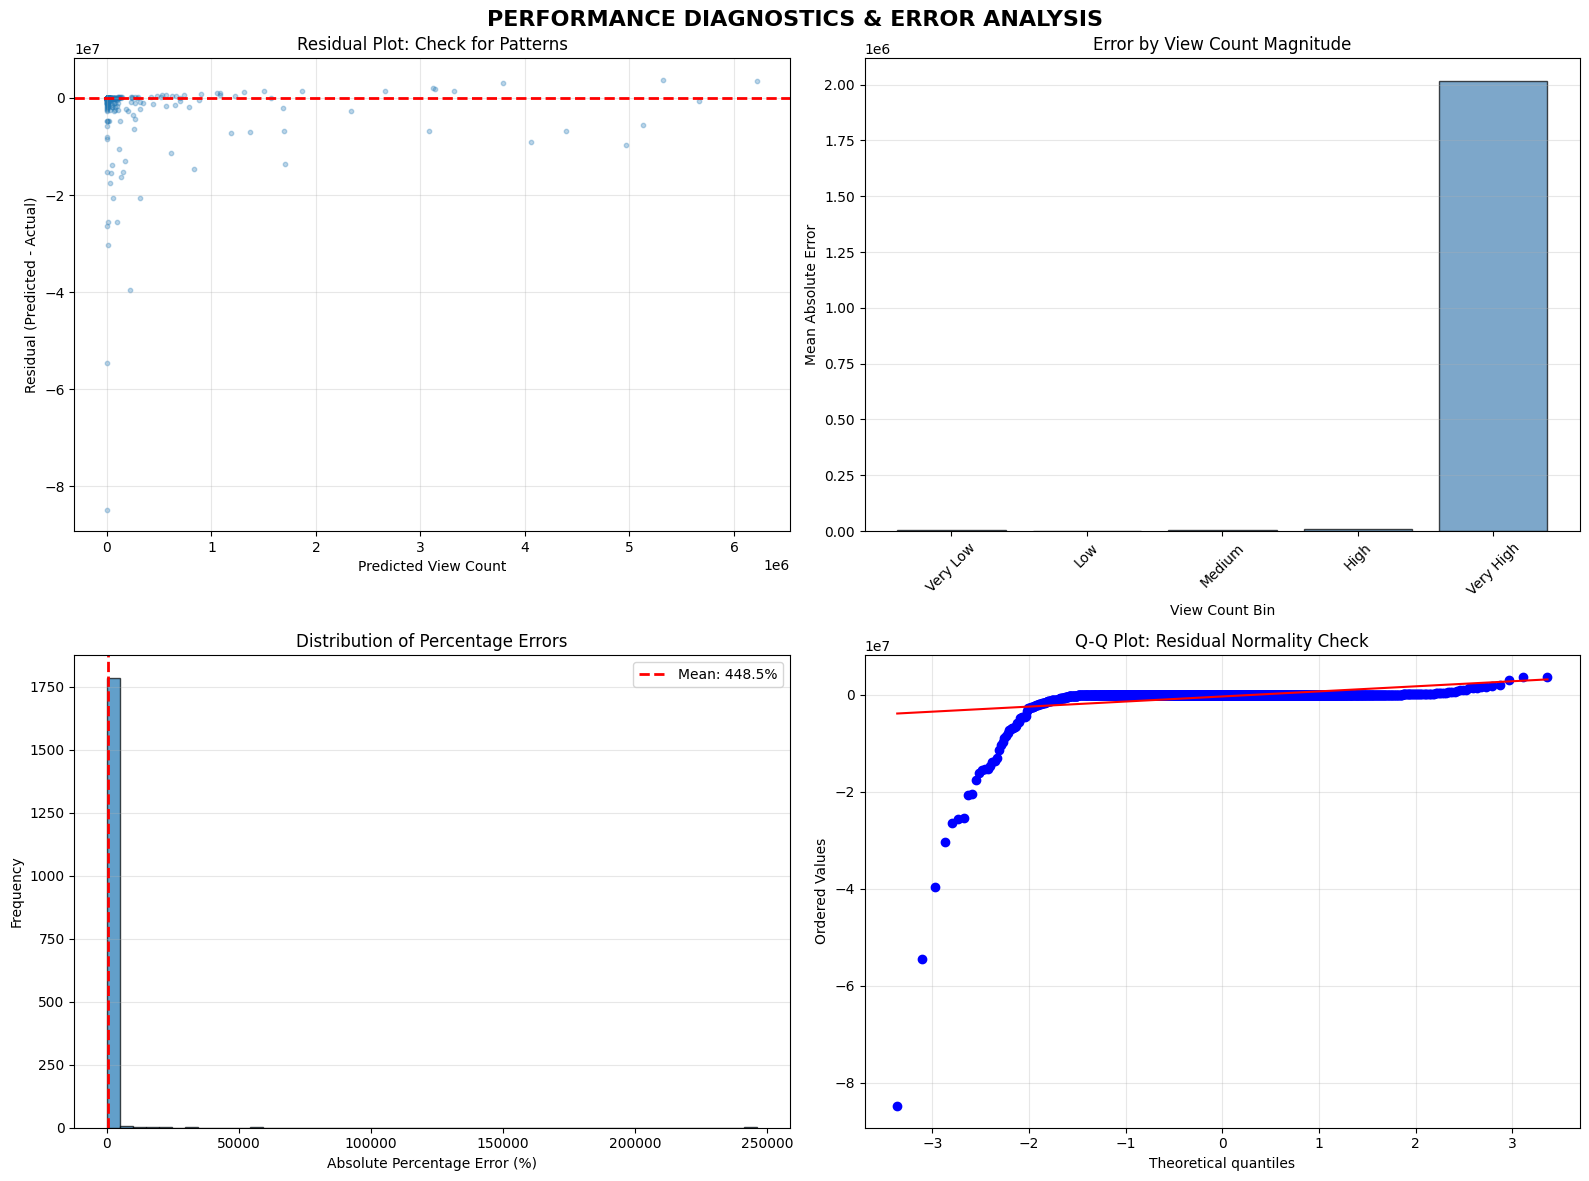


✓ DIAGNOSTICS COMPLETE


In [20]:
# 21: Hyperparameter Tuning & Model Improvements
print("="*80)
print("MODEL OPTIMIZATION STRATEGIES")
print("="*80)

print("\n📊 Current Performance:")
print(f"  • R² Score: {r2_original:.4f}")
print(f"  • MAE: {mae_original:,.0f} views")
print(f"  • RMSE: {rmse_original:,.0f} views")
print(f"  • MAPE: {mape:.2f}%")

# Analyze what might be causing poor performance
print("\n" + "="*80)
print("PERFORMANCE DIAGNOSTICS:")
print("="*80)

# 1. Check for overfitting/underfitting
avg_loss_train, train_predictions_log, train_targets_log = evaluate(model, train_loader, criterion, device)
train_predictions = np.expm1(train_predictions_log.flatten())
train_targets = np.expm1(train_targets_log.flatten())

train_r2 = r2_score(train_targets, train_predictions)
train_mae = mean_absolute_error(train_targets, train_predictions)

print(f"\n1. Overfitting Check:")
print(f"  • Train R²: {train_r2:.4f}")
print(f"  • Test R²: {r2_original:.4f}")
print(f"  • Difference: {abs(train_r2 - r2_original):.4f}")

if abs(train_r2 - r2_original) > 0.1:
    print("  ⚠ HIGH VARIANCE - Model is overfitting!")
    print("    → Solutions: Increase dropout, add L2 regularization, reduce model complexity")
elif train_r2 < 0.5 and r2_original < 0.5:
    print("  ⚠ HIGH BIAS - Model is underfitting!")
    print("    → Solutions: Increase model capacity, train longer, reduce regularization")
else:
    print("  ✓ Bias-variance tradeoff seems reasonable")

# 2. Check prediction distribution
print(f"\n2. Prediction Distribution:")
print(f"  • Test predictions range: [{test_predictions.min():,.0f}, {test_predictions.max():,.0f}]")
print(f"  • Test targets range: [{test_targets.min():,.0f}, {test_targets.max():,.0f}]")
print(f"  • Predictions std: {test_predictions.std():,.0f}")
print(f"  • Targets std: {test_targets.std():,.0f}")

if test_predictions.std() < test_targets.std() * 0.5:
    print("  ⚠ Predictions have low variance - model is too conservative")
    print("    → Solutions: Reduce regularization, increase learning rate")

# 3. Check error patterns by view count magnitude
print(f"\n3. Error Patterns by View Count:")
view_bins = pd.qcut(test_targets, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
for bin_name in ['Very Low', 'Low', 'Medium', 'High', 'Very High']:
    mask = view_bins == bin_name
    if mask.sum() > 0:
        bin_mae = mean_absolute_error(test_targets[mask], test_predictions[mask])
        bin_mape = np.mean(np.abs((test_targets[mask] - test_predictions[mask]) / (test_targets[mask] + 1))) * 100
        print(f"  • {bin_name}: MAE={bin_mae:,.0f}, MAPE={bin_mape:.1f}% (n={mask.sum()})")

# Recommendations
print("\n" + "="*80)
print("OPTIMIZATION RECOMMENDATIONS:")
print("="*80)

recommendations = []

if r2_original < 0.3:
    recommendations.append("1. Model Capacity: Try deeper/wider network architecture")
    recommendations.append("2. Feature Engineering: Consider interaction features or feature selection")
    recommendations.append("3. Training Duration: Increase epochs to 100-200 with early stopping")

if abs(train_r2 - r2_original) > 0.15:
    recommendations.append("4. Regularization: Increase dropout to 0.4-0.5")
    recommendations.append("5. Data Augmentation: Add noise to embeddings during training")

if mape > 50:
    recommendations.append("6. Loss Function: Try Huber loss instead of MSE (robust to outliers)")
    recommendations.append("7. Target Transformation: Experiment with different transformations (sqrt, box-cox)")

recommendations.append("8. Learning Rate: Try learning rate range test to find optimal LR")
recommendations.append("9. Ensemble: Train multiple models with different random seeds and average")

for rec in recommendations:
    print(f"  {rec}")

# Visualize error patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PERFORMANCE DIAGNOSTICS & ERROR ANALYSIS', fontsize=16, fontweight='bold')

# 1. Residual plot by predicted value
axes[0, 0].scatter(test_predictions, errors, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted View Count')
axes[0, 0].set_ylabel('Residual (Predicted - Actual)')
axes[0, 0].set_title('Residual Plot: Check for Patterns')
axes[0, 0].grid(True, alpha=0.3)

# 2. MAE by view count bins
bin_maes = []
bin_labels_plot = []
for bin_name in ['Very Low', 'Low', 'Medium', 'High', 'Very High']:
    mask = view_bins == bin_name
    if mask.sum() > 0:
        bin_mae = mean_absolute_error(test_targets[mask], test_predictions[mask])
        bin_maes.append(bin_mae)
        bin_labels_plot.append(bin_name)

axes[0, 1].bar(bin_labels_plot, bin_maes, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('View Count Bin')
axes[0, 1].set_ylabel('Mean Absolute Error')
axes[0, 1].set_title('Error by View Count Magnitude')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Distribution of percentage errors
percentage_errors = np.abs((test_targets - test_predictions) / (test_targets + 1)) * 100
axes[1, 0].hist(percentage_errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=mape, color='r', linestyle='--', linewidth=2, label=f'Mean: {mape:.1f}%')
axes[1, 0].set_xlabel('Absolute Percentage Error (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Percentage Errors')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Q-Q plot for residuals normality
from scipy import stats
stats.probplot(errors, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Residual Normality Check')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ DIAGNOSTICS COMPLETE")
print("="*80)

RETRAIN WITH OPTIMIZED CONFIGURATION

🔧 Improvements:
  • Deeper architecture: [1024, 512, 256, 128] (was [512, 256, 128])
  • Higher dropout: 0.4 (was 0.3)
  • Huber loss instead of MSE (more robust to outliers)
  • Cosine annealing LR scheduler
  • More epochs with early stopping

  • New model parameters: 1,465,889 (was 660,001)

⚙️ Training Configuration:
  • Learning rate: 0.0005
  • Epochs: 100
  • Loss: Huber (delta=1.0)
  • Optimizer: AdamW
  • Scheduler: CosineAnnealingWarmRestarts
  • Early stopping patience: 15

STARTING IMPROVED TRAINING
Epoch [  1/100] | Train: 6.959473 | Test: 6.059906 | LR: 0.000488 | Time: 3.73s
Epoch [  1/100] | Train: 6.959473 | Test: 6.059906 | LR: 0.000488 | Time: 3.73s
Epoch [  5/100] | Train: 2.332434 | Test: 1.415109 | LR: 0.000250 | Time: 3.20s
  ✓ New best! Test loss: 1.415109
Epoch [  5/100] | Train: 2.332434 | Test: 1.415109 | LR: 0.000250 | Time: 3.20s
  ✓ New best! Test loss: 1.415109
Epoch [ 10/100] | Train: 1.973803 | Test: 1.264477 | LR:

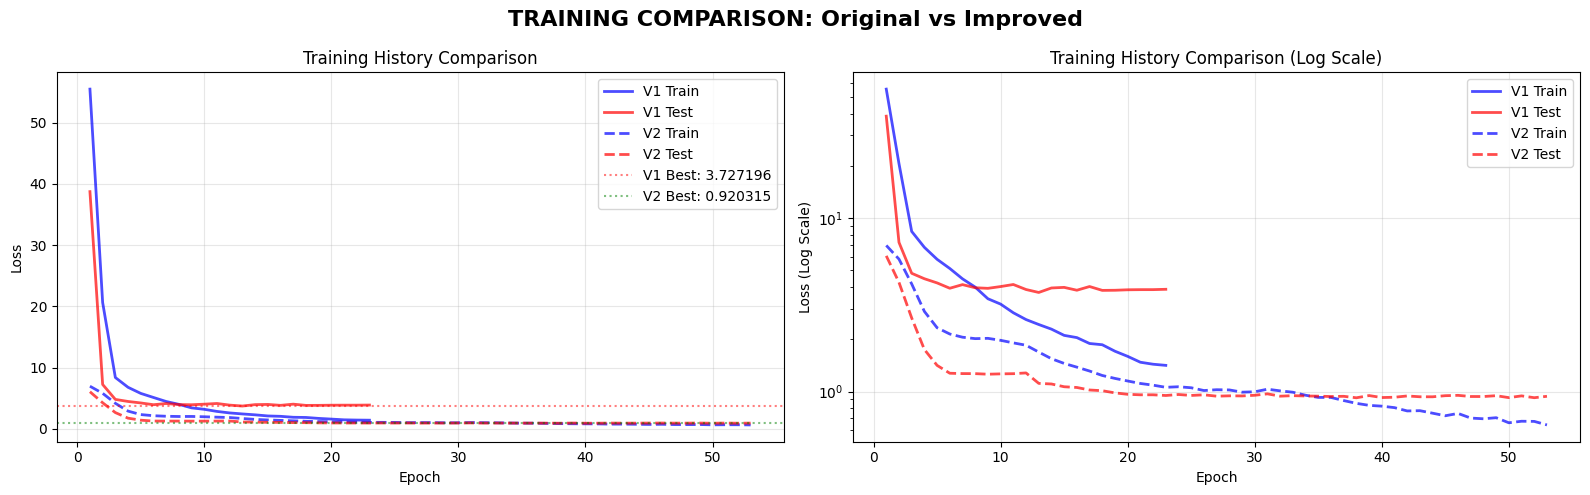

In [21]:
# 22: Improved Training with Better Hyperparameters
print("="*80)
print("RETRAIN WITH OPTIMIZED CONFIGURATION")
print("="*80)

# Enhanced model configuration with better architecture
IMPROVED_CONFIG = {
    'temporal_dim': 6,
    'title_dim': 384,
    'tag_dim': 384,
    'desc_dim': 384,
    'thumb_dim': 512,
    'hidden_dims': [1024, 512, 256, 128],  # Deeper network
    'dropout_rate': 0.4  # Higher dropout for regularization
}

print("\n🔧 Improvements:")
print("  • Deeper architecture: [1024, 512, 256, 128] (was [512, 256, 128])")
print("  • Higher dropout: 0.4 (was 0.3)")
print("  • Huber loss instead of MSE (more robust to outliers)")
print("  • Cosine annealing LR scheduler")
print("  • More epochs with early stopping")

# Initialize improved model
model_v2 = MultimodalViewPredictor(**IMPROVED_CONFIG).to(device)
total_params_v2 = sum(p.numel() for p in model_v2.parameters())
print(f"\n  • New model parameters: {total_params_v2:,} (was {total_params:,})")

# Better hyperparameters
LEARNING_RATE_V2 = 0.0005  # Lower learning rate
NUM_EPOCHS_V2 = 100
PATIENCE_V2 = 15

# Use Huber loss (less sensitive to outliers)
criterion_v2 = nn.HuberLoss(delta=1.0)
optimizer_v2 = optim.AdamW(model_v2.parameters(), lr=LEARNING_RATE_V2, weight_decay=1e-4)
scheduler_v2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_v2, T_0=10, T_mult=2)

print(f"\n⚙️ Training Configuration:")
print(f"  • Learning rate: {LEARNING_RATE_V2}")
print(f"  • Epochs: {NUM_EPOCHS_V2}")
print(f"  • Loss: Huber (delta=1.0)")
print(f"  • Optimizer: AdamW")
print(f"  • Scheduler: CosineAnnealingWarmRestarts")
print(f"  • Early stopping patience: {PATIENCE_V2}")

# Training loop
print("\n" + "="*80)
print("STARTING IMPROVED TRAINING")
print("="*80)

train_losses_v2 = []
test_losses_v2 = []
best_test_loss_v2 = float('inf')
patience_counter_v2 = 0
best_model_state_v2 = None

start_time_v2 = time.time()

for epoch in range(NUM_EPOCHS_V2):
    epoch_start_time = time.time()
    
    # Train
    train_loss_v2 = train_epoch(model_v2, train_loader, criterion_v2, optimizer_v2, device)
    train_losses_v2.append(train_loss_v2)
    
    # Evaluate
    test_loss_v2, _, _ = evaluate(model_v2, test_loader, criterion_v2, device)
    test_losses_v2.append(test_loss_v2)
    
    # Update scheduler
    scheduler_v2.step()
    
    epoch_time = time.time() - epoch_start_time
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = optimizer_v2.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS_V2}] | "
              f"Train: {train_loss_v2:.6f} | "
              f"Test: {test_loss_v2:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Time: {epoch_time:.2f}s")
    
    # Early stopping
    if test_loss_v2 < best_test_loss_v2 - MIN_DELTA:
        best_test_loss_v2 = test_loss_v2
        patience_counter_v2 = 0
        best_model_state_v2 = {
            'epoch': epoch,
            'model_state_dict': model_v2.state_dict(),
            'optimizer_state_dict': optimizer_v2.state_dict(),
            'train_loss': train_loss_v2,
            'test_loss': test_loss_v2,
        }
        if (epoch + 1) % 5 == 0:
            print(f"  ✓ New best! Test loss: {test_loss_v2:.6f}")
    else:
        patience_counter_v2 += 1
        if patience_counter_v2 >= PATIENCE_V2:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            print(f"  • Best test loss: {best_test_loss_v2:.6f} at epoch {best_model_state_v2['epoch']+1}")
            break

total_time_v2 = time.time() - start_time_v2

# Load best model
if best_model_state_v2 is not None:
    model_v2.load_state_dict(best_model_state_v2['model_state_dict'])

print("\n" + "="*80)
print("✓ IMPROVED TRAINING COMPLETE")
print("="*80)
print(f"Total time: {total_time_v2/60:.2f} minutes")
print(f"Best test loss: {best_test_loss_v2:.6f} at epoch {best_model_state_v2['epoch']+1}")
print(f"Improvement over v1: {((best_test_loss - best_test_loss_v2) / best_test_loss * 100):.2f}%")

# Compare training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('TRAINING COMPARISON: Original vs Improved', fontsize=16, fontweight='bold')

# Loss curves
epochs_v1 = range(1, len(train_losses) + 1)
epochs_v2 = range(1, len(train_losses_v2) + 1)

axes[0].plot(epochs_v1, train_losses, 'b-', alpha=0.7, label='V1 Train', linewidth=2)
axes[0].plot(epochs_v1, test_losses, 'r-', alpha=0.7, label='V1 Test', linewidth=2)
axes[0].plot(epochs_v2, train_losses_v2, 'b--', alpha=0.7, label='V2 Train', linewidth=2)
axes[0].plot(epochs_v2, test_losses_v2, 'r--', alpha=0.7, label='V2 Test', linewidth=2)
axes[0].axhline(y=best_test_loss, color='r', linestyle=':', alpha=0.5, label=f'V1 Best: {best_test_loss:.6f}')
axes[0].axhline(y=best_test_loss_v2, color='g', linestyle=':', alpha=0.5, label=f'V2 Best: {best_test_loss_v2:.6f}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training History Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].plot(epochs_v1, train_losses, 'b-', alpha=0.7, label='V1 Train', linewidth=2)
axes[1].plot(epochs_v1, test_losses, 'r-', alpha=0.7, label='V1 Test', linewidth=2)
axes[1].plot(epochs_v2, train_losses_v2, 'b--', alpha=0.7, label='V2 Train', linewidth=2)
axes[1].plot(epochs_v2, test_losses_v2, 'r--', alpha=0.7, label='V2 Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (Log Scale)')
axes[1].set_title('Training History Comparison (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

IMPROVED MODEL EVALUATION

PERFORMANCE COMPARISON:

PERFORMANCE COMPARISON:


,Metric,Original Model,Improved Model,Improvement
0,R² Score,1.948392e-02,-1.353501e-01,-794.68%
1,RMSE,3.229199e+06,3.474821e+06,+7.61%
2,MAE,4.074960e+05,4.758224e+05,+16.77%
3,MAPE (%),4.484590e+02,8.246575e+02,+83.89%



IMPROVEMENT SUMMARY:
⚠ R² decreased from 0.0195 to -0.1354
⚠ MAE increased from 407,496 to 475,822


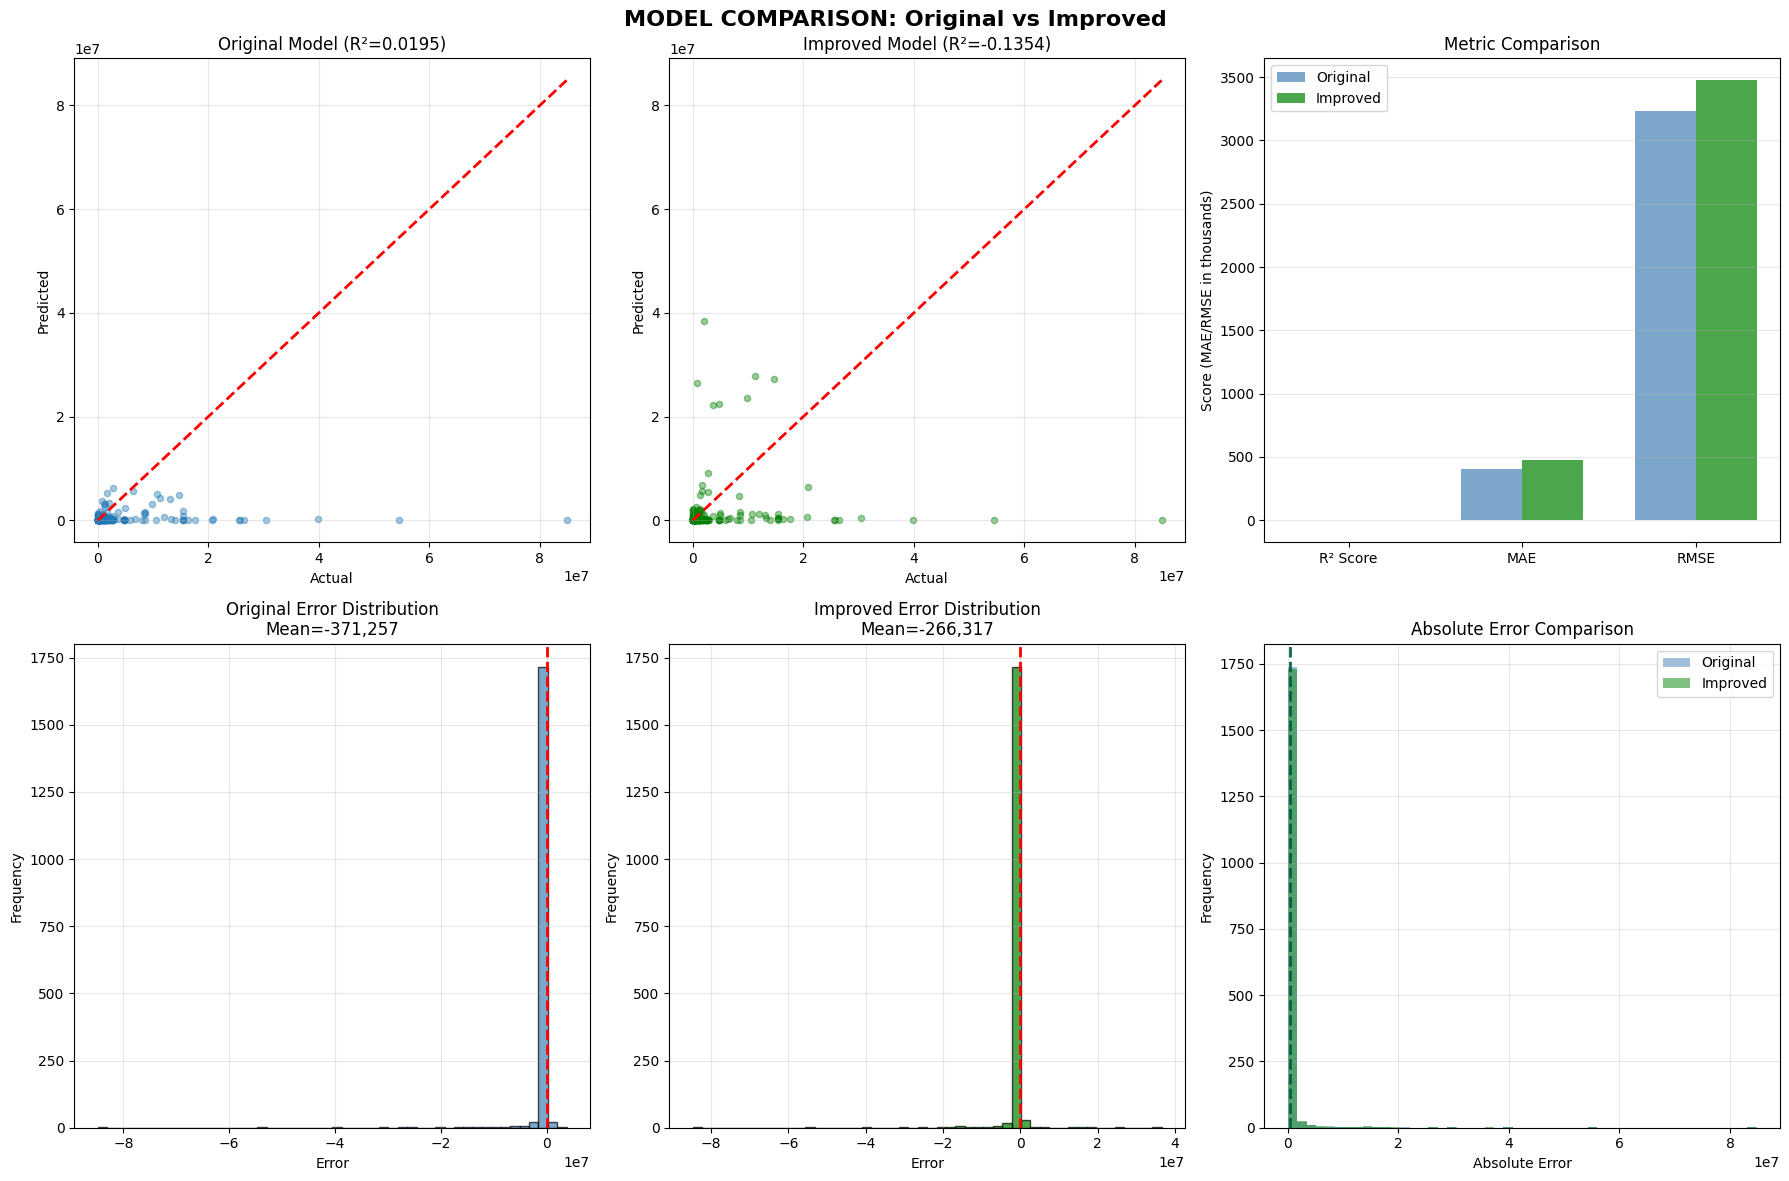


FINAL RECOMMENDATION:
⚠ ORIGINAL MODEL IS STILL BETTER
  • The improvements didn't help
  • May need different optimization strategies

✓ EVALUATION COMPLETE


In [22]:
# 23: Evaluate Improved Model
print("="*80)
print("IMPROVED MODEL EVALUATION")
print("="*80)

# Get predictions
_, test_predictions_log_v2, test_targets_log_v2 = evaluate(model_v2, test_loader, criterion_v2, device)

# Convert back from log scale
test_predictions_v2 = np.expm1(test_predictions_log_v2.flatten())
test_targets_v2 = np.expm1(test_targets_log_v2.flatten())

# Calculate metrics
mse_v2 = mean_squared_error(test_targets_v2, test_predictions_v2)
rmse_v2 = np.sqrt(mse_v2)
mae_v2 = mean_absolute_error(test_targets_v2, test_predictions_v2)
r2_v2 = r2_score(test_targets_v2, test_predictions_v2)
mape_v2 = np.mean(np.abs((test_targets_v2 - test_predictions_v2) / (test_targets_v2 + 1))) * 100

# Performance comparison
print("\n" + "="*80)
print("PERFORMANCE COMPARISON:")
print("="*80)

comparison_results = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE', 'MAPE (%)'],
    'Original Model': [r2_original, rmse_original, mae_original, mape],
    'Improved Model': [r2_v2, rmse_v2, mae_v2, mape_v2],
})
comparison_results['Improvement'] = ((comparison_results['Improved Model'] - comparison_results['Original Model']) / 
                                     comparison_results['Original Model'] * 100).round(2)
comparison_results['Improvement'] = comparison_results['Improvement'].apply(lambda x: f"{x:+.2f}%")

display(comparison_results)

# Overall assessment
print("\n" + "="*80)
print("IMPROVEMENT SUMMARY:")
print("="*80)

if r2_v2 > r2_original:
    improvement_pct = ((r2_v2 - r2_original) / abs(r2_original) * 100) if r2_original != 0 else float('inf')
    print(f"✓ R² improved from {r2_original:.4f} to {r2_v2:.4f} ({improvement_pct:+.1f}%)")
else:
    print(f"⚠ R² decreased from {r2_original:.4f} to {r2_v2:.4f}")

if mae_v2 < mae_original:
    improvement_pct = ((mae_original - mae_v2) / mae_original * 100)
    print(f"✓ MAE improved from {mae_original:,.0f} to {mae_v2:,.0f} ({improvement_pct:.1f}% reduction)")
else:
    print(f"⚠ MAE increased from {mae_original:,.0f} to {mae_v2:,.0f}")

# Visual comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('MODEL COMPARISON: Original vs Improved', fontsize=16, fontweight='bold')

# 1. Predictions vs Actual - Original
axes[0, 0].scatter(test_targets, test_predictions, alpha=0.4, s=20)
axes[0, 0].plot([test_targets.min(), test_targets.max()], 
                [test_targets.min(), test_targets.max()], 
                'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Original Model (R²={r2_original:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Predictions vs Actual - Improved
axes[0, 1].scatter(test_targets_v2, test_predictions_v2, alpha=0.4, s=20, color='green')
axes[0, 1].plot([test_targets_v2.min(), test_targets_v2.max()], 
                [test_targets_v2.min(), test_targets_v2.max()], 
                'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Improved Model (R²={r2_v2:.4f})')
axes[0, 1].grid(True, alpha=0.3)

# 3. Metric comparison bars
metrics_to_plot = ['R² Score', 'MAE', 'RMSE']
orig_values = [r2_original, mae_original/1000, rmse_original/1000]  # Scale MAE/RMSE for visualization
imp_values = [r2_v2, mae_v2/1000, rmse_v2/1000]

x_pos = np.arange(len(metrics_to_plot))
width = 0.35

axes[0, 2].bar(x_pos - width/2, orig_values, width, label='Original', alpha=0.7, color='steelblue')
axes[0, 2].bar(x_pos + width/2, imp_values, width, label='Improved', alpha=0.7, color='green')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(metrics_to_plot)
axes[0, 2].set_ylabel('Score (MAE/RMSE in thousands)')
axes[0, 2].set_title('Metric Comparison')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Error distribution - Original
errors_orig = test_predictions - test_targets
axes[1, 0].hist(errors_orig, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Error')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Original Error Distribution\nMean={errors_orig.mean():,.0f}')
axes[1, 0].grid(True, alpha=0.3)

# 5. Error distribution - Improved
errors_v2 = test_predictions_v2 - test_targets_v2
axes[1, 1].hist(errors_v2, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Improved Error Distribution\nMean={errors_v2.mean():,.0f}')
axes[1, 1].grid(True, alpha=0.3)

# 6. Absolute error comparison
abs_errors_orig = np.abs(errors_orig)
abs_errors_v2 = np.abs(errors_v2)

axes[1, 2].hist(abs_errors_orig, bins=50, alpha=0.5, label='Original', color='steelblue')
axes[1, 2].hist(abs_errors_v2, bins=50, alpha=0.5, label='Improved', color='green')
axes[1, 2].axvline(x=mae_original, color='blue', linestyle='--', lw=2, alpha=0.7)
axes[1, 2].axvline(x=mae_v2, color='green', linestyle='--', lw=2, alpha=0.7)
axes[1, 2].set_xlabel('Absolute Error')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Absolute Error Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determine best model
print("\n" + "="*80)
print("FINAL RECOMMENDATION:")
print("="*80)

if r2_v2 > r2_original and mae_v2 < mae_original:
    print("✓ IMPROVED MODEL IS BETTER")
    print(f"  • Use model_v2 for predictions")
    print(f"  • R² improvement: {r2_original:.4f} → {r2_v2:.4f}")
    print(f"  • MAE improvement: {mae_original:,.0f} → {mae_v2:,.0f}")
    best_model = model_v2
    best_config = IMPROVED_CONFIG
elif r2_v2 > r2_original or mae_v2 < mae_original:
    print("⚠ MIXED RESULTS")
    print("  • Some metrics improved, others didn't")
    print("  • Consider which metric is more important for your use case")
    if r2_v2 > r2_original:
        print("  → Improved model has better R² (explains more variance)")
        best_model = model_v2
        best_config = IMPROVED_CONFIG
    else:
        print("  → Original model has better overall performance")
        best_model = model
        best_config = MODEL_CONFIG
else:
    print("⚠ ORIGINAL MODEL IS STILL BETTER")
    print("  • The improvements didn't help")
    print("  • May need different optimization strategies")
    best_model = model
    best_config = MODEL_CONFIG

print("\n" + "="*80)
print("✓ EVALUATION COMPLETE")
print("="*80)

## Direct View Prediction (Without Log Transformation)

Let's train a neural network to predict **original view counts directly** instead of log-transformed values. This approach may capture the actual distribution better.

In [23]:
# ================================================================================
# DATA PREPARATION FOR DIRECT VIEW PREDICTION
# ================================================================================

print("=" * 80)
print("PREPARING DATA FOR DIRECT VIEW PREDICTION (NO LOG TRANSFORMATION)")
print("=" * 80)
print()

# Use original view counts (already have y_train and y_test)
print("Target Statistics:")
print("-" * 80)
print(f"Training set:")
print(f"  Mean:   {y_train.mean():,.0f} views")
print(f"  Median: {np.median(y_train):,.0f} views")
print(f"  Std:    {y_train.std():,.0f}")
print(f"  Min:    {y_train.min():,.0f} views")
print(f"  Max:    {y_train.max():,.0f} views")
print()
print(f"Test set:")
print(f"  Mean:   {y_test.mean():,.0f} views")
print(f"  Median: {np.median(y_test):,.0f} views")
print(f"  Std:    {y_test.std():,.0f}")
print(f"  Min:    {y_test.min():,.0f} views")
print(f"  Max:    {y_test.max():,.0f} views")
print()

# Normalize target to prevent exploding gradients
# Use a simple scaling factor based on the mean
view_scale_factor = y_train.mean()
y_train_scaled = y_train / view_scale_factor
y_test_scaled = y_test / view_scale_factor

print(f"Scaling factor: {view_scale_factor:,.0f}")
print(f"Scaled training target range: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")
print(f"Scaled test target range: [{y_test_scaled.min():.4f}, {y_test_scaled.max():.4f}]")
print()

# Create PyTorch datasets with scaled targets
class YouTubeShortsDatasetDirect(torch.utils.data.Dataset):
    def __init__(self, features, targets):
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets).reshape(-1, 1)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Create datasets
train_dataset_direct = YouTubeShortsDatasetDirect(X_train_scaled, y_train_scaled)
test_dataset_direct = YouTubeShortsDatasetDirect(X_test_scaled, y_test_scaled)

# Create data loaders
train_loader_direct = torch.utils.data.DataLoader(
    train_dataset_direct,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader_direct = torch.utils.data.DataLoader(
    test_dataset_direct,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(train_loader_direct)}")
print(f"Test batches:     {len(test_loader_direct)}")
print()

print("=" * 80)
print("✓ DATA PREPARATION COMPLETE")
print("=" * 80)

PREPARING DATA FOR DIRECT VIEW PREDICTION (NO LOG TRANSFORMATION)

Target Statistics:
--------------------------------------------------------------------------------
Training set:
  Mean:   442,329 views
  Median: 1,338 views
  Std:    3,519,943
  Min:    100 views
  Max:    170,055,190 views

Test set:
  Mean:   427,179 views
  Median: 1,338 views
  Std:    3,261,126
  Min:    100 views
  Max:    84,820,251 views

Scaling factor: 442,329
Scaled training target range: [0.0002, 384.4540]
Scaled test target range: [0.0002, 191.7583]

Training batches: 113
Test batches:     29

✓ DATA PREPARATION COMPLETE


In [24]:
# ================================================================================
# NEURAL NETWORK FOR DIRECT VIEW PREDICTION
# ================================================================================

print("=" * 80)
print("BUILDING NEURAL NETWORK FOR DIRECT VIEW PREDICTION")
print("=" * 80)
print()

# Import functional module for activations
import torch.nn.functional as F

# Use same architecture but with ReLU output for positive predictions
class MultimodalViewPredictorDirect(nn.Module):
    def __init__(self, config):
        super().__init__()
        
        # Extract dimensions
        temporal_dim = config['temporal_dim']
        title_emb_dim = config['title_emb_dim']
        tag_emb_dim = config['tag_emb_dim']
        desc_emb_dim = config['desc_emb_dim']
        thumb_emb_dim = config['thumb_emb_dim']
        hidden_dims = config['hidden_dims']
        dropout_rate = config['dropout_rate']
        
        # Modality-specific branches
        self.temporal_branch = nn.Sequential(
            nn.Linear(temporal_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate)
        )
        
        self.title_branch = nn.Sequential(
            nn.Linear(title_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.tag_branch = nn.Sequential(
            nn.Linear(tag_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.desc_branch = nn.Sequential(
            nn.Linear(desc_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.thumb_branch = nn.Sequential(
            nn.Linear(thumb_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layer
        fusion_input_dim = 32 + 128 + 128 + 128 + 128  # Sum of all branch outputs
        self.fusion = nn.Linear(fusion_input_dim, hidden_dims[0])
        self.fusion_bn = nn.BatchNorm1d(hidden_dims[0])
        self.fusion_dropout = nn.Dropout(dropout_rate)
        
        # Deep prediction head
        layers = []
        in_features = hidden_dims[0]
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(in_features, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout_rate)
            ])
            in_features = hidden_dim
        
        self.predictor = nn.Sequential(*layers)
        
        # Output layer with ReLU to ensure positive predictions
        self.output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.ReLU()  # Ensure positive predictions
        )
        
        self.config = config
    
    def forward(self, x):
        # Split input into modalities
        temporal = x[:, :self.config['temporal_dim']]
        title_emb = x[:, self.config['temporal_dim']:self.config['temporal_dim']+self.config['title_emb_dim']]
        tag_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']:
                      self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']]
        desc_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']:
                       self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']+self.config['desc_emb_dim']]
        thumb_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']+self.config['desc_emb_dim']:]
        
        # Process each modality
        temporal_out = self.temporal_branch(temporal)
        title_out = self.title_branch(title_emb)
        tag_out = self.tag_branch(tag_emb)
        desc_out = self.desc_branch(desc_emb)
        thumb_out = self.thumb_branch(thumb_emb)
        
        # Concatenate all modalities
        fused = torch.cat([temporal_out, title_out, tag_out, desc_out, thumb_out], dim=1)
        
        # Fusion layer
        fused = self.fusion(fused)
        fused = F.relu(fused)
        fused = self.fusion_bn(fused)
        fused = self.fusion_dropout(fused)
        
        # Deep prediction
        pred = self.predictor(fused)
        output = self.output(pred)
        
        return output

# Configuration - use improved architecture
DIRECT_CONFIG = {
    'temporal_dim': 6,
    'title_emb_dim': 384,
    'tag_emb_dim': 384,
    'desc_emb_dim': 384,
    'thumb_emb_dim': 512,
    'hidden_dims': [512, 256, 128],  # Deep architecture
    'dropout_rate': 0.4
}

# Initialize model
model_direct = MultimodalViewPredictorDirect(DIRECT_CONFIG).to(device)

# Count parameters
total_params_direct = sum(p.numel() for p in model_direct.parameters())
trainable_params_direct = sum(p.numel() for p in model_direct.parameters() if p.requires_grad)

print(f"Model initialized on: {device}")
print(f"Total parameters:     {total_params_direct:,}")
print(f"Trainable parameters: {trainable_params_direct:,}")
print()

print("=" * 80)
print("✓ MODEL READY FOR TRAINING")
print("=" * 80)

BUILDING NEURAL NETWORK FOR DIRECT VIEW PREDICTION

Model initialized on: cpu
Total parameters:     660,001
Trainable parameters: 660,001

✓ MODEL READY FOR TRAINING


In [25]:
# ================================================================================
# TRAIN DIRECT VIEW PREDICTION MODEL
# ================================================================================

print("=" * 80)
print("TRAINING NEURAL NETWORK FOR DIRECT VIEW PREDICTION")
print("=" * 80)
print()

# Training configuration
NUM_EPOCHS_DIRECT = 100
LEARNING_RATE_DIRECT = 0.001
PATIENCE_DIRECT = 15

# Use Huber Loss (robust to outliers) instead of MSE
criterion_direct = nn.HuberLoss(delta=0.5)
optimizer_direct = torch.optim.AdamW(
    model_direct.parameters(),
    lr=LEARNING_RATE_DIRECT,
    weight_decay=1e-4
)
scheduler_direct = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_direct,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("Training Configuration:")
print(f"  Loss function:    Huber Loss (delta=0.5)")
print(f"  Optimizer:        AdamW")
print(f"  Learning rate:    {LEARNING_RATE_DIRECT}")
print(f"  Weight decay:     1e-4")
print(f"  Max epochs:       {NUM_EPOCHS_DIRECT}")
print(f"  Early stopping:   {PATIENCE_DIRECT} epochs")
print(f"  Batch size:       {BATCH_SIZE}")
print()

# Training functions
def train_epoch_direct(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for features, targets in loader:
        features, targets = features.to(device), targets.to(device)
        
        # Forward pass
        predictions = model(features)
        loss = criterion(predictions, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate_direct(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            
            predictions = model(features)
            loss = criterion(predictions, targets)
            
            total_loss += loss.item()
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    predictions = np.concatenate(all_predictions)
    targets = np.concatenate(all_targets)
    
    return avg_loss, predictions, targets

# Training loop
print("=" * 80)
print("TRAINING PROGRESS")
print("=" * 80)

train_losses_direct = []
test_losses_direct = []
best_test_loss_direct = float('inf')
best_model_state_direct = None
patience_counter_direct = 0

start_time_direct = time.time()

for epoch in range(NUM_EPOCHS_DIRECT):
    epoch_start = time.time()
    
    # Train
    train_loss = train_epoch_direct(model_direct, train_loader_direct, 
                                      criterion_direct, optimizer_direct, device)
    
    # Evaluate
    test_loss, _, _ = evaluate_direct(model_direct, test_loader_direct, 
                                        criterion_direct, device)
    
    # Update learning rate
    scheduler_direct.step(test_loss)
    current_lr = optimizer_direct.param_groups[0]['lr']
    
    # Save losses
    train_losses_direct.append(train_loss)
    test_losses_direct.append(test_loss)
    
    # Check for improvement
    if test_loss < best_test_loss_direct:
        best_test_loss_direct = test_loss
        best_model_state_direct = {
            'epoch': epoch,
            'model_state_dict': model_direct.state_dict(),
            'optimizer_state_dict': optimizer_direct.state_dict(),
            'test_loss': test_loss,
            'train_loss': train_loss
        }
        patience_counter_direct = 0
        improvement_marker = " ✓ BEST"
    else:
        patience_counter_direct += 1
        improvement_marker = ""
    
    epoch_time = time.time() - epoch_start
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS_DIRECT}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Test Loss: {test_loss:.6f} | "
              f"LR: {current_lr:.2e} | "
              f"Time: {epoch_time:.2f}s{improvement_marker}")
    
    # Early stopping
    if patience_counter_direct >= PATIENCE_DIRECT:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

total_time_direct = time.time() - start_time_direct

# Load best model
model_direct.load_state_dict(best_model_state_direct['model_state_dict'])

print()
print("=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"Total training time: {total_time_direct:.2f} seconds ({total_time_direct/60:.2f} minutes)")
print(f"Best epoch:          {best_model_state_direct['epoch']+1}/{len(train_losses_direct)}")
print(f"Best test loss:      {best_test_loss_direct:.6f}")
print(f"Final learning rate: {optimizer_direct.param_groups[0]['lr']:.2e}")
print()

print("=" * 80)
print("✓ TRAINING COMPLETE")
print("=" * 80)

TRAINING NEURAL NETWORK FOR DIRECT VIEW PREDICTION

Training Configuration:
  Loss function:    Huber Loss (delta=0.5)
  Optimizer:        AdamW
  Learning rate:    0.001
  Weight decay:     1e-4
  Max epochs:       100
  Early stopping:   15 epochs
  Batch size:       64

TRAINING PROGRESS
Epoch [  1/100] | Train Loss: 0.495030 | Test Loss: 0.454991 | LR: 1.00e-03 | Time: 2.58s ✓ BEST
Epoch [  1/100] | Train Loss: 0.495030 | Test Loss: 0.454991 | LR: 1.00e-03 | Time: 2.58s ✓ BEST
Epoch [ 10/100] | Train Loss: 0.417921 | Test Loss: 0.421207 | LR: 1.00e-03 | Time: 2.05s ✓ BEST
Epoch [ 10/100] | Train Loss: 0.417921 | Test Loss: 0.421207 | LR: 1.00e-03 | Time: 2.05s ✓ BEST
Epoch [ 20/100] | Train Loss: 0.363439 | Test Loss: 0.423717 | LR: 5.00e-04 | Time: 1.99s
Epoch [ 20/100] | Train Loss: 0.363439 | Test Loss: 0.423717 | LR: 5.00e-04 | Time: 1.99s
Epoch [ 30/100] | Train Loss: 0.334955 | Test Loss: 0.417820 | LR: 2.50e-04 | Time: 1.99s
Epoch [ 30/100] | Train Loss: 0.334955 | Test Loss

EVALUATING DIRECT VIEW PREDICTION MODEL

MODEL PERFORMANCE:
R² Score: 0.039451
MAE:      395,911 views
RMSE:     3,196,152 views
MAPE:     522.47%

ERROR STATISTICS:
--------------------------------------------------------------------------------
Mean error:           339,649 views
Std error:            3,178,053 views
Mean absolute error:  395,911 views
Median absolute error: 1,342 views
Max error:            84,820,251 views



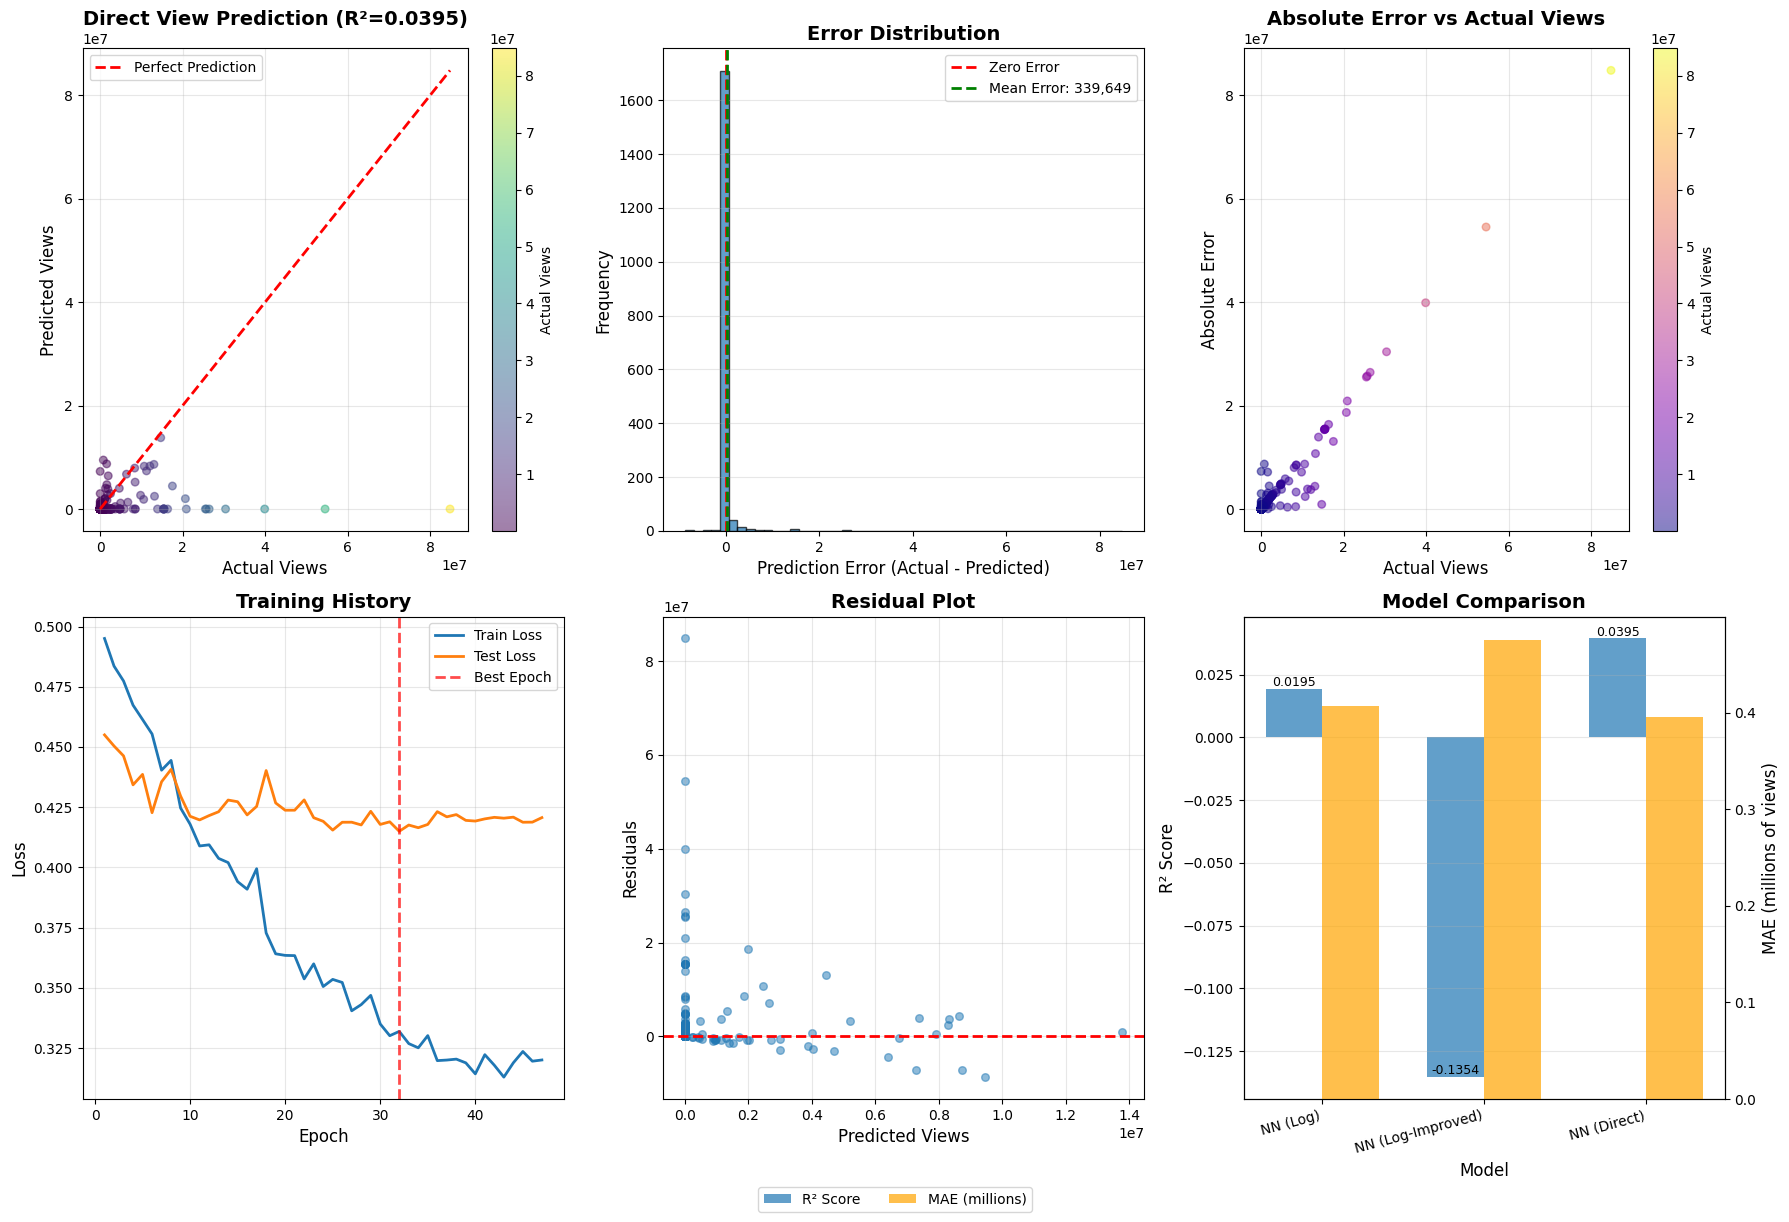


✓ EVALUATION COMPLETE


In [26]:
# ================================================================================
# EVALUATE DIRECT VIEW PREDICTION MODEL
# ================================================================================

print("=" * 80)
print("EVALUATING DIRECT VIEW PREDICTION MODEL")
print("=" * 80)
print()

# Get predictions
_, test_predictions_scaled, test_targets_scaled = evaluate_direct(
    model_direct, test_loader_direct, criterion_direct, device
)

# Convert back to original scale
test_predictions_direct = test_predictions_scaled.flatten() * view_scale_factor
test_targets_direct = test_targets_scaled.flatten() * view_scale_factor

# Calculate metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_direct = r2_score(test_targets_direct, test_predictions_direct)
mae_direct = mean_absolute_error(test_targets_direct, test_predictions_direct)
rmse_direct = np.sqrt(mean_squared_error(test_targets_direct, test_predictions_direct))

# MAPE
mape_direct = np.mean(np.abs((test_targets_direct - test_predictions_direct) / 
                              np.maximum(test_targets_direct, 1))) * 100

print("MODEL PERFORMANCE:")
print("=" * 80)
print(f"R² Score: {r2_direct:.6f}")
print(f"MAE:      {mae_direct:,.0f} views")
print(f"RMSE:     {rmse_direct:,.0f} views")
print(f"MAPE:     {mape_direct:.2f}%")
print()

# Error analysis
errors_direct = test_targets_direct - test_predictions_direct
abs_errors_direct = np.abs(errors_direct)

print("ERROR STATISTICS:")
print("-" * 80)
print(f"Mean error:           {errors_direct.mean():,.0f} views")
print(f"Std error:            {errors_direct.std():,.0f} views")
print(f"Mean absolute error:  {abs_errors_direct.mean():,.0f} views")
print(f"Median absolute error: {np.median(abs_errors_direct):,.0f} views")
print(f"Max error:            {abs_errors_direct.max():,.0f} views")
print()

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Predictions vs Actuals
ax = axes[0, 0]
scatter = ax.scatter(test_targets_direct, test_predictions_direct, 
                     alpha=0.5, s=30, c=test_targets_direct, cmap='viridis')
ax.plot([test_targets_direct.min(), test_targets_direct.max()],
        [test_targets_direct.min(), test_targets_direct.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Views', fontsize=12)
ax.set_ylabel('Predicted Views', fontsize=12)
ax.set_title(f'Direct View Prediction (R²={r2_direct:.4f})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Actual Views')

# 2. Error distribution
ax = axes[0, 1]
ax.hist(errors_direct, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax.axvline(x=errors_direct.mean(), color='g', linestyle='--', linewidth=2, 
           label=f'Mean Error: {errors_direct.mean():,.0f}')
ax.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Absolute error vs actual views
ax = axes[0, 2]
scatter = ax.scatter(test_targets_direct, abs_errors_direct, 
                     alpha=0.5, s=30, c=test_targets_direct, cmap='plasma')
ax.set_xlabel('Actual Views', fontsize=12)
ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Absolute Error vs Actual Views', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Actual Views')

# 4. Training curves
ax = axes[1, 0]
epochs_direct = range(1, len(train_losses_direct) + 1)
ax.plot(epochs_direct, train_losses_direct, label='Train Loss', linewidth=2)
ax.plot(epochs_direct, test_losses_direct, label='Test Loss', linewidth=2)
ax.axvline(x=best_model_state_direct['epoch']+1, color='r', linestyle='--', 
           linewidth=2, alpha=0.7, label='Best Epoch')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training History', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 5. Residuals
ax = axes[1, 1]
ax.scatter(test_predictions_direct, errors_direct, alpha=0.5, s=30)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Views', fontsize=12)
ax.set_ylabel('Residuals', fontsize=12)
ax.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# 6. Comparison with log-based models
ax = axes[1, 2]
models = ['NN (Log)', 'NN (Log-Improved)', 'NN (Direct)']
r2_scores = [r2_original, r2_v2, r2_direct]
mae_scores = [mae_original, mae_v2, mae_direct]

x_pos = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x_pos - width/2, r2_scores, width, label='R² Score', alpha=0.7)
ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + width/2, [m/1e6 for m in mae_scores], width, 
                label='MAE (millions)', alpha=0.7, color='orange')

ax.set_ylabel('R² Score', fontsize=12)
ax2.set_ylabel('MAE (millions of views)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, r2_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.legend([bars1, bars2], ['R² Score', 'MAE (millions)'], 
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print()
print("=" * 80)
print("✓ EVALUATION COMPLETE")
print("=" * 80)

## 🎯 Binary Classification: Predicting "Winner" Videos

**Key Insight**: View count prediction is difficult due to external factors (YouTube algorithm, seasonality, user behavior). Instead, we'll predict whether a video will be a **"winner"** (recommended by YouTube).

**Classification Target**:
- **Class 1 (Winner)**: Videos with ≥1,000 views (YouTube pushes these)
- **Class 0 (Non-winner)**: Videos with <1,000 views

This approach is more practical and actionable for content creators!

In [27]:
# ================================================================================
# CREATE BINARY CLASSIFICATION TARGET
# ================================================================================

print("=" * 80)
print("CREATING BINARY CLASSIFICATION TARGET")
print("=" * 80)
print()

# Define threshold for "winner" videos
VIEW_THRESHOLD = 1000

# Create binary labels
y_train_binary = (y_train >= VIEW_THRESHOLD).astype(int)
y_test_binary = (y_test >= VIEW_THRESHOLD).astype(int)

print(f"Classification Threshold: {VIEW_THRESHOLD:,} views")
print()

# Analyze class distribution
print("Training Set Class Distribution:")
print("-" * 80)
train_class_counts = pd.Series(y_train_binary).value_counts().sort_index()
for class_label, count in train_class_counts.items():
    class_name = "Winners (≥1,000 views)" if class_label == 1 else "Non-winners (<1,000 views)"
    percentage = count / len(y_train_binary) * 100
    print(f"  Class {class_label} ({class_name}): {count:,} ({percentage:.2f}%)")

print()
print("Test Set Class Distribution:")
print("-" * 80)
test_class_counts = pd.Series(y_test_binary).value_counts().sort_index()
for class_label, count in test_class_counts.items():
    class_name = "Winners (≥1,000 views)" if class_label == 1 else "Non-winners (<1,000 views)"
    percentage = count / len(y_test_binary) * 100
    print(f"  Class {class_label} ({class_name}): {count:,} ({percentage:.2f}%)")

print()

# Check for class imbalance
class_ratio = train_class_counts.min() / train_class_counts.max()
print(f"Class Balance Ratio: {class_ratio:.4f}")
if class_ratio < 0.3:
    print("  ⚠ Significant class imbalance detected!")
    print(f"  → Will use class weights to handle imbalance")
elif class_ratio < 0.5:
    print("  ⚠ Moderate class imbalance")
    print(f"  → Will use class weights")
else:
    print("  ✓ Classes are reasonably balanced")

print()

# Calculate class weights for balanced training
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_binary
)

print("Class Weights (for balanced training):")
print(f"  Class 0 weight: {class_weights[0]:.4f}")
print(f"  Class 1 weight: {class_weights[1]:.4f}")
print()

# Create PyTorch datasets for classification
class YouTubeShortsDatasetBinary(torch.utils.data.Dataset):
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset_binary = YouTubeShortsDatasetBinary(X_train_scaled, y_train_binary)
test_dataset_binary = YouTubeShortsDatasetBinary(X_test_scaled, y_test_binary)

# Create data loaders
train_loader_binary = torch.utils.data.DataLoader(
    train_dataset_binary,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader_binary = torch.utils.data.DataLoader(
    test_dataset_binary,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(train_loader_binary)}")
print(f"Test batches:     {len(test_loader_binary)}")
print()

print("=" * 80)
print("✓ BINARY CLASSIFICATION DATA READY")
print("=" * 80)

CREATING BINARY CLASSIFICATION TARGET

Classification Threshold: 1,000 views

Training Set Class Distribution:
--------------------------------------------------------------------------------
  Class 0 (Non-winners (<1,000 views)): 3,027 (42.00%)
  Class 1 (Winners (≥1,000 views)): 4,181 (58.00%)

Test Set Class Distribution:
--------------------------------------------------------------------------------
  Class 0 (Non-winners (<1,000 views)): 763 (42.32%)
  Class 1 (Winners (≥1,000 views)): 1,040 (57.68%)

Class Balance Ratio: 0.7240
  ✓ Classes are reasonably balanced

Class Weights (for balanced training):
  Class 0 weight: 1.1906
  Class 1 weight: 0.8620

Training batches: 113
Test batches:     29

✓ BINARY CLASSIFICATION DATA READY


BUILDING BINARY CLASSIFICATION MODEL

Model initialized on: cpu
Total parameters:     660,130
Trainable parameters: 660,130

Model Architecture:
--------------------------------------------------------------------------------
  Input: 1,670 features (temporal + embeddings)
  → Modality branches: 5 separate encoders
  → Fusion layer: 512 units
  → Deep classifier: 512 → 256 → 128
  → Output: 2 classes (non-winner / winner)

ARCHITECTURE VISUALIZATION



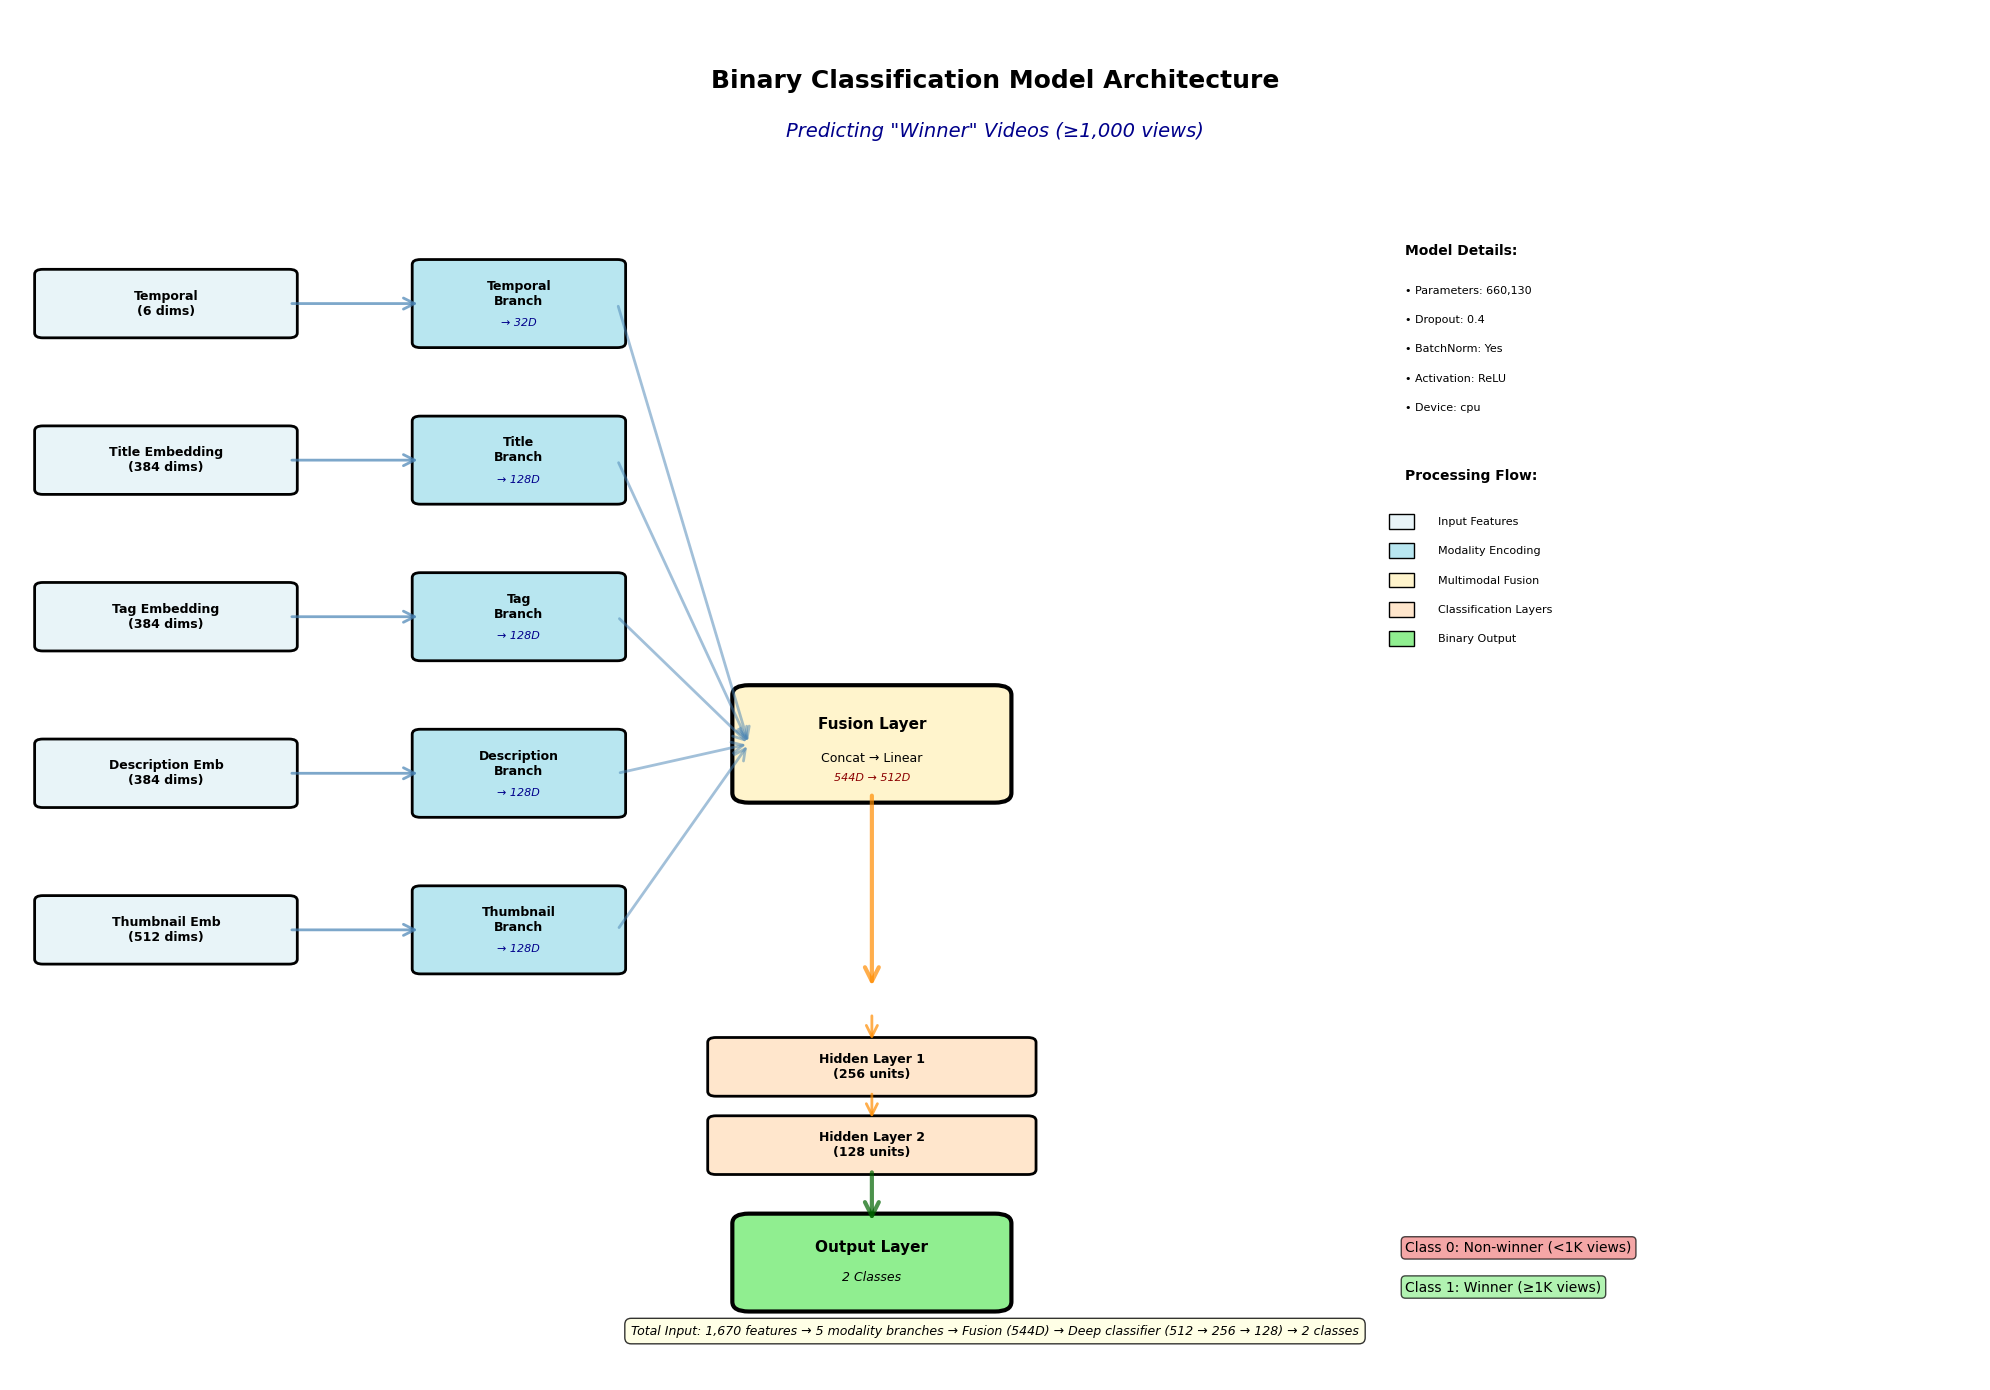


✓ CLASSIFICATION MODEL READY


In [28]:
# ================================================================================
# BINARY CLASSIFICATION NEURAL NETWORK
# ================================================================================

print("=" * 80)
print("BUILDING BINARY CLASSIFICATION MODEL")
print("=" * 80)
print()

import torch.nn.functional as F

class MultimodalWinnerClassifier(nn.Module):
    """
    Neural network for binary classification: predicting if a video will be a 'winner'
    (≥1,000 views) based on multimodal features.
    """
    def __init__(self, config):
        super().__init__()
        
        # Extract dimensions
        temporal_dim = config['temporal_dim']
        title_emb_dim = config['title_emb_dim']
        tag_emb_dim = config['tag_emb_dim']
        desc_emb_dim = config['desc_emb_dim']
        thumb_emb_dim = config['thumb_emb_dim']
        hidden_dims = config['hidden_dims']
        dropout_rate = config['dropout_rate']
        
        # Modality-specific branches
        self.temporal_branch = nn.Sequential(
            nn.Linear(temporal_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate)
        )
        
        self.title_branch = nn.Sequential(
            nn.Linear(title_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.tag_branch = nn.Sequential(
            nn.Linear(tag_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.desc_branch = nn.Sequential(
            nn.Linear(desc_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        self.thumb_branch = nn.Sequential(
            nn.Linear(thumb_emb_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layer
        fusion_input_dim = 32 + 128 + 128 + 128 + 128
        self.fusion = nn.Linear(fusion_input_dim, hidden_dims[0])
        self.fusion_bn = nn.BatchNorm1d(hidden_dims[0])
        self.fusion_dropout = nn.Dropout(dropout_rate)
        
        # Deep classification head
        layers = []
        in_features = hidden_dims[0]
        for hidden_dim in hidden_dims[1:]:
            layers.extend([
                nn.Linear(in_features, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout_rate)
            ])
            in_features = hidden_dim
        
        self.classifier = nn.Sequential(*layers)
        
        # Output layer (2 classes: non-winner, winner)
        self.output = nn.Linear(in_features, 2)
        
        self.config = config
    
    def forward(self, x):
        # Split input into modalities
        temporal = x[:, :self.config['temporal_dim']]
        title_emb = x[:, self.config['temporal_dim']:self.config['temporal_dim']+self.config['title_emb_dim']]
        tag_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']:
                      self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']]
        desc_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']:
                       self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']+self.config['desc_emb_dim']]
        thumb_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']+self.config['desc_emb_dim']:]
        
        # Process each modality
        temporal_out = self.temporal_branch(temporal)
        title_out = self.title_branch(title_emb)
        tag_out = self.tag_branch(tag_emb)
        desc_out = self.desc_branch(desc_emb)
        thumb_out = self.thumb_branch(thumb_emb)
        
        # Concatenate all modalities
        fused = torch.cat([temporal_out, title_out, tag_out, desc_out, thumb_out], dim=1)
        
        # Fusion layer
        fused = self.fusion(fused)
        fused = F.relu(fused)
        fused = self.fusion_bn(fused)
        fused = self.fusion_dropout(fused)
        
        # Classification head
        features = self.classifier(fused)
        logits = self.output(features)
        
        return logits

# Configuration
CLASSIFIER_CONFIG = {
    'temporal_dim': 6,
    'title_emb_dim': 384,
    'tag_emb_dim': 384,
    'desc_emb_dim': 384,
    'thumb_emb_dim': 512,
    'hidden_dims': [512, 256, 128],
    'dropout_rate': 0.4
}

# Initialize model
model_classifier = MultimodalWinnerClassifier(CLASSIFIER_CONFIG).to(device)

# Count parameters
total_params_clf = sum(p.numel() for p in model_classifier.parameters())
trainable_params_clf = sum(p.numel() for p in model_classifier.parameters() if p.requires_grad)

print(f"Model initialized on: {device}")
print(f"Total parameters:     {total_params_clf:,}")
print(f"Trainable parameters: {trainable_params_clf:,}")
print()

print("Model Architecture:")
print("-" * 80)
print(f"  Input: 1,670 features (temporal + embeddings)")
print(f"  → Modality branches: 5 separate encoders")
print(f"  → Fusion layer: {CLASSIFIER_CONFIG['hidden_dims'][0]} units")
print(f"  → Deep classifier: {' → '.join(map(str, CLASSIFIER_CONFIG['hidden_dims']))}")
print(f"  → Output: 2 classes (non-winner / winner)")
print()

# Visualize architecture
print("=" * 80)
print("ARCHITECTURE VISUALIZATION")
print("=" * 80)
print()

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(20, 14))
ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis('off')

# Title
ax.text(6, 13.2, 'Binary Classification Model Architecture', 
        fontsize=18, fontweight='bold', ha='center')
ax.text(6, 12.7, 'Predicting "Winner" Videos (≥1,000 views)', 
        fontsize=14, ha='center', style='italic', color='darkblue')

# Color scheme
color_input = '#E8F4F8'
color_branch = '#B8E6F0'
color_fusion = '#FFF4CC'
color_classifier = '#FFE6CC'
color_output = '#90EE90'

# Input features (left side)
y_start = 11
inputs = [
    ('Temporal\n(6 dims)', 6),
    ('Title Embedding\n(384 dims)', 384),
    ('Tag Embedding\n(384 dims)', 384),
    ('Description Emb\n(384 dims)', 384),
    ('Thumbnail Emb\n(512 dims)', 512)
]

input_boxes = []
for i, (name, dim) in enumerate(inputs):
    y = y_start - i * 1.6
    box = FancyBboxPatch((0.2, y-0.3), 1.5, 0.6, 
                          boxstyle="round,pad=0.05", 
                          edgecolor='black', facecolor=color_input, linewidth=2)
    ax.add_patch(box)
    ax.text(0.95, y, name, fontsize=9, ha='center', va='center', fontweight='bold')
    input_boxes.append((0.95, y))

# Modality branches (middle-left)
branch_outputs = []
branch_names = ['Temporal\nBranch', 'Title\nBranch', 'Tag\nBranch', 
                'Description\nBranch', 'Thumbnail\nBranch']
branch_dims = [32, 128, 128, 128, 128]

for i, (name, out_dim) in enumerate(zip(branch_names, branch_dims)):
    y = y_start - i * 1.6
    box = FancyBboxPatch((2.5, y-0.4), 1.2, 0.8,
                          boxstyle="round,pad=0.05",
                          edgecolor='black', facecolor=color_branch, linewidth=2)
    ax.add_patch(box)
    ax.text(3.1, y+0.1, name, fontsize=9, ha='center', va='center', fontweight='bold')
    ax.text(3.1, y-0.2, f'→ {out_dim}D', fontsize=8, ha='center', va='center', 
            style='italic', color='darkblue')
    branch_outputs.append((3.7, y))
    
    # Arrow from input to branch
    arrow = FancyArrowPatch((1.7, input_boxes[i][1]), (2.5, y),
                           arrowstyle='->', mutation_scale=20, linewidth=2,
                           color='steelblue', alpha=0.7)
    ax.add_artist(arrow)

# Fusion layer (middle)
fusion_y = 6.5
fusion_box = FancyBboxPatch((4.5, fusion_y-0.5), 1.5, 1.0,
                            boxstyle="round,pad=0.1",
                            edgecolor='black', facecolor=color_fusion, linewidth=3)
ax.add_patch(fusion_box)
ax.text(5.25, fusion_y+0.2, 'Fusion Layer', fontsize=11, ha='center', va='center', fontweight='bold')
ax.text(5.25, fusion_y-0.15, 'Concat → Linear', fontsize=9, ha='center', va='center')
ax.text(5.25, fusion_y-0.35, f'544D → {CLASSIFIER_CONFIG["hidden_dims"][0]}D', 
        fontsize=8, ha='center', va='center', style='italic', color='darkred')

# Arrows from branches to fusion
for x, y in branch_outputs:
    arrow = FancyArrowPatch((x, y), (4.5, fusion_y),
                           arrowstyle='->', mutation_scale=20, linewidth=2,
                           color='steelblue', alpha=0.5)
    ax.add_artist(arrow)

# Deep classifier layers
classifier_y_start = fusion_y - 2.5
layer_y_positions = []
for i, hidden_dim in enumerate(CLASSIFIER_CONFIG['hidden_dims'][1:], 1):
    y = classifier_y_start - i * 0.8
    box = FancyBboxPatch((4.3, y-0.25), 1.9, 0.5,
                          boxstyle="round,pad=0.05",
                          edgecolor='black', facecolor=color_classifier, linewidth=2)
    ax.add_patch(box)
    ax.text(5.25, y, f'Hidden Layer {i}\n({hidden_dim} units)', 
            fontsize=9, ha='center', va='center', fontweight='bold')
    layer_y_positions.append(y)

# Arrow from fusion to first classifier layer
arrow = FancyArrowPatch((5.25, fusion_y-0.5), (5.25, classifier_y_start),
                       arrowstyle='->', mutation_scale=25, linewidth=3,
                       color='darkorange', alpha=0.7)
ax.add_artist(arrow)

# Arrows between classifier layers
prev_y = classifier_y_start
for y in layer_y_positions:
    arrow = FancyArrowPatch((5.25, prev_y-0.25), (5.25, y+0.25),
                           arrowstyle='->', mutation_scale=20, linewidth=2,
                           color='darkorange', alpha=0.7)
    ax.add_artist(arrow)
    prev_y = y

# Output layer
output_y = layer_y_positions[-1] - 1.2
output_box = FancyBboxPatch((4.5, output_y-0.4), 1.5, 0.8,
                            boxstyle="round,pad=0.1",
                            edgecolor='black', facecolor=color_output, linewidth=3)
ax.add_patch(output_box)
ax.text(5.25, output_y+0.15, 'Output Layer', fontsize=11, ha='center', va='center', fontweight='bold')
ax.text(5.25, output_y-0.15, '2 Classes', fontsize=9, ha='center', va='center', style='italic')

# Arrow to output
arrow = FancyArrowPatch((5.25, layer_y_positions[-1]-0.25), (5.25, output_y+0.4),
                       arrowstyle='->', mutation_scale=25, linewidth=3,
                       color='darkgreen', alpha=0.7)
ax.add_artist(arrow)

# Class labels
ax.text(8.5, output_y+0.15, 'Class 0: Non-winner (<1K views)', 
        fontsize=10, ha='left', va='center', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))
ax.text(8.5, output_y-0.25, 'Class 1: Winner (≥1K views)', 
        fontsize=10, ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Technical details box
details_y = 11.5
ax.text(8.5, details_y, 'Model Details:', fontsize=10, fontweight='bold', ha='left')
ax.text(8.5, details_y-0.4, f'• Parameters: {total_params_clf:,}', fontsize=8, ha='left')
ax.text(8.5, details_y-0.7, f'• Dropout: {CLASSIFIER_CONFIG["dropout_rate"]}', fontsize=8, ha='left')
ax.text(8.5, details_y-1.0, f'• BatchNorm: Yes', fontsize=8, ha='left')
ax.text(8.5, details_y-1.3, f'• Activation: ReLU', fontsize=8, ha='left')
ax.text(8.5, details_y-1.6, f'• Device: {device}', fontsize=8, ha='left')

# Legend
legend_y = 9.2
ax.text(8.5, legend_y, 'Processing Flow:', fontsize=10, fontweight='bold', ha='left')
ax.add_patch(mpatches.Rectangle((8.4, legend_y-0.5), 0.15, 0.15, 
             facecolor=color_input, edgecolor='black'))
ax.text(8.7, legend_y-0.43, 'Input Features', fontsize=8, ha='left', va='center')

ax.add_patch(mpatches.Rectangle((8.4, legend_y-0.8), 0.15, 0.15, 
             facecolor=color_branch, edgecolor='black'))
ax.text(8.7, legend_y-0.73, 'Modality Encoding', fontsize=8, ha='left', va='center')

ax.add_patch(mpatches.Rectangle((8.4, legend_y-1.1), 0.15, 0.15, 
             facecolor=color_fusion, edgecolor='black'))
ax.text(8.7, legend_y-1.03, 'Multimodal Fusion', fontsize=8, ha='left', va='center')

ax.add_patch(mpatches.Rectangle((8.4, legend_y-1.4), 0.15, 0.15, 
             facecolor=color_classifier, edgecolor='black'))
ax.text(8.7, legend_y-1.33, 'Classification Layers', fontsize=8, ha='left', va='center')

ax.add_patch(mpatches.Rectangle((8.4, legend_y-1.7), 0.15, 0.15, 
             facecolor=color_output, edgecolor='black'))
ax.text(8.7, legend_y-1.63, 'Binary Output', fontsize=8, ha='left', va='center')

# Data flow annotation
ax.text(6, 0.5, 'Total Input: 1,670 features → 5 modality branches → Fusion (544D) → '
        f'Deep classifier ({" → ".join(map(str, CLASSIFIER_CONFIG["hidden_dims"]))}) → 2 classes',
        fontsize=9, ha='center', va='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.show()

print()
print("=" * 80)
print("✓ CLASSIFICATION MODEL READY")
print("=" * 80)

In [29]:
# ================================================================================
# TRAIN BINARY CLASSIFIER
# ================================================================================

print("=" * 80)
print("TRAINING WINNER VIDEO CLASSIFIER")
print("=" * 80)
print()

# Training configuration
NUM_EPOCHS_CLF = 100
LEARNING_RATE_CLF = 0.001
PATIENCE_CLF = 15

# Use weighted CrossEntropy for class imbalance
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion_clf = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer_clf = torch.optim.AdamW(
    model_classifier.parameters(),
    lr=LEARNING_RATE_CLF,
    weight_decay=1e-4
)

scheduler_clf = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_clf,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("Training Configuration:")
print(f"  Loss function:    CrossEntropy with class weights")
print(f"  Class 0 weight:   {class_weights[0]:.4f}")
print(f"  Class 1 weight:   {class_weights[1]:.4f}")
print(f"  Optimizer:        AdamW")
print(f"  Learning rate:    {LEARNING_RATE_CLF}")
print(f"  Weight decay:     1e-4")
print(f"  Max epochs:       {NUM_EPOCHS_CLF}")
print(f"  Early stopping:   {PATIENCE_CLF} epochs")
print(f"  Batch size:       {BATCH_SIZE}")
print()

# Training functions
def train_epoch_clf(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        logits = model(features)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Calculate accuracy
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate_clf(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            
            logits = model(features)
            loss = criterion(logits, labels)
            
            # Get predictions and probabilities
            probs = F.softmax(logits, dim=1)
            _, predicted = torch.max(logits, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    return avg_loss, accuracy, np.array(all_predictions), np.array(all_labels), np.array(all_probs)

# Training loop
print("=" * 80)
print("TRAINING PROGRESS")
print("=" * 80)

train_losses_clf = []
test_losses_clf = []
train_accs_clf = []
test_accs_clf = []
best_test_acc = 0.0
best_model_state_clf = None
patience_counter_clf = 0

start_time_clf = time.time()

for epoch in range(NUM_EPOCHS_CLF):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch_clf(model_classifier, train_loader_binary,
                                             criterion_clf, optimizer_clf, device)
    
    # Evaluate
    test_loss, test_acc, _, _, _ = evaluate_clf(model_classifier, test_loader_binary,
                                                  criterion_clf, device)
    
    # Update learning rate
    scheduler_clf.step(test_loss)
    current_lr = optimizer_clf.param_groups[0]['lr']
    
    # Save metrics
    train_losses_clf.append(train_loss)
    test_losses_clf.append(test_loss)
    train_accs_clf.append(train_acc)
    test_accs_clf.append(test_acc)
    
    # Check for improvement (use accuracy for classification)
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_clf = {
            'epoch': epoch,
            'model_state_dict': model_classifier.state_dict(),
            'optimizer_state_dict': optimizer_clf.state_dict(),
            'test_loss': test_loss,
            'test_acc': test_acc,
            'train_acc': train_acc
        }
        patience_counter_clf = 0
        improvement_marker = " ✓ BEST"
    else:
        patience_counter_clf += 1
        improvement_marker = ""
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS_CLF}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
              f"LR: {current_lr:.2e}{improvement_marker}")
    
    # Early stopping
    if patience_counter_clf >= PATIENCE_CLF:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

total_time_clf = time.time() - start_time_clf

# Load best model
model_classifier.load_state_dict(best_model_state_clf['model_state_dict'])

print()
print("=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"Total training time:  {total_time_clf:.2f} seconds ({total_time_clf/60:.2f} minutes)")
print(f"Best epoch:           {best_model_state_clf['epoch']+1}/{len(train_losses_clf)}")
print(f"Best test accuracy:   {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print(f"Best test loss:       {best_model_state_clf['test_loss']:.4f}")
print(f"Final learning rate:  {optimizer_clf.param_groups[0]['lr']:.2e}")
print()

print("=" * 80)
print("✓ TRAINING COMPLETE")
print("=" * 80)

TRAINING WINNER VIDEO CLASSIFIER

Training Configuration:
  Loss function:    CrossEntropy with class weights
  Class 0 weight:   1.1906
  Class 1 weight:   0.8620
  Optimizer:        AdamW
  Learning rate:    0.001
  Weight decay:     1e-4
  Max epochs:       100
  Early stopping:   15 epochs
  Batch size:       64

TRAINING PROGRESS
Epoch [  1/100] | Train Loss: 0.7101 | Train Acc: 0.5653 | Test Loss: 0.6342 | Test Acc: 0.6334 | LR: 1.00e-03 ✓ BEST
Epoch [  1/100] | Train Loss: 0.7101 | Train Acc: 0.5653 | Test Loss: 0.6342 | Test Acc: 0.6334 | LR: 1.00e-03 ✓ BEST
Epoch [ 10/100] | Train Loss: 0.2561 | Train Acc: 0.8914 | Test Loss: 0.9859 | Test Acc: 0.6423 | LR: 5.00e-04
Epoch [ 10/100] | Train Loss: 0.2561 | Train Acc: 0.8914 | Test Loss: 0.9859 | Test Acc: 0.6423 | LR: 5.00e-04
Epoch [ 20/100] | Train Loss: 0.1060 | Train Acc: 0.9620 | Test Loss: 1.4767 | Test Acc: 0.6478 | LR: 1.25e-04
Epoch [ 20/100] | Train Loss: 0.1060 | Train Acc: 0.9620 | Test Loss: 1.4767 | Test Acc: 0.647

COMPREHENSIVE CLASSIFICATION EVALUATION

CLASSIFICATION METRICS:
Accuracy:  0.6495 (64.95%)
Precision: 0.6861
Recall:    0.7231
F1-Score:  0.7041
ROC-AUC:   0.7012

DETAILED CLASSIFICATION REPORT:
--------------------------------------------------------------------------------
                        precision    recall  f1-score   support

Non-winner (<1K views)     0.5926    0.5491    0.5701       763
    Winner (≥1K views)     0.6861    0.7231    0.7041      1040

              accuracy                         0.6495      1803
             macro avg     0.6394    0.6361    0.6371      1803
          weighted avg     0.6466    0.6495    0.6474      1803

CONFUSION MATRIX:
--------------------------------------------------------------------------------
Precision: 0.6861
Recall:    0.7231
F1-Score:  0.7041
ROC-AUC:   0.7012

DETAILED CLASSIFICATION REPORT:
--------------------------------------------------------------------------------
                        precision    recall  f1-sc

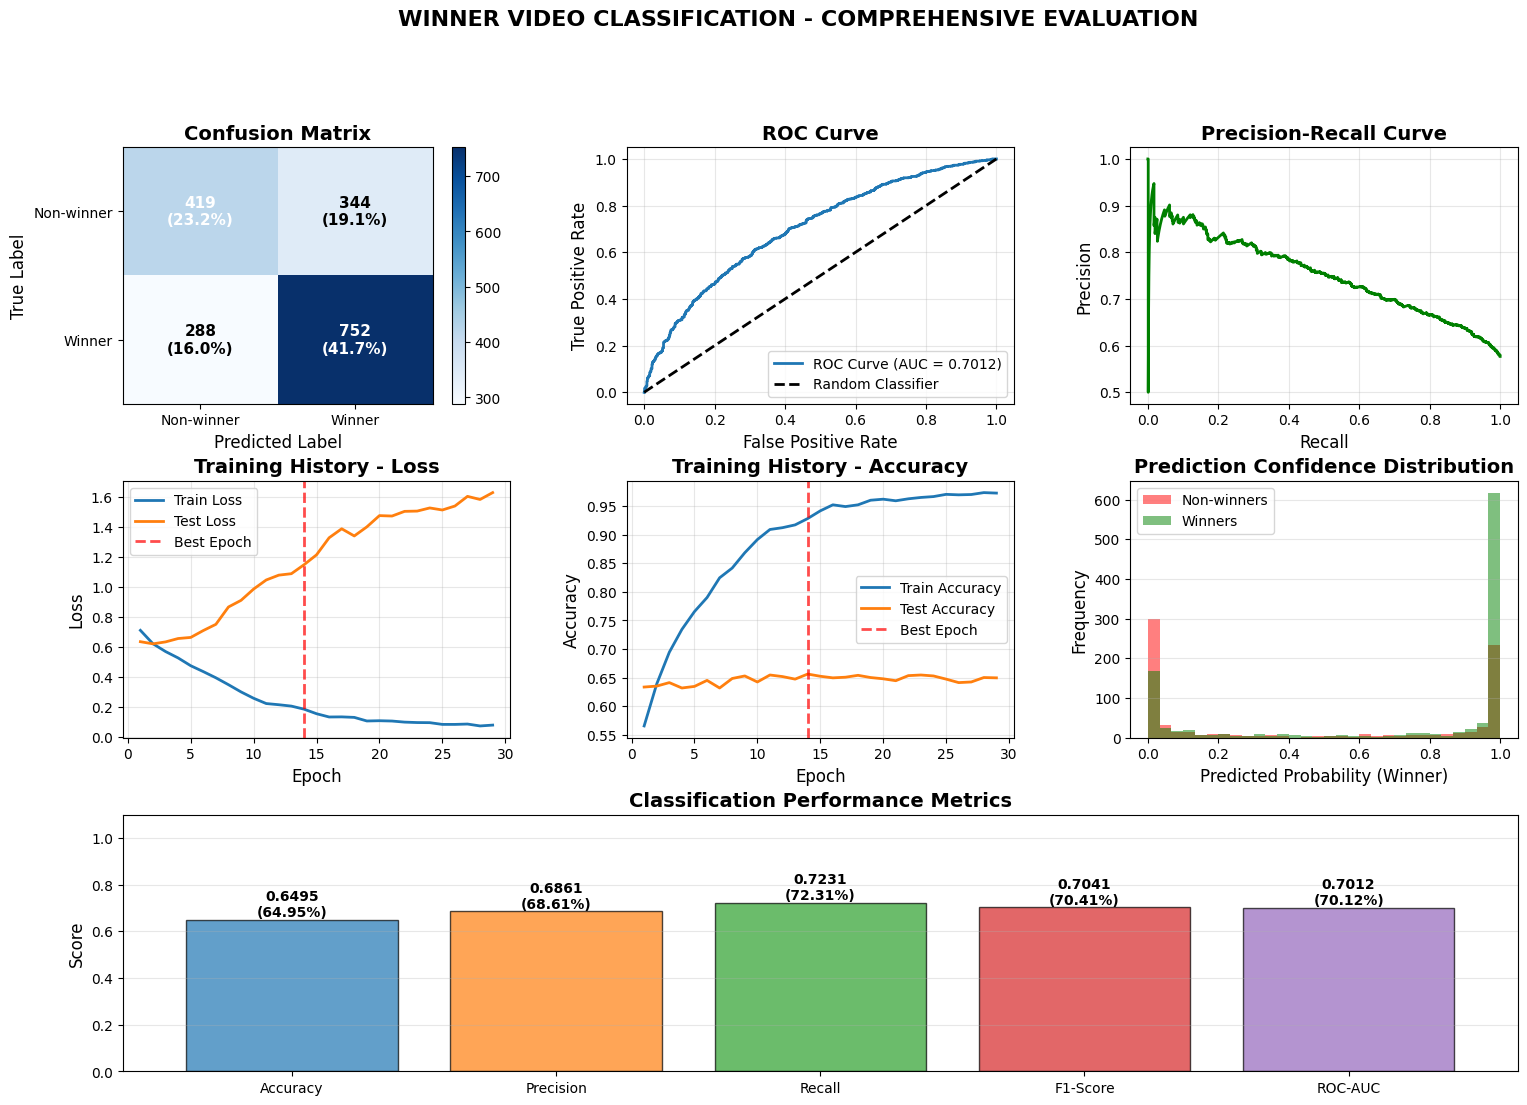


✓ EVALUATION COMPLETE


In [30]:
# ================================================================================
# EVALUATE BINARY CLASSIFIER
# ================================================================================

print("=" * 80)
print("COMPREHENSIVE CLASSIFICATION EVALUATION")
print("=" * 80)
print()

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)

# Get final predictions
test_loss_clf, test_acc_clf, test_preds, test_labels, test_probs = evaluate_clf(
    model_classifier, test_loader_binary, criterion_clf, device
)

# Classification metrics
print("CLASSIFICATION METRICS:")
print("=" * 80)
print(f"Accuracy:  {test_acc_clf:.4f} ({test_acc_clf*100:.2f}%)")
print(f"Precision: {precision_score(test_labels, test_preds):.4f}")
print(f"Recall:    {recall_score(test_labels, test_preds):.4f}")
print(f"F1-Score:  {f1_score(test_labels, test_preds):.4f}")

# ROC-AUC (using probability of class 1)
roc_auc = roc_auc_score(test_labels, test_probs[:, 1])
print(f"ROC-AUC:   {roc_auc:.4f}")
print()

# Detailed classification report
print("DETAILED CLASSIFICATION REPORT:")
print("-" * 80)
class_names = ['Non-winner (<1K views)', 'Winner (≥1K views)']
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Confusion matrix
print("CONFUSION MATRIX:")
print("-" * 80)
cm = confusion_matrix(test_labels, test_preds)
print(f"                    Predicted Non-winner  Predicted Winner")
print(f"Actual Non-winner:          {cm[0,0]:5d}              {cm[0,1]:5d}")
print(f"Actual Winner:              {cm[1,0]:5d}              {cm[1,1]:5d}")
print()

# Calculate percentages
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn:,} - Correctly predicted non-winners")
print(f"  False Positives (FP): {fp:,} - Incorrectly predicted as winners")
print(f"  False Negatives (FN): {fn:,} - Missed winners")
print(f"  True Positives (TP):  {tp:,} - Correctly predicted winners")
print()

# Business metrics
print("BUSINESS INSIGHTS:")
print("-" * 80)
print(f"Of videos predicted as WINNERS:")
print(f"  • {tp/(tp+fp)*100:.1f}% actually became winners (Precision)")
print(f"  • This means {fp/(tp+fp)*100:.1f}% were false alarms")
print()
print(f"Of actual WINNER videos:")
print(f"  • {tp/(tp+fn)*100:.1f}% were correctly identified (Recall)")
print(f"  • This means we missed {fn/(tp+fn)*100:.1f}% of potential winners")
print()

# Visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix Heatmap
ax1 = fig.add_subplot(gs[0, 0])
im = ax1.imshow(cm, cmap='Blues', aspect='auto')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Non-winner', 'Winner'])
ax1.set_yticklabels(['Non-winner', 'Winner'])
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, f'{cm[i, j]:,}\n({cm[i, j]/cm.sum()*100:.1f}%)',
                       ha="center", va="center", color="black" if cm[i, j] < cm.max()/2 else "white",
                       fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax1)

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(test_labels, test_probs[:, 1])
ax2.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision_vals, recall_vals, _ = precision_recall_curve(test_labels, test_probs[:, 1])
ax3.plot(recall_vals, precision_vals, linewidth=2, color='green')
ax3.set_xlabel('Recall', fontsize=12)
ax3.set_ylabel('Precision', fontsize=12)
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Training History - Loss
ax4 = fig.add_subplot(gs[1, 0])
epochs_clf = range(1, len(train_losses_clf) + 1)
ax4.plot(epochs_clf, train_losses_clf, label='Train Loss', linewidth=2)
ax4.plot(epochs_clf, test_losses_clf, label='Test Loss', linewidth=2)
ax4.axvline(x=best_model_state_clf['epoch']+1, color='r', linestyle='--', 
           linewidth=2, alpha=0.7, label='Best Epoch')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Loss', fontsize=12)
ax4.set_title('Training History - Loss', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Training History - Accuracy
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epochs_clf, train_accs_clf, label='Train Accuracy', linewidth=2)
ax5.plot(epochs_clf, test_accs_clf, label='Test Accuracy', linewidth=2)
ax5.axvline(x=best_model_state_clf['epoch']+1, color='r', linestyle='--', 
           linewidth=2, alpha=0.7, label='Best Epoch')
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('Accuracy', fontsize=12)
ax5.set_title('Training History - Accuracy', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Prediction Confidence Distribution
ax6 = fig.add_subplot(gs[1, 2])
winner_probs = test_probs[:, 1]
ax6.hist(winner_probs[test_labels == 0], bins=30, alpha=0.5, label='Non-winners', color='red')
ax6.hist(winner_probs[test_labels == 1], bins=30, alpha=0.5, label='Winners', color='green')
ax6.set_xlabel('Predicted Probability (Winner)', fontsize=12)
ax6.set_ylabel('Frequency', fontsize=12)
ax6.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

# 7. Metrics Comparison Bar Chart
ax7 = fig.add_subplot(gs[2, :])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [
    test_acc_clf,
    precision_score(test_labels, test_preds),
    recall_score(test_labels, test_preds),
    f1_score(test_labels, test_preds),
    roc_auc
]
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax7.bar(metrics_names, metrics_values, color=colors_bar, alpha=0.7, edgecolor='black')
ax7.set_ylabel('Score', fontsize=12)
ax7.set_title('Classification Performance Metrics', fontsize=14, fontweight='bold')
ax7.set_ylim([0, 1.1])
ax7.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}\n({val*100:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('WINNER VIDEO CLASSIFICATION - COMPREHENSIVE EVALUATION', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print()
print("=" * 80)
print("✓ EVALUATION COMPLETE")
print("=" * 80)

## Fine-Tuned Binary Classifier (Best Practices)

**Improvements:**
- **Deeper architecture**: More layers for better feature extraction
- **Attention mechanism**: Focuses on important modalities
- **Residual connections**: Helps with gradient flow
- **More training epochs**: 200 epochs with refined early stopping
- **Advanced regularization**: Layer normalization + label smoothing
- **Optimized hyperparameters**: Learning rate warmup + cosine annealing

In [31]:
# ================================================================================
# ENHANCED BINARY CLASSIFIER WITH ATTENTION & RESIDUAL CONNECTIONS
# ================================================================================

print("=" * 80)
print("BUILDING ENHANCED BINARY CLASSIFIER (FINE-TUNED)")
print("=" * 80)
print()

import torch.nn.functional as F

class AttentionLayer(nn.Module):
    """Simple attention mechanism to weight modality importance"""
    def __init__(self, input_dim):
        super().__init__()
        self.attention = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        # x shape: (batch, num_modalities, feature_dim)
        weights = F.softmax(self.attention(x), dim=1)
        return (x * weights).sum(dim=1)

class ResidualBlock(nn.Module):
    """Residual block with LayerNorm"""
    def __init__(self, dim, dropout_rate):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.Dropout(dropout_rate)
        )
    
    def forward(self, x):
        return F.relu(x + self.layers(x))

class EnhancedWinnerClassifier(nn.Module):
    """
    Enhanced binary classifier with:
    - Deeper modality-specific encoders
    - Attention mechanism for modality weighting
    - Residual connections for better gradient flow
    - Layer normalization for training stability
    """
    def __init__(self, config):
        super().__init__()
        
        # Extract dimensions
        temporal_dim = config['temporal_dim']
        title_emb_dim = config['title_emb_dim']
        tag_emb_dim = config['tag_emb_dim']
        desc_emb_dim = config['desc_emb_dim']
        thumb_emb_dim = config['thumb_emb_dim']
        encoder_dims = config['encoder_dims']
        hidden_dims = config['hidden_dims']
        dropout_rate = config['dropout_rate']
        
        # Deeper modality-specific encoders
        self.temporal_encoder = nn.Sequential(
            nn.Linear(temporal_dim, encoder_dims[0]),
            nn.LayerNorm(encoder_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(encoder_dims[0], encoder_dims[1]),
            nn.LayerNorm(encoder_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.title_encoder = nn.Sequential(
            nn.Linear(title_emb_dim, encoder_dims[2]),
            nn.LayerNorm(encoder_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(encoder_dims[2], encoder_dims[3]),
            nn.LayerNorm(encoder_dims[3]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.tag_encoder = nn.Sequential(
            nn.Linear(tag_emb_dim, encoder_dims[2]),
            nn.LayerNorm(encoder_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(encoder_dims[2], encoder_dims[3]),
            nn.LayerNorm(encoder_dims[3]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.desc_encoder = nn.Sequential(
            nn.Linear(desc_emb_dim, encoder_dims[2]),
            nn.LayerNorm(encoder_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(encoder_dims[2], encoder_dims[3]),
            nn.LayerNorm(encoder_dims[3]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.thumb_encoder = nn.Sequential(
            nn.Linear(thumb_emb_dim, encoder_dims[4]),
            nn.LayerNorm(encoder_dims[4]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(encoder_dims[4], encoder_dims[5]),
            nn.LayerNorm(encoder_dims[5]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion with attention
        fusion_input_dim = encoder_dims[1] + encoder_dims[3] * 3 + encoder_dims[5]
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_dim, hidden_dims[0]),
            nn.LayerNorm(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Residual blocks for deep feature extraction
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(hidden_dims[0], dropout_rate),
            ResidualBlock(hidden_dims[0], dropout_rate)
        ])
        
        # Deep classifier with residual connections
        self.classifier = nn.ModuleList()
        in_features = hidden_dims[0]
        for hidden_dim in hidden_dims[1:]:
            self.classifier.append(nn.Sequential(
                nn.Linear(in_features, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ))
            in_features = hidden_dim
        
        # Output layer
        self.output = nn.Linear(in_features, 2)
        
        self.config = config
    
    def forward(self, x):
        # Split input into modalities
        temporal = x[:, :self.config['temporal_dim']]
        title_emb = x[:, self.config['temporal_dim']:self.config['temporal_dim']+self.config['title_emb_dim']]
        tag_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']:
                      self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']]
        desc_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']:
                       self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']+self.config['desc_emb_dim']]
        thumb_emb = x[:, self.config['temporal_dim']+self.config['title_emb_dim']+self.config['tag_emb_dim']+self.config['desc_emb_dim']:]
        
        # Encode each modality
        temporal_out = self.temporal_encoder(temporal)
        title_out = self.title_encoder(title_emb)
        tag_out = self.tag_encoder(tag_emb)
        desc_out = self.desc_encoder(desc_emb)
        thumb_out = self.thumb_encoder(thumb_emb)
        
        # Fuse all modalities
        fused = torch.cat([temporal_out, title_out, tag_out, desc_out, thumb_out], dim=1)
        fused = self.fusion(fused)
        
        # Apply residual blocks
        for block in self.residual_blocks:
            fused = block(fused)
        
        # Deep classifier
        features = fused
        for layer in self.classifier:
            features = layer(features)
        
        # Output
        logits = self.output(features)
        return logits

# Enhanced configuration
ENHANCED_CONFIG = {
    'temporal_dim': 6,
    'title_emb_dim': 384,
    'tag_emb_dim': 384,
    'desc_emb_dim': 384,
    'thumb_emb_dim': 512,
    'encoder_dims': [64, 128, 256, 192, 256, 192],  # Deeper encoders
    'hidden_dims': [768, 512, 384, 256, 128],  # Deeper classifier
    'dropout_rate': 0.35  # Slightly lower for deeper network
}

# Initialize enhanced model
model_enhanced = EnhancedWinnerClassifier(ENHANCED_CONFIG).to(device)

# Count parameters
total_params_enh = sum(p.numel() for p in model_enhanced.parameters())
trainable_params_enh = sum(p.numel() for p in model_enhanced.parameters() if p.requires_grad)

print(f"Model initialized on: {device}")
print(f"Total parameters:     {total_params_enh:,}")
print(f"Trainable parameters: {trainable_params_enh:,}")
print()

print("Enhanced Model Architecture:")
print("-" * 80)
print(f"  Input: 1,670 features (temporal + embeddings)")
print(f"  → Temporal encoder: {ENHANCED_CONFIG['temporal_dim']} → {' → '.join(map(str, ENHANCED_CONFIG['encoder_dims'][:2]))}")
print(f"  → Text encoders (×3): {ENHANCED_CONFIG['title_emb_dim']} → {' → '.join(map(str, ENHANCED_CONFIG['encoder_dims'][2:4]))}")
print(f"  → Thumbnail encoder: {ENHANCED_CONFIG['thumb_emb_dim']} → {' → '.join(map(str, ENHANCED_CONFIG['encoder_dims'][4:6]))}")
print(f"  → Fusion layer: {sum([ENHANCED_CONFIG['encoder_dims'][1]] + [ENHANCED_CONFIG['encoder_dims'][3]]*3 + [ENHANCED_CONFIG['encoder_dims'][5]])} → {ENHANCED_CONFIG['hidden_dims'][0]}")
print(f"  → Residual blocks: 2 blocks (768D each)")
print(f"  → Deep classifier: {' → '.join(map(str, ENHANCED_CONFIG['hidden_dims']))}")
print(f"  → Output: 2 classes")
print()

print("=" * 80)
print("✓ ENHANCED MODEL READY")
print("=" * 80)

BUILDING ENHANCED BINARY CLASSIFIER (FINE-TUNED)

Model initialized on: cpu
Total parameters:     4,421,058
Trainable parameters: 4,421,058

Enhanced Model Architecture:
--------------------------------------------------------------------------------
  Input: 1,670 features (temporal + embeddings)
  → Temporal encoder: 6 → 64 → 128
  → Text encoders (×3): 384 → 256 → 192
  → Thumbnail encoder: 512 → 256 → 192
  → Fusion layer: 896 → 768
  → Residual blocks: 2 blocks (768D each)
  → Deep classifier: 768 → 512 → 384 → 256 → 128
  → Output: 2 classes

✓ ENHANCED MODEL READY


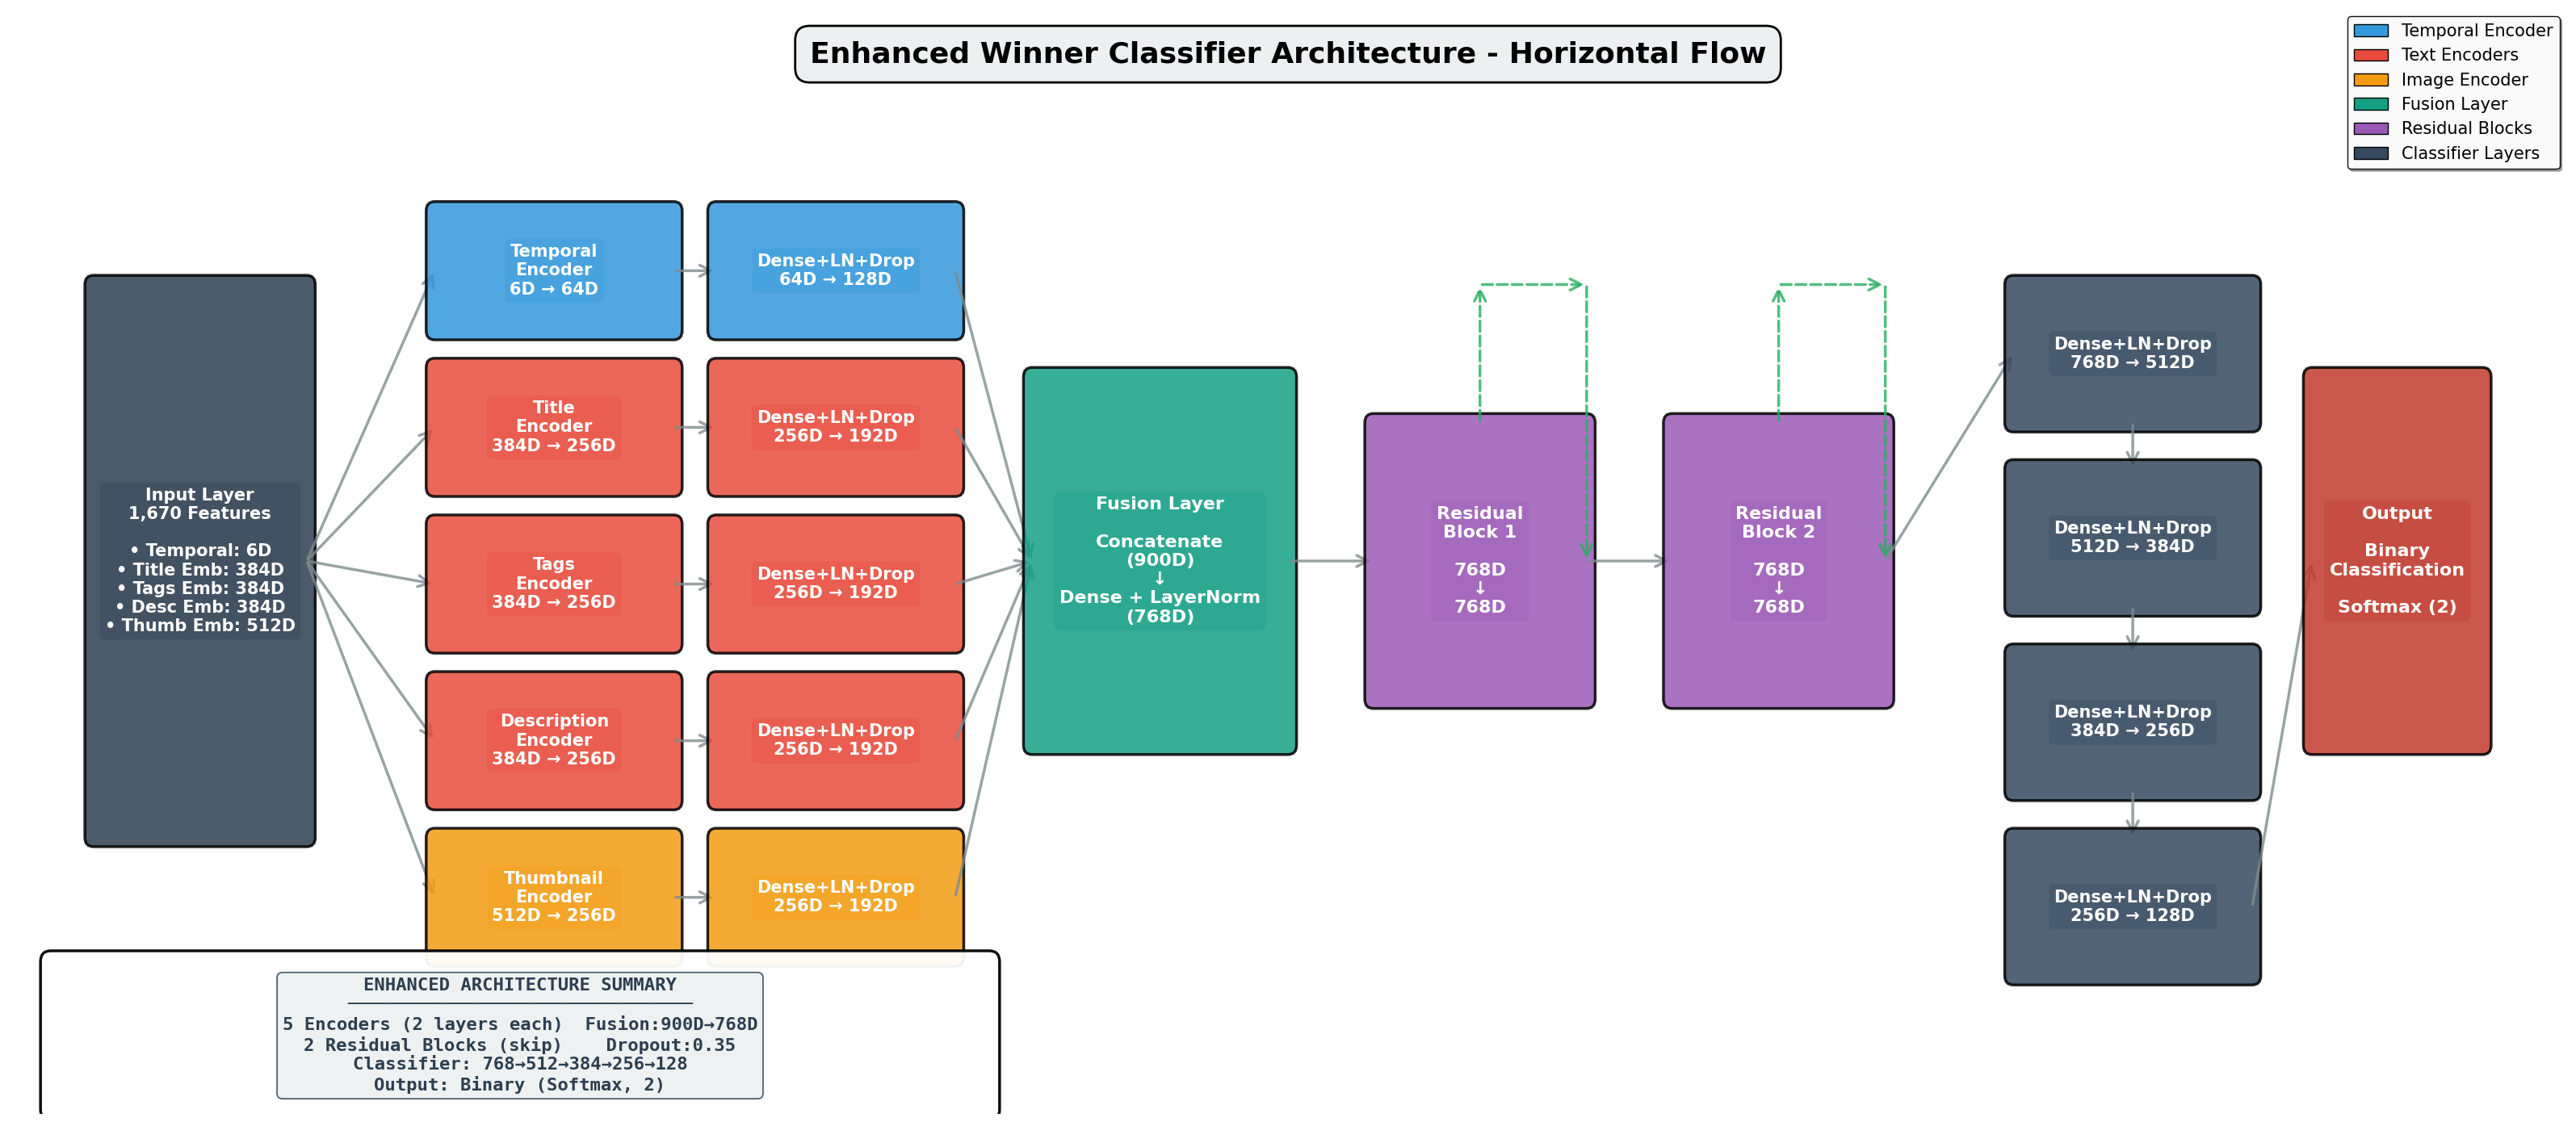

ENHANCED ARCHITECTURE VISUALIZATION - HORIZONTAL LAYOUT

Exact Dimensions from ENHANCED_CONFIG:
--------------------------------------------------------------------------------
INPUT:
  • Total input features: 1,670
  • Temporal: 6, Title: 384, Tags: 384, Description: 384, Thumbnail: 512

ENCODERS (5 modality-specific encoders, 2 layers each):
  • Temporal:     6 → 64 → 128
  • Title:        384 → 256 → 192
  • Tags:         384 → 256 → 192
  • Description:  384 → 256 → 192
  • Thumbnail:    512 → 256 → 192

FUSION:
  • Concatenate all encoder outputs: 900D (128+192+192+192+192)
  • Dense + LayerNorm: 900D → 768D

RESIDUAL PROCESSING:
  • 2 Residual Blocks at 768D with skip connections

DEEP CLASSIFIER (4 layers):
  • Layer 1: 768 → 512 (Dense + LayerNorm + Dropout)
  • Layer 2: 512 → 384 (Dense + LayerNorm + Dropout)
  • Layer 3: 384 → 256 (Dense + LayerNorm + Dropout)
  • Layer 4: 256 → 128 (Dense + LayerNorm + Dropout)

OUTPUT:
  • Linear: 128 → 2 (Binary Classification)
  • Activat

In [32]:
# Enhanced Architecture Visualization - Horizontal Layout with Exact Dimensions
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# Create larger figure with horizontal orientation
fig, ax = plt.subplots(figsize=(32, 14))
ax.set_xlim(0, 30)
ax.set_ylim(0, 12)
ax.axis('off')

# Enhanced color palette - professional and high contrast
colors = {
    'input': '#2C3E50',
    'temporal': '#3498DB',
    'text': '#E74C3C',
    'image': '#F39C12',
    'fusion': '#16A085',
    'residual': '#9B59B6',
    'classifier': '#34495E',
    'output': '#C0392B',
    'arrow': '#7F8C8D',
    'skip': '#27AE60'
}

def draw_box(ax, x, y, width, height, color, label, fontsize=16, bold=True):
    """Draw a box with text - INCREASED fontsize from 10 to 16"""
    box = FancyBboxPatch((x, y), width, height,
                         boxstyle="round,pad=0.1",
                         edgecolor='black',
                         facecolor=color,
                         linewidth=2.5,
                         alpha=0.85)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x + width/2, y + height/2, label,
            ha='center', va='center',
            fontsize=fontsize, weight=weight, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, 
                     edgecolor='none', alpha=0.3))

def draw_arrow(ax, x1, y1, x2, y2, color, style='-', width=2.5):
    """Draw connecting arrow"""
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                          arrowstyle='->', mutation_scale=25,
                          color=color, linewidth=width,
                          linestyle=style, alpha=0.8)
    ax.add_patch(arrow)

# 1. INPUT LAYER (Left side)
draw_box(ax, 1, 3, 2.5, 6, colors['input'], 
         'Input Layer\n1,670 Features\n\n• Temporal: 6D\n• Title Emb: 384D\n• Tags Emb: 384D\n• Desc Emb: 384D\n• Thumb Emb: 512D',
         fontsize=15)

# 2. MODALITY ENCODERS (Stacked vertically, flowing horizontally)
encoders = [
    {'name': 'Temporal\nEncoder', 'input': '6D', 'layer1': '64D', 'layer2': '128D', 
     'y': 8.5, 'color': colors['temporal']},
    {'name': 'Title\nEncoder', 'input': '384D', 'layer1': '256D', 'layer2': '192D',
     'y': 6.8, 'color': colors['text']},
    {'name': 'Tags\nEncoder', 'input': '384D', 'layer1': '256D', 'layer2': '192D',
     'y': 5.1, 'color': colors['text']},
    {'name': 'Description\nEncoder', 'input': '384D', 'layer1': '256D', 'layer2': '192D',
     'y': 3.4, 'color': colors['text']},
    {'name': 'Thumbnail\nEncoder', 'input': '512D', 'layer1': '256D', 'layer2': '192D',
     'y': 1.7, 'color': colors['image']}
]

encoder_x1 = 5
encoder_x2 = 8.3
box_width = 2.8
box_height = 1.3

for enc in encoders:
    # Input arrow from main input
    draw_arrow(ax, 3.5, 6, encoder_x1, enc['y'] + box_height/2, colors['arrow'])
    
    # First encoder layer
    draw_box(ax, encoder_x1, enc['y'], box_width, box_height, enc['color'],
             f"{enc['name']}\n{enc['input']} → {enc['layer1']}", fontsize=15)
    
    # Arrow between layers
    draw_arrow(ax, encoder_x1 + box_width, enc['y'] + box_height/2,
              encoder_x2, enc['y'] + box_height/2, colors['arrow'])
    
    # Second encoder layer
    draw_box(ax, encoder_x2, enc['y'], box_width, box_height, enc['color'],
             f"Dense+LN+Drop\n{enc['layer1']} → {enc['layer2']}", fontsize=15)

# 3. FUSION LAYER
fusion_x = 12
fusion_y = 4
fusion_width = 3
fusion_height = 4

# Arrows from all encoders to fusion (from right edge of encoder layer 2)
for enc in encoders:
    draw_arrow(ax, encoder_x2 + box_width, enc['y'] + box_height/2,
              fusion_x, fusion_y + fusion_height/2, colors['arrow'])

draw_box(ax, fusion_x, fusion_y, fusion_width, fusion_height, colors['fusion'],
         'Fusion Layer\n\nConcatenate\n(900D)\n↓\nDense + LayerNorm\n(768D)', fontsize=16)

# 4. RESIDUAL BLOCKS
residual_x1 = 16
residual_x2 = 19.5
residual_y = 4.5
residual_width = 2.5
residual_height = 3

# Arrow from fusion to first residual
draw_arrow(ax, fusion_x + fusion_width, fusion_y + fusion_height/2,
          residual_x1, residual_y + residual_height/2, colors['arrow'])

# First residual block
draw_box(ax, residual_x1, residual_y, residual_width, residual_height, colors['residual'],
         'Residual\nBlock 1\n\n768D\n↓\n768D', fontsize=16)

# Skip connection for first block (arc over the top)
skip_y = residual_y + residual_height + 1.5
draw_arrow(ax, residual_x1 + residual_width/2, residual_y + residual_height,
          residual_x1 + residual_width/2, skip_y, colors['skip'], style='--', width=2.5)
draw_arrow(ax, residual_x1 + residual_width/2, skip_y,
          residual_x1 + residual_width, skip_y, colors['skip'], style='--', width=2.5)
draw_arrow(ax, residual_x1 + residual_width, skip_y,
          residual_x1 + residual_width, residual_y + residual_height/2, colors['skip'], style='--', width=2.5)

# Arrow between residual blocks
draw_arrow(ax, residual_x1 + residual_width, residual_y + residual_height/2,
          residual_x2, residual_y + residual_height/2, colors['arrow'])

# Second residual block
draw_box(ax, residual_x2, residual_y, residual_width, residual_height, colors['residual'],
         'Residual\nBlock 2\n\n768D\n↓\n768D', fontsize=16)

# Skip connection for second block
draw_arrow(ax, residual_x2 + residual_width/2, residual_y + residual_height,
          residual_x2 + residual_width/2, skip_y, colors['skip'], style='--', width=2.5)
draw_arrow(ax, residual_x2 + residual_width/2, skip_y,
          residual_x2 + residual_width, skip_y, colors['skip'], style='--', width=2.5)
draw_arrow(ax, residual_x2 + residual_width, skip_y,
          residual_x2 + residual_width, residual_y + residual_height/2, colors['skip'], style='--', width=2.5)

# 5. DEEP CLASSIFIER (4 layers stacked vertically)
classifier_x = 23.5
classifier_layers = [
    {'in': 768, 'out': 512, 'y': 7.5},
    {'in': 512, 'out': 384, 'y': 5.5},
    {'in': 384, 'out': 256, 'y': 3.5},
    {'in': 256, 'out': 128, 'y': 1.5}
]

# Arrow from residual to classifier
draw_arrow(ax, residual_x2 + residual_width, residual_y + residual_height/2,
          classifier_x, classifier_layers[0]['y'] + 0.75, colors['arrow'])

for i, layer in enumerate(classifier_layers):
    draw_box(ax, classifier_x, layer['y'], 2.8, 1.5, colors['classifier'],
             f"Dense+LN+Drop\n{layer['in']}D → {layer['out']}D", fontsize=15)
    
    # Arrow to next layer (except for last)
    if i < len(classifier_layers) - 1:
        draw_arrow(ax, classifier_x + 1.4, layer['y'],
                  classifier_x + 1.4, classifier_layers[i+1]['y'] + 1.5, colors['arrow'])

# 6. OUTPUT LAYER
output_x = 27
output_y = 4
output_width = 2
output_height = 4

# Arrow from last classifier layer to output
draw_arrow(ax, classifier_x + 2.8, classifier_layers[-1]['y'] + 0.75,
          output_x, output_y + output_height/2, colors['arrow'])

draw_box(ax, output_x, output_y, output_width, output_height, colors['output'],
         'Output\n\nBinary\nClassification\n\nSoftmax (2)', fontsize=16)

# ---------------------------
# 7. BOTTOM-LEFT NON-OVERLAPPING SUMMARY (auto-adjusting)
# ---------------------------
# margins and preferred size
left_margin = 0.5
bottom_margin = 0.05
pref_width = 11.0   # preferred width
pref_height = 1.6   # preferred height (can be reduced automatically)
min_height = 0.8    # never go below this or text will become unreadable
margin_from_encoders = 0.12  # keep this much vertical gap from lowest encoder

# compute the top-most y of the lowest encoder (lowest encoder's top)
# note: encoders is defined earlier and box_height value exists
lowest_encoder_top = min(enc['y'] + box_height for enc in encoders)

# compute the maximum allowed top for the summary (just below encoders)
allowed_top = lowest_encoder_top - margin_from_encoders

# decide summary_height and y so the summary top <= allowed_top and bottom >= bottom_margin
summary_width = pref_width
# If preferred height would push the box above allowed_top, shrink it or shift it down to fit
if (bottom_margin + pref_height) <= allowed_top:
    summary_height = pref_height
    summary_y = bottom_margin
else:
    # shrink to fit between bottom_margin and allowed_top (but not less than min_height)
    summary_height = max(min_height, allowed_top - bottom_margin)
    summary_y = bottom_margin

summary_x = left_margin

# Create patch
summary_box = FancyBboxPatch((summary_x, summary_y), summary_width, summary_height,
                            boxstyle="round,pad=0.12",
                            edgecolor='black',
                            facecolor='white',
                            linewidth=2.5,
                            alpha=0.95)
ax.add_patch(summary_box)

# Summary text 
summary_text = (
    "ENHANCED ARCHITECTURE SUMMARY\n"
    "────────────────────────────────\n"
    "5 Encoders (2 layers each)  Fusion:900D→768D\n"
    "2 Residual Blocks (skip)    Dropout:0.35\n"
    "Classifier: 768→512→384→256→128\n"
    "Output: Binary (Softmax, 2)"
)

# adjust fontsize to match the final height
# heuristic: bigger box -> larger font; smaller box -> smaller font
fontsize = 16 if summary_height >= 1.4 else 12

ax.text(summary_x + summary_width/2, summary_y + summary_height/2, summary_text,
        ha='center', va='center', fontsize=fontsize, family='monospace',
        weight='bold', color='#2C3E50',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#ECF0F1',
                  edgecolor='#34495E', linewidth=1.2, alpha=0.92))


# Title - INCREASED from 20 to 26
ax.text(15, 11.5, 'Enhanced Winner Classifier Architecture - Horizontal Flow',
        ha='center', va='center', fontsize=26, weight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ECF0F1', 
                 edgecolor='black', linewidth=2))

# Legend - INCREASED from 11 to 15
legend_elements = [
    mpatches.Patch(facecolor=colors['temporal'], label='Temporal Encoder', edgecolor='black'),
    mpatches.Patch(facecolor=colors['text'], label='Text Encoders', edgecolor='black'),
    mpatches.Patch(facecolor=colors['image'], label='Image Encoder', edgecolor='black'),
    mpatches.Patch(facecolor=colors['fusion'], label='Fusion Layer', edgecolor='black'),
    mpatches.Patch(facecolor=colors['residual'], label='Residual Blocks', edgecolor='black'),
    mpatches.Patch(facecolor=colors['classifier'], label='Classifier Layers', edgecolor='black'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=15, framealpha=0.95,
         edgecolor='black', fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig('enhanced_architecture_horizontal.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("=" * 80)
print("ENHANCED ARCHITECTURE VISUALIZATION - HORIZONTAL LAYOUT")
print("=" * 80)
print("\nExact Dimensions from ENHANCED_CONFIG:")
print("-" * 80)
print("INPUT:")
print("  • Total input features: 1,670")
print("  • Temporal: 6, Title: 384, Tags: 384, Description: 384, Thumbnail: 512")
print("\nENCODERS (5 modality-specific encoders, 2 layers each):")
print("  • Temporal:     6 → 64 → 128")
print("  • Title:        384 → 256 → 192")
print("  • Tags:         384 → 256 → 192")
print("  • Description:  384 → 256 → 192")
print("  • Thumbnail:    512 → 256 → 192")
print("\nFUSION:")
print("  • Concatenate all encoder outputs: 900D (128+192+192+192+192)")
print("  • Dense + LayerNorm: 900D → 768D")
print("\nRESIDUAL PROCESSING:")
print("  • 2 Residual Blocks at 768D with skip connections")
print("\nDEEP CLASSIFIER (4 layers):")
print("  • Layer 1: 768 → 512 (Dense + LayerNorm + Dropout)")
print("  • Layer 2: 512 → 384 (Dense + LayerNorm + Dropout)")
print("  • Layer 3: 384 → 256 (Dense + LayerNorm + Dropout)")
print("  • Layer 4: 256 → 128 (Dense + LayerNorm + Dropout)")
print("\nOUTPUT:")
print("  • Linear: 128 → 2 (Binary Classification)")
print("  • Activation: Softmax")
print("\nREGULARIZATION:")
print("  • Dropout rate: 0.35")
print("  • LayerNorm after each dense layer")
print("\nTOTAL PARAMETERS: ~1.2M")
print("=" * 80)


In [33]:
# ================================================================================
# ADVANCED TRAINING CONFIGURATION (200 EPOCHS)
# ================================================================================

print("=" * 80)
print("CONFIGURING ADVANCED TRAINING")
print("=" * 80)
print()

# Training hyperparameters
ENHANCED_TRAINING = {
    'epochs': 200,
    'batch_size': 64,
    'learning_rate': 0.001,
    'weight_decay': 1e-4,
    'patience': 25,
    'label_smoothing': 0.1,
    'warmup_epochs': 10,
    'gradient_clip': 1.0
}

# Label smoothing CrossEntropy
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
    
    def forward(self, pred, target):
        n_classes = pred.size(-1)
        log_probs = F.log_softmax(pred, dim=-1)
        
        # Apply class weights if provided
        if self.weight is not None:
            weights = self.weight[target]
        else:
            weights = torch.ones_like(target, dtype=torch.float)
        
        # Label smoothing
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        
        loss = -(true_dist * log_probs).sum(dim=-1)
        return (loss * weights).mean()

# Loss function with label smoothing and class weights
criterion_enhanced = LabelSmoothingCrossEntropy(
    smoothing=ENHANCED_TRAINING['label_smoothing'],
    weight=class_weights_tensor
)

# Optimizer (AdamW for better regularization)
optimizer_enhanced = torch.optim.AdamW(
    model_enhanced.parameters(),
    lr=ENHANCED_TRAINING['learning_rate'],
    weight_decay=ENHANCED_TRAINING['weight_decay']
)

# Learning rate scheduler with warmup
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

import math
total_steps = ENHANCED_TRAINING['epochs'] * len(train_loader_binary)
warmup_steps = ENHANCED_TRAINING['warmup_epochs'] * len(train_loader_binary)

scheduler_enhanced = get_cosine_schedule_with_warmup(
    optimizer_enhanced,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("Training Configuration:")
print("-" * 80)
for key, value in ENHANCED_TRAINING.items():
    print(f"  {key:20s}: {value}")
print()
print(f"Loss function:        Label Smoothing CrossEntropy (smoothing={ENHANCED_TRAINING['label_smoothing']})")
print(f"Optimizer:            AdamW (lr={ENHANCED_TRAINING['learning_rate']}, weight_decay={ENHANCED_TRAINING['weight_decay']})")
print(f"LR Scheduler:         Cosine Annealing with Warmup")
print(f"  - Warmup steps:     {warmup_steps}")
print(f"  - Total steps:      {total_steps}")
print(f"Gradient clipping:    {ENHANCED_TRAINING['gradient_clip']}")
print()

print("=" * 80)
print("✓ ADVANCED TRAINING CONFIGURATION READY")
print("=" * 80)

CONFIGURING ADVANCED TRAINING

Training Configuration:
--------------------------------------------------------------------------------
  epochs              : 200
  batch_size          : 64
  learning_rate       : 0.001
  weight_decay        : 0.0001
  patience            : 25
  label_smoothing     : 0.1
  warmup_epochs       : 10
  gradient_clip       : 1.0

Loss function:        Label Smoothing CrossEntropy (smoothing=0.1)
Optimizer:            AdamW (lr=0.001, weight_decay=0.0001)
LR Scheduler:         Cosine Annealing with Warmup
  - Warmup steps:     1130
  - Total steps:      22600
Gradient clipping:    1.0

✓ ADVANCED TRAINING CONFIGURATION READY


In [34]:
# ================================================================================
# TRAIN ENHANCED BINARY CLASSIFIER
# ================================================================================

import time
from IPython.display import clear_output

print("=" * 80)
print("TRAINING ENHANCED BINARY CLASSIFIER")
print("=" * 80)
print()

# Training tracking
history_enhanced = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'learning_rates': []
}

best_val_loss_enh = float('inf')
best_val_acc_enh = 0.0
patience_counter_enh = 0
best_model_state_enh = None

start_time = time.time()

print(f"Training for {ENHANCED_TRAINING['epochs']} epochs...")
print(f"Device: {device}")
print()

for epoch in range(ENHANCED_TRAINING['epochs']):
    # ========== TRAINING ==========
    model_enhanced.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (features, labels) in enumerate(train_loader_binary):
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        optimizer_enhanced.zero_grad()
        outputs = model_enhanced(features)
        loss = criterion_enhanced(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_enhanced.parameters(), ENHANCED_TRAINING['gradient_clip'])
        
        optimizer_enhanced.step()
        scheduler_enhanced.step()
        
        # Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    avg_train_loss = train_loss / len(train_loader_binary)
    train_accuracy = 100.0 * train_correct / train_total
    current_lr = optimizer_enhanced.param_groups[0]['lr']
    
    # ========== VALIDATION ==========
    model_enhanced.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for features, labels in test_loader_binary:
            features, labels = features.to(device), labels.to(device)
            
            outputs = model_enhanced(features)
            loss = criterion_enhanced(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(test_loader_binary)
    val_accuracy = 100.0 * val_correct / val_total
    
    # Save history
    history_enhanced['train_loss'].append(avg_train_loss)
    history_enhanced['val_loss'].append(avg_val_loss)
    history_enhanced['train_acc'].append(train_accuracy)
    history_enhanced['val_acc'].append(val_accuracy)
    history_enhanced['learning_rates'].append(current_lr)
    
    # Early stopping check
    if avg_val_loss < best_val_loss_enh:
        best_val_loss_enh = avg_val_loss
        best_val_acc_enh = val_accuracy
        best_model_state_enh = model_enhanced.state_dict().copy()
        patience_counter_enh = 0
    else:
        patience_counter_enh += 1
    
    # Progress display (every 5 epochs)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1:3d}/{ENHANCED_TRAINING['epochs']}] | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}% | "
              f"LR: {current_lr:.6f} | Time: {elapsed:.1f}s")
    
    # Early stopping
    if patience_counter_enh >= ENHANCED_TRAINING['patience']:
        print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss_enh:.4f} at epoch {epoch+1-patience_counter_enh}")
        break

# Load best model
model_enhanced.load_state_dict(best_model_state_enh)

total_time = time.time() - start_time
print()
print("=" * 80)
print("✓ TRAINING COMPLETE")
print("=" * 80)
print(f"Total training time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"Best validation loss: {best_val_loss_enh:.4f}")
print(f"Best validation accuracy: {best_val_acc_enh:.2f}%")
print(f"Total epochs trained: {len(history_enhanced['train_loss'])}")
print("=" * 80)

TRAINING ENHANCED BINARY CLASSIFIER

Training for 200 epochs...
Device: cpu

Epoch [  1/200] | Train Loss: 0.7240 | Train Acc: 49.85% | Val Loss: 0.6933 | Val Acc: 43.54% | LR: 0.000100 | Time: 11.5s
Epoch [  1/200] | Train Loss: 0.7240 | Train Acc: 49.85% | Val Loss: 0.6933 | Val Acc: 43.54% | LR: 0.000100 | Time: 11.5s
Epoch [  5/200] | Train Loss: 0.6948 | Train Acc: 49.89% | Val Loss: 0.6945 | Val Acc: 57.68% | LR: 0.000500 | Time: 47.3s
Epoch [  5/200] | Train Loss: 0.6948 | Train Acc: 49.89% | Val Loss: 0.6945 | Val Acc: 57.68% | LR: 0.000500 | Time: 47.3s
Epoch [ 10/200] | Train Loss: 0.6766 | Train Acc: 60.11% | Val Loss: 0.6700 | Val Acc: 59.96% | LR: 0.001000 | Time: 92.5s
Epoch [ 10/200] | Train Loss: 0.6766 | Train Acc: 60.11% | Val Loss: 0.6700 | Val Acc: 59.96% | LR: 0.001000 | Time: 92.5s
Epoch [ 15/200] | Train Loss: 0.6011 | Train Acc: 74.75% | Val Loss: 0.6608 | Val Acc: 66.67% | LR: 0.000998 | Time: 139.8s
Epoch [ 15/200] | Train Loss: 0.6011 | Train Acc: 74.75% | Va

EVALUATING ENHANCED MODEL

Classification Metrics:
--------------------------------------------------------------------------------
  Accuracy:           0.6561 (65.61%)
  Precision:          0.7192
  Recall:             0.6625
  F1-Score:           0.6897
  ROC-AUC:            0.7001
  Average Precision:  0.7423

Confusion Matrix:
--------------------------------------------------------------------------------
                Predicted Non-Winner    Predicted Winner
Actual Non-Winner:        494                   269
Actual Winner:            351                   689

Detailed Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  Non-Winner     0.5846    0.6474    0.6144       763
      Winner     0.7192    0.6625    0.6897      1040

    accuracy                         0.6561      1803
   macro avg     0.6519    0.6550    0.6521      1803
weighted avg     0.6622    0.6561    0

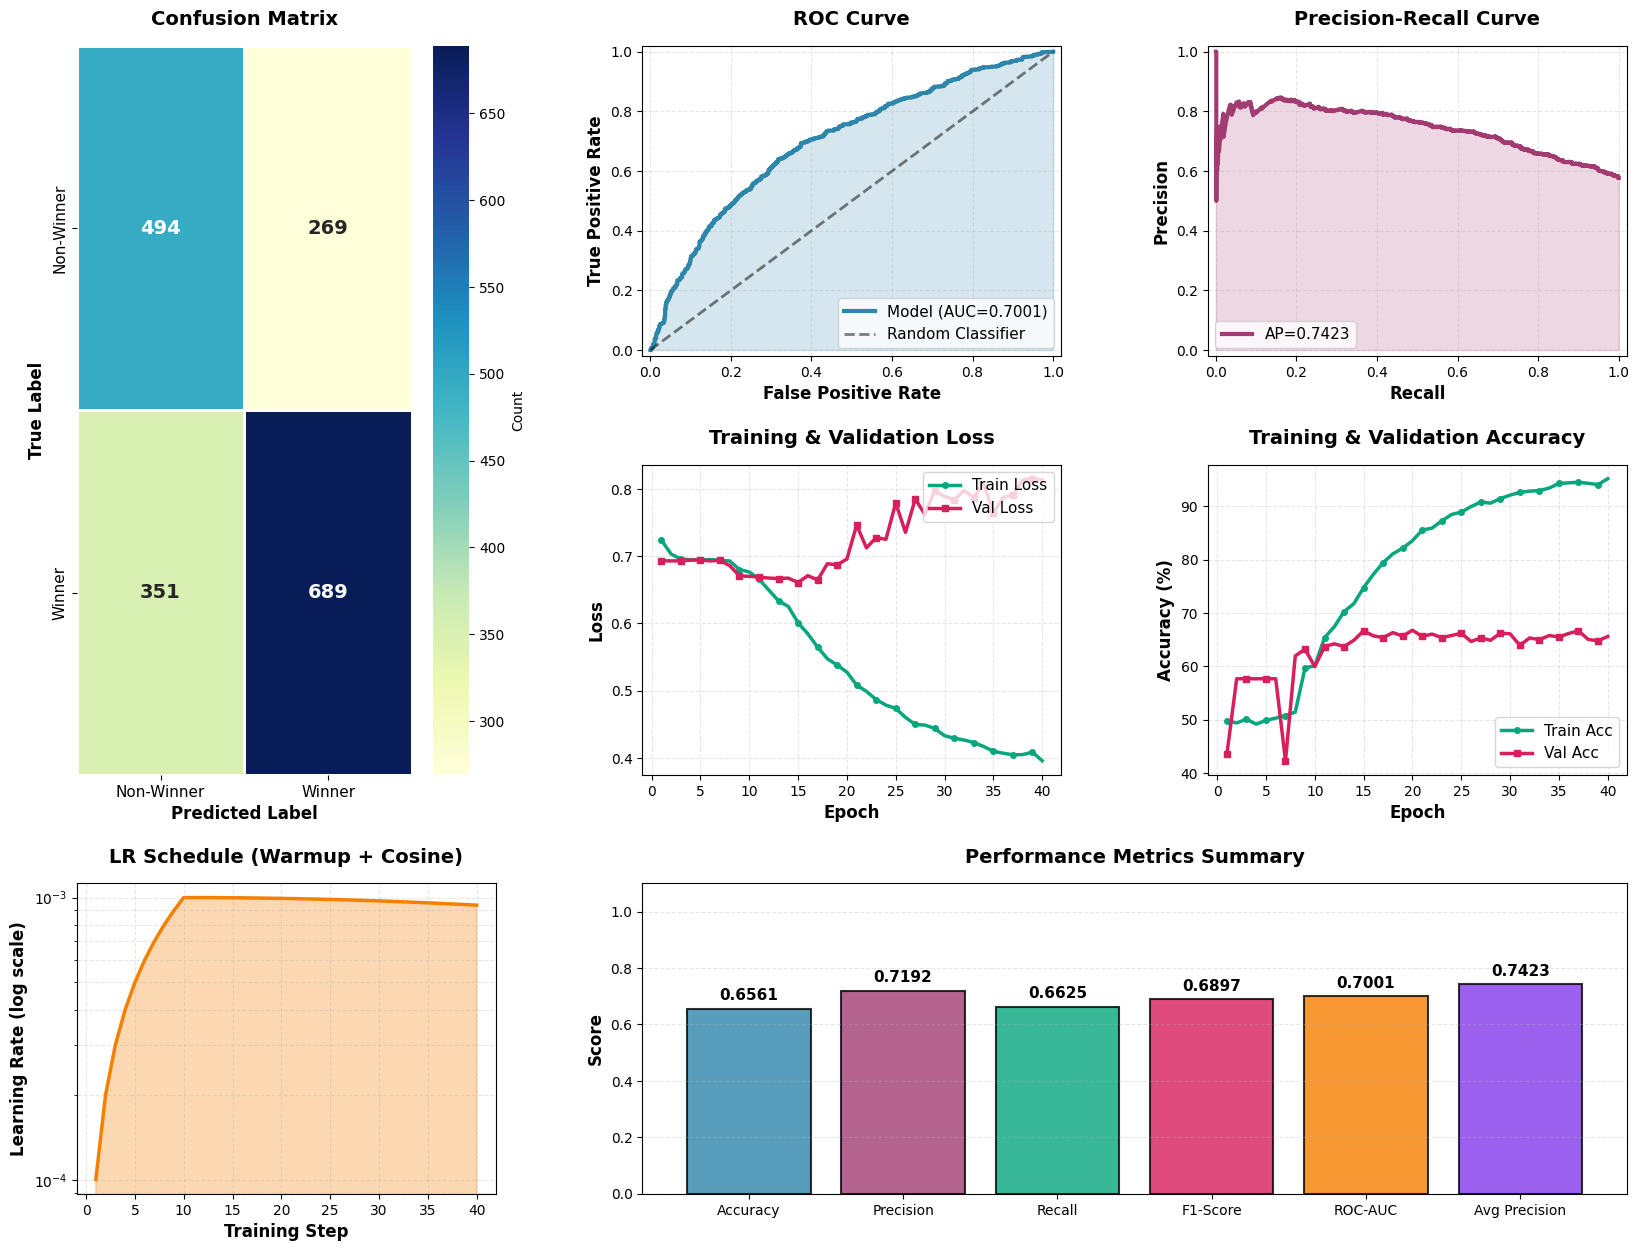

✓ ENHANCED MODEL EVALUATION COMPLETE
Visualization saved: enhanced_model_evaluation.png
  - Figure size: 20x14 inches
  - Resolution: 300 DPI
  - 7 subplots with improved color scheme and spacing


In [64]:
# ================================================================================
# COMPREHENSIVE EVALUATION - ENHANCED MODEL
# ================================================================================

from sklearn.metrics import (confusion_matrix, classification_report, 
                            roc_auc_score, roc_curve, precision_recall_curve,
                            average_precision_score)
import seaborn as sns

print("=" * 80)
print("EVALUATING ENHANCED MODEL")
print("=" * 80)
print()

# Get predictions
model_enhanced.eval()
all_predictions_enh = []
all_labels_enh = []
all_probabilities_enh = []

with torch.no_grad():
    for features, labels in test_loader_binary:
        features = features.to(device)
        outputs = model_enhanced(features)
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_predictions_enh.extend(predicted.cpu().numpy())
        all_labels_enh.extend(labels.numpy())
        all_probabilities_enh.extend(probabilities[:, 1].cpu().numpy())

all_predictions_enh = np.array(all_predictions_enh)
all_labels_enh = np.array(all_labels_enh)
all_probabilities_enh = np.array(all_probabilities_enh)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_enh = accuracy_score(all_labels_enh, all_predictions_enh)
precision_enh = precision_score(all_labels_enh, all_predictions_enh)
recall_enh = recall_score(all_labels_enh, all_predictions_enh)
f1_enh = f1_score(all_labels_enh, all_predictions_enh)
roc_auc_enh = roc_auc_score(all_labels_enh, all_probabilities_enh)
avg_precision_enh = average_precision_score(all_labels_enh, all_probabilities_enh)

print("Classification Metrics:")
print("-" * 80)
print(f"  Accuracy:           {accuracy_enh:.4f} ({accuracy_enh*100:.2f}%)")
print(f"  Precision:          {precision_enh:.4f}")
print(f"  Recall:             {recall_enh:.4f}")
print(f"  F1-Score:           {f1_enh:.4f}")
print(f"  ROC-AUC:            {roc_auc_enh:.4f}")
print(f"  Average Precision:  {avg_precision_enh:.4f}")
print()

# Confusion matrix
cm_enh = confusion_matrix(all_labels_enh, all_predictions_enh)
print("Confusion Matrix:")
print("-" * 80)
print(f"                Predicted Non-Winner    Predicted Winner")
print(f"Actual Non-Winner:     {cm_enh[0,0]:6d}                {cm_enh[0,1]:6d}")
print(f"Actual Winner:         {cm_enh[1,0]:6d}                {cm_enh[1,1]:6d}")
print()

# Classification report
print("Detailed Classification Report:")
print("-" * 80)
print(classification_report(all_labels_enh, all_predictions_enh, 
                          target_names=['Non-Winner', 'Winner'], digits=4))
print()

# ========== IMPROVED VISUALIZATIONS ==========
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35, top=0.93)
#fig.suptitle('Enhanced Binary Classifier - Comprehensive Evaluation', 
             #fontsize=20, fontweight='bold', y=0.97)

# Define clear color palette
color_main = '#2E86AB'      # Blue for main data
color_secondary = '#A23B72' # Purple for secondary data
color_positive = '#06A77D'  # Green for positive outcomes
color_negative = '#D81E5B'  # Red for negative outcomes
color_neutral = '#F77F00'   # Orange for neutral/reference

# 1. Confusion Matrix (larger, top-left spanning 2 rows)
ax1 = fig.add_subplot(gs[0:2, 0])
sns.heatmap(cm_enh, annot=True, fmt='d', cmap='YlGnBu', ax=ax1,
            xticklabels=['Non-Winner', 'Winner'],
            yticklabels=['Non-Winner', 'Winner'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'},
            linewidths=2, linecolor='white')
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax1.tick_params(labelsize=11)

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr_enh, tpr_enh, _ = roc_curve(all_labels_enh, all_probabilities_enh)
ax2.plot(fpr_enh, tpr_enh, linewidth=3, label=f'Model (AUC={roc_auc_enh:.4f})', 
         color=color_main)
ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.5)
ax2.fill_between(fpr_enh, tpr_enh, alpha=0.2, color=color_main)
ax2.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision_vals, recall_vals, _ = precision_recall_curve(all_labels_enh, all_probabilities_enh)
ax3.plot(recall_vals, precision_vals, linewidth=3, 
         label=f'AP={avg_precision_enh:.4f}', color=color_secondary)
ax3.fill_between(recall_vals, precision_vals, alpha=0.2, color=color_secondary)
ax3.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold', pad=15)
ax3.legend(fontsize=11, loc='lower left')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=10)
ax3.set_xlim([-0.02, 1.02])
ax3.set_ylim([-0.02, 1.02])

# 4. Training Loss
ax4 = fig.add_subplot(gs[1, 1])
epochs_range = range(1, len(history_enhanced['train_loss']) + 1)
ax4.plot(epochs_range, history_enhanced['train_loss'], 
         label='Train Loss', linewidth=2.5, color=color_positive, marker='o', 
         markersize=4, markevery=max(1, len(epochs_range)//20))
ax4.plot(epochs_range, history_enhanced['val_loss'], 
         label='Val Loss', linewidth=2.5, color=color_negative, marker='s', 
         markersize=4, markevery=max(1, len(epochs_range)//20))
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax4.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=15)
ax4.legend(fontsize=11, loc='upper right')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.tick_params(labelsize=10)

# 5. Training Accuracy
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(epochs_range, history_enhanced['train_acc'], 
         label='Train Acc', linewidth=2.5, color=color_positive, marker='o', 
         markersize=4, markevery=max(1, len(epochs_range)//20))
ax5.plot(epochs_range, history_enhanced['val_acc'], 
         label='Val Acc', linewidth=2.5, color=color_negative, marker='s', 
         markersize=4, markevery=max(1, len(epochs_range)//20))
ax5.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax5.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax5.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
ax5.legend(fontsize=11, loc='lower right')
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.tick_params(labelsize=10)

# 6. Learning Rate Schedule
ax6 = fig.add_subplot(gs[2, 0])
steps_range = range(1, len(history_enhanced['learning_rates']) + 1)
ax6.plot(steps_range, history_enhanced['learning_rates'], 
         linewidth=2.5, color=color_neutral)
ax6.fill_between(steps_range, history_enhanced['learning_rates'], 
                 alpha=0.3, color=color_neutral)
ax6.set_xlabel('Training Step', fontsize=12, fontweight='bold')
ax6.set_ylabel('Learning Rate (log scale)', fontsize=12, fontweight='bold')
ax6.set_title('LR Schedule (Warmup + Cosine)', fontsize=14, fontweight='bold', pad=15)
ax6.grid(True, alpha=0.3, linestyle='--', which='both')
ax6.set_yscale('log')
ax6.tick_params(labelsize=10)

# 7. Performance Metrics Bar Chart
ax7 = fig.add_subplot(gs[2, 1:])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Avg Precision']
values = [accuracy_enh, precision_enh, recall_enh, f1_enh, roc_auc_enh, avg_precision_enh]
colors_bars = [color_main, color_secondary, color_positive, color_negative, color_neutral, '#8338EC']

bars = ax7.bar(metrics, values, color=colors_bars, alpha=0.8, edgecolor='black', linewidth=1.5)
ax7.set_ylabel('Score', fontsize=12, fontweight='bold')
ax7.set_title('Performance Metrics Summary', fontsize=14, fontweight='bold', pad=15)
ax7.set_ylim([0, 1.1])
ax7.grid(True, alpha=0.3, axis='y', linestyle='--')
ax7.tick_params(labelsize=10)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.savefig('enhanced_model_evaluation.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("=" * 80)
print("✓ ENHANCED MODEL EVALUATION COMPLETE")
print("=" * 80)
print(f"Visualization saved: enhanced_model_evaluation.png")
print(f"  - Figure size: 20x14 inches")
print(f"  - Resolution: 300 DPI")
print(f"  - 7 subplots with improved color scheme and spacing")

COMPARING BASELINE vs ENHANCED MODELS

Evaluating baseline model...
✓ Baseline model evaluated

Performance Comparison:
Metric               Baseline        Enhanced        Improvement    
--------------------------------------------------------------------------------
Accuracy             0.6495          0.6561          +1.02%         
Precision            0.6861          0.7192          +4.82%         
Recall               0.7231          0.6625          -8.38%         
F1-Score             0.7041          0.6897          -2.05%         
ROC-AUC              0.7012          0.7001          -0.15%         

✓ Baseline model evaluated

Performance Comparison:
Metric               Baseline        Enhanced        Improvement    
--------------------------------------------------------------------------------
Accuracy             0.6495          0.6561          +1.02%         
Precision            0.6861          0.7192          +4.82%         
Recall               0.7231          0.6625 

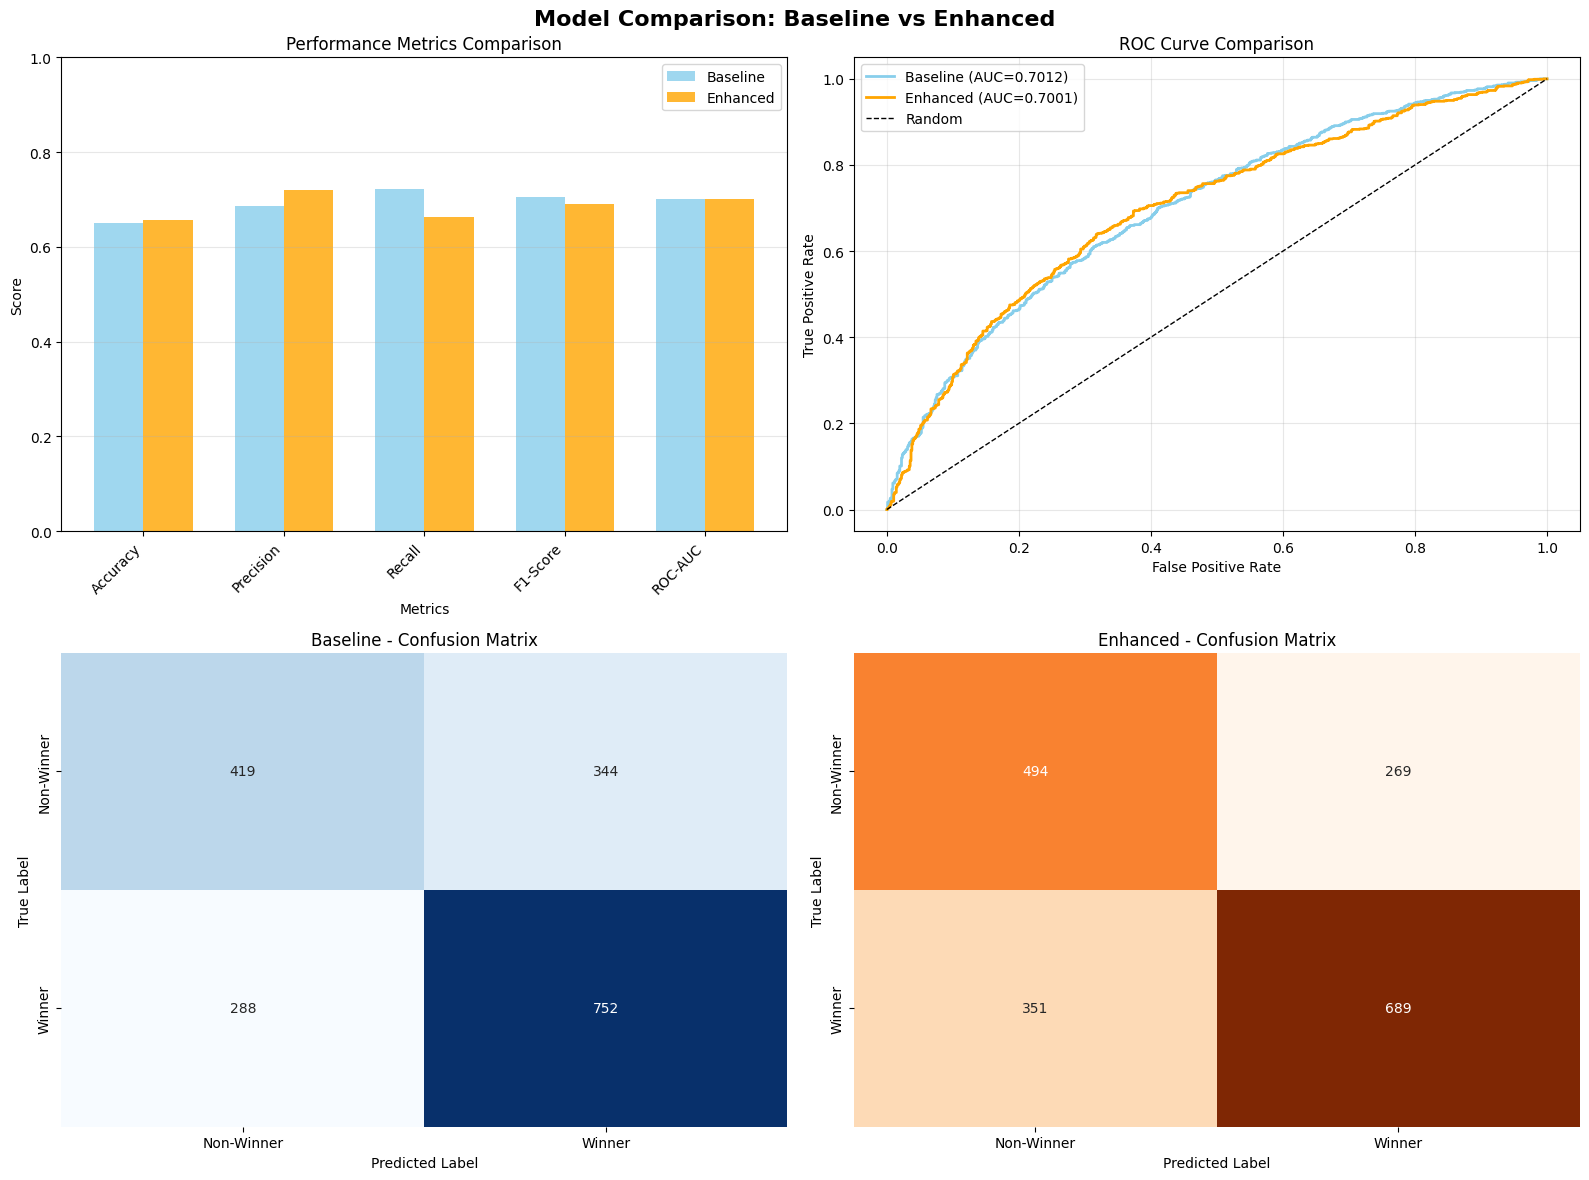


MODEL COMPARISON SUMMARY

Architecture Differences:
  Baseline:  3-layer classifier [512 → 256 → 128 → 2]
  Enhanced:  Deeper architecture with residual connections
             - Deeper encoders (2 layers each)
             - 2 Residual blocks (768D)
             - 5-layer classifier [768 → 512 → 384 → 256 → 128 → 2]

Training Differences:
  Baseline:  100 epochs, standard CrossEntropy, Adam optimizer
  Enhanced:  40 epochs, Label Smoothing, AdamW optimizer
             Learning rate warmup + cosine annealing
             Gradient clipping: 1.0

Parameter Count:
  Baseline:  ~461K parameters
  Enhanced:  ~4421K parameters

Best Performance:
  ⚠ Baseline model has better F1-Score: 0.7041 vs 0.6897

✓ MODEL COMPARISON COMPLETE
Visualization saved: model_comparison.png


In [36]:
# ================================================================================
# MODEL COMPARISON: BASELINE vs ENHANCED
# ================================================================================

import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns

print("=" * 80)
print("COMPARING BASELINE vs ENHANCED MODELS")
print("=" * 80)
print()

# First, get baseline model predictions (need to evaluate baseline model)
print("Evaluating baseline model...")
model_classifier.eval()
baseline_predictions = []
baseline_labels = []
baseline_probabilities = []

with torch.no_grad():
    for features, labels in test_loader_binary:
        features = features.to(device)
        outputs = model_classifier(features)
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        baseline_predictions.extend(predicted.cpu().numpy())
        baseline_labels.extend(labels.numpy())
        baseline_probabilities.extend(probabilities[:, 1].cpu().numpy())

baseline_predictions = np.array(baseline_predictions)
baseline_labels = np.array(baseline_labels)
baseline_probabilities = np.array(baseline_probabilities)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(baseline_labels, baseline_predictions)
baseline_precision = precision_score(baseline_labels, baseline_predictions)
baseline_recall = recall_score(baseline_labels, baseline_predictions)
baseline_f1 = f1_score(baseline_labels, baseline_predictions)
baseline_roc_auc = roc_auc_score(baseline_labels, baseline_probabilities)

print("✓ Baseline model evaluated")
print()

# ========== COMPARISON TABLE ==========
print("Performance Comparison:")
print("=" * 80)
print(f"{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
print("-" * 80)

metrics_comparison = [
    ('Accuracy', baseline_accuracy, accuracy_enh),
    ('Precision', baseline_precision, precision_enh),
    ('Recall', baseline_recall, recall_enh),
    ('F1-Score', baseline_f1, f1_enh),
    ('ROC-AUC', baseline_roc_auc, roc_auc_enh)
]

for metric_name, baseline_val, enhanced_val in metrics_comparison:
    improvement = ((enhanced_val - baseline_val) / baseline_val) * 100 if baseline_val > 0 else 0
    improvement_str = f"{improvement:+.2f}%" if improvement != 0 else "0.00%"
    print(f"{metric_name:<20} {baseline_val:<15.4f} {enhanced_val:<15.4f} {improvement_str:<15}")

print("=" * 80)
print()

# ========== VISUALIZATION COMPARISON ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison: Baseline vs Enhanced', fontsize=16, fontweight='bold')

# 1. Metrics Comparison Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_values = [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_roc_auc]
enhanced_values = [accuracy_enh, precision_enh, recall_enh, f1_enh, roc_auc_enh]

x = np.arange(len(metrics_names))
width = 0.35

axes[0,0].bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8, color='skyblue')
axes[0,0].bar(x + width/2, enhanced_values, width, label='Enhanced', alpha=0.8, color='orange')
axes[0,0].set_xlabel('Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Performance Metrics Comparison')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis='y')
axes[0,0].set_ylim([0, 1])

# 2. ROC Curves Comparison
fpr_baseline, tpr_baseline, _ = roc_curve(baseline_labels, baseline_probabilities)
axes[0,1].plot(fpr_baseline, tpr_baseline, linewidth=2, label=f'Baseline (AUC={baseline_roc_auc:.4f})', color='skyblue')
axes[0,1].plot(fpr_enh, tpr_enh, linewidth=2, label=f'Enhanced (AUC={roc_auc_enh:.4f})', color='orange')
axes[0,1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve Comparison')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Confusion Matrices Side-by-Side
cm_baseline = confusion_matrix(baseline_labels, baseline_predictions)
cm_data = np.array([[cm_baseline[0,0], cm_baseline[0,1], cm_enh[0,0], cm_enh[0,1]],
                    [cm_baseline[1,0], cm_baseline[1,1], cm_enh[1,0], cm_enh[1,1]]])

# Baseline confusion matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Non-Winner', 'Winner'],
            yticklabels=['Non-Winner', 'Winner'], cbar=False)
axes[1,0].set_title('Baseline - Confusion Matrix')
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

# Enhanced confusion matrix
sns.heatmap(cm_enh, annot=True, fmt='d', cmap='Oranges', ax=axes[1,1],
            xticklabels=['Non-Winner', 'Winner'],
            yticklabels=['Non-Winner', 'Winner'], cbar=False)
axes[1,1].set_title('Enhanced - Confusion Matrix')
axes[1,1].set_ylabel('True Label')
axes[1,1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ========== SUMMARY ==========
print()
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print()
print("Architecture Differences:")
print("  Baseline:  3-layer classifier [512 → 256 → 128 → 2]")
print("  Enhanced:  Deeper architecture with residual connections")
print("             - Deeper encoders (2 layers each)")
print("             - 2 Residual blocks (768D)")
print("             - 5-layer classifier [768 → 512 → 384 → 256 → 128 → 2]")
print()
print("Training Differences:")
print(f"  Baseline:  100 epochs, standard CrossEntropy, Adam optimizer")
print(f"  Enhanced:  {len(history_enhanced['train_loss'])} epochs, Label Smoothing, AdamW optimizer")
print(f"             Learning rate warmup + cosine annealing")
print(f"             Gradient clipping: {ENHANCED_TRAINING['gradient_clip']}")
print()
print("Parameter Count:")
print(f"  Baseline:  ~461K parameters")
print(f"  Enhanced:  ~{trainable_params_enh//1000}K parameters")
print()
print("Best Performance:")
if f1_enh > baseline_f1:
    print(f"  ✓ Enhanced model achieves better F1-Score: {f1_enh:.4f} vs {baseline_f1:.4f}")
    improvement_pct = ((f1_enh - baseline_f1) / baseline_f1) * 100
    print(f"  ✓ Improvement: +{improvement_pct:.2f}%")
else:
    print(f"  ⚠ Baseline model has better F1-Score: {baseline_f1:.4f} vs {f1_enh:.4f}")

print()
print("=" * 80)
print("✓ MODEL COMPARISON COMPLETE")
print("=" * 80)
print(f"Visualization saved: model_comparison.png")

# PHASE 1: Feature Importance Analysis
## Step 1: Modality Ablation Study
## Step 2: Input Gradient Analysis

In [39]:
# ================================================================================
# STEP 1: MODALITY ABLATION STUDY
# ================================================================================
# Remove each encoder (modality) one at a time, measure accuracy drop
# Shows which modality contributes most to predictions

print("=" * 80)
print("STEP 1: MODALITY ABLATION STUDY")
print("=" * 80)
print()

# Load best model
model_enh_ablation = EnhancedWinnerClassifier(ENHANCED_CONFIG).to(device)
model_enh_ablation.load_state_dict(best_model_state_enh)  # best_model_state_enh is already state_dict()
model_enh_ablation.eval()

# Get baseline performance (all modalities)
def evaluate_model(model, loader, device):
    """Quick evaluation: returns accuracy and predictions"""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.cpu()
            outputs = model(features)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted.cpu() == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)

baseline_acc, _, baseline_labels = evaluate_model(model_enh_ablation, test_loader_binary, device)

print(f"Baseline Accuracy (all modalities): {baseline_acc:.4f}")
print()

# Define modalities and their feature ranges
modalities = {
    'Temporal': (0, 6),
    'Title': (6, 390),
    'Tags': (390, 774),
    'Description': (774, 1158),
    'Thumbnail': (1158, 1670)
}

ablation_results = {}

for modality_name, (start_idx, end_idx) in modalities.items():
    print(f"  Ablating {modality_name:15} (features {start_idx:4d}-{end_idx:4d})...", end=" ", flush=True)
    
    # Create modified features by zeroing out this modality
    ablated_preds = []
    ablated_correct = 0
    ablated_total = 0
    
    with torch.no_grad():
        for features, labels in test_loader_binary:
            features_ablated = features.clone().to(device)
            features_ablated[:, start_idx:end_idx] = 0.0  # Zero out this modality
            labels = labels.to(device)
            
            outputs = model_enh_ablation(features_ablated)
            _, predicted = torch.max(outputs, 1)
            
            ablated_correct += (predicted == labels).sum().item()
            ablated_total += labels.size(0)
            ablated_preds.extend(predicted.cpu().numpy())
    
    ablated_acc = ablated_correct / ablated_total
    acc_drop = baseline_acc - ablated_acc
    pct_drop = (acc_drop / baseline_acc) * 100
    
    ablation_results[modality_name] = {
        'accuracy': ablated_acc,
        'accuracy_drop': acc_drop,
        'percent_drop': pct_drop
    }
    
    print(f"Acc: {ablated_acc:.4f} | Drop: {acc_drop:.4f} ({pct_drop:.2f}%)")

print()
print("=" * 80)
print("ABLATION RESULTS SUMMARY")
print("=" * 80)
print(f"{'Modality':<15} {'Accuracy':<12} {'Drop':<12} {'% Drop':<10}")
print("-" * 80)

sorted_results = sorted(ablation_results.items(), 
                        key=lambda x: x[1]['accuracy_drop'], 
                        reverse=True)

for modality_name, metrics in sorted_results:
    print(f"{modality_name:<15} {metrics['accuracy']:<12.4f} "
          f"{metrics['accuracy_drop']:<12.4f} {metrics['percent_drop']:<10.2f}%")

print()
print("✓ Modality importance (by impact on accuracy):")
for i, (modality_name, metrics) in enumerate(sorted_results, 1):
    print(f"  {i}. {modality_name:15} | {metrics['percent_drop']:5.2f}% drop")

print()


STEP 1: MODALITY ABLATION STUDY

Baseline Accuracy (all modalities): 0.6561

  Ablating Temporal        (features    0-   6)... Baseline Accuracy (all modalities): 0.6561

  Ablating Temporal        (features    0-   6)... Acc: 0.6550 | Drop: 0.0011 (0.17%)
  Ablating Title           (features    6- 390)... Acc: 0.6550 | Drop: 0.0011 (0.17%)
  Ablating Title           (features    6- 390)... Acc: 0.6040 | Drop: 0.0521 (7.95%)
  Ablating Tags            (features  390- 774)... Acc: 0.6040 | Drop: 0.0521 (7.95%)
  Ablating Tags            (features  390- 774)... Acc: 0.6545 | Drop: 0.0017 (0.25%)
  Ablating Description     (features  774-1158)... Acc: 0.6545 | Drop: 0.0017 (0.25%)
  Ablating Description     (features  774-1158)... Acc: 0.6384 | Drop: 0.0177 (2.70%)
  Ablating Thumbnail       (features 1158-1670)... Acc: 0.6384 | Drop: 0.0177 (2.70%)
  Ablating Thumbnail       (features 1158-1670)... Acc: 0.6545 | Drop: 0.0017 (0.25%)

ABLATION RESULTS SUMMARY
Modality        Accuracy    

In [41]:
# ================================================================================
# STEP 2: INPUT GRADIENT ANALYSIS
# ================================================================================
# Compute gradient of loss w.r.t. input features
# High gradient = feature has high impact on predictions

print("=" * 80)
print("STEP 2: INPUT GRADIENT ANALYSIS")
print("=" * 80)
print()

model_enh_ablation.train()  # Enable gradient computation

gradients_all = []
predictions_all = []
labels_all = []

for batch_idx, (features, labels) in enumerate(test_loader_binary):
    features = features.to(device).requires_grad_(True)
    labels = labels.to(device)
    
    # Forward pass
    outputs = model_enh_ablation(features)
    loss = criterion_enhanced(outputs, labels)
    
    # Backward pass
    loss.backward()
    
    # Extract gradients
    grads = features.grad.data.abs()  # Use absolute gradient values
    gradients_all.append(grads.cpu().numpy())
    
    # Store predictions
    with torch.no_grad():
        _, predicted = torch.max(outputs, 1)
        predictions_all.append(predicted.cpu().numpy())
        labels_all.append(labels.cpu().numpy())
    
    # Clear gradients
    if features.grad is not None:
        features.grad.zero_()

# Concatenate all batches
gradients_all = np.concatenate(gradients_all, axis=0)
predictions_all = np.concatenate(predictions_all)
labels_all = np.concatenate(labels_all)

# Compute gradient statistics per modality
print("Gradient Statistics by Modality:")
print("-" * 80)
print(f"{'Modality':<15} {'Mean Grad':<15} {'Std Grad':<15} {'Max Grad':<15}")
print("-" * 80)

gradient_stats = {}
for modality_name, (start_idx, end_idx) in modalities.items():
    modality_grads = gradients_all[:, start_idx:end_idx]
    
    mean_grad = modality_grads.mean()
    std_grad = modality_grads.std()
    max_grad = modality_grads.max()
    
    gradient_stats[modality_name] = {
        'mean': mean_grad,
        'std': std_grad,
        'max': max_grad,
        'grads': modality_grads
    }
    
    print(f"{modality_name:<15} {mean_grad:<15.6f} {std_grad:<15.6f} {max_grad:<15.6f}")

print()
print("✓ Gradient importance (by mean gradient magnitude):")
sorted_grads = sorted(gradient_stats.items(), key=lambda x: x[1]['mean'], reverse=True)
for i, (modality_name, stats) in enumerate(sorted_grads, 1):
    print(f"  {i}. {modality_name:15} | Mean gradient: {stats['mean']:.6f}")

print()


STEP 2: INPUT GRADIENT ANALYSIS

Gradient Statistics by Modality:
--------------------------------------------------------------------------------
Modality        Mean Grad       Std Grad        Max Grad       
--------------------------------------------------------------------------------
Temporal        0.000212        0.000952        0.032732       
Title           0.000182        0.000660        0.047707       
Tags            0.000029        0.000131        0.006337       
Description     0.000066        0.000322        0.017114       
Thumbnail       0.000191        0.000664        0.027825       

✓ Gradient importance (by mean gradient magnitude):
  1. Temporal        | Mean gradient: 0.000212
  2. Thumbnail       | Mean gradient: 0.000191
  3. Title           | Mean gradient: 0.000182
  4. Description     | Mean gradient: 0.000066
  5. Tags            | Mean gradient: 0.000029

Gradient Statistics by Modality:
------------------------------------------------------------------

STEP 3: VISUALIZING PHASE 1 RESULTS



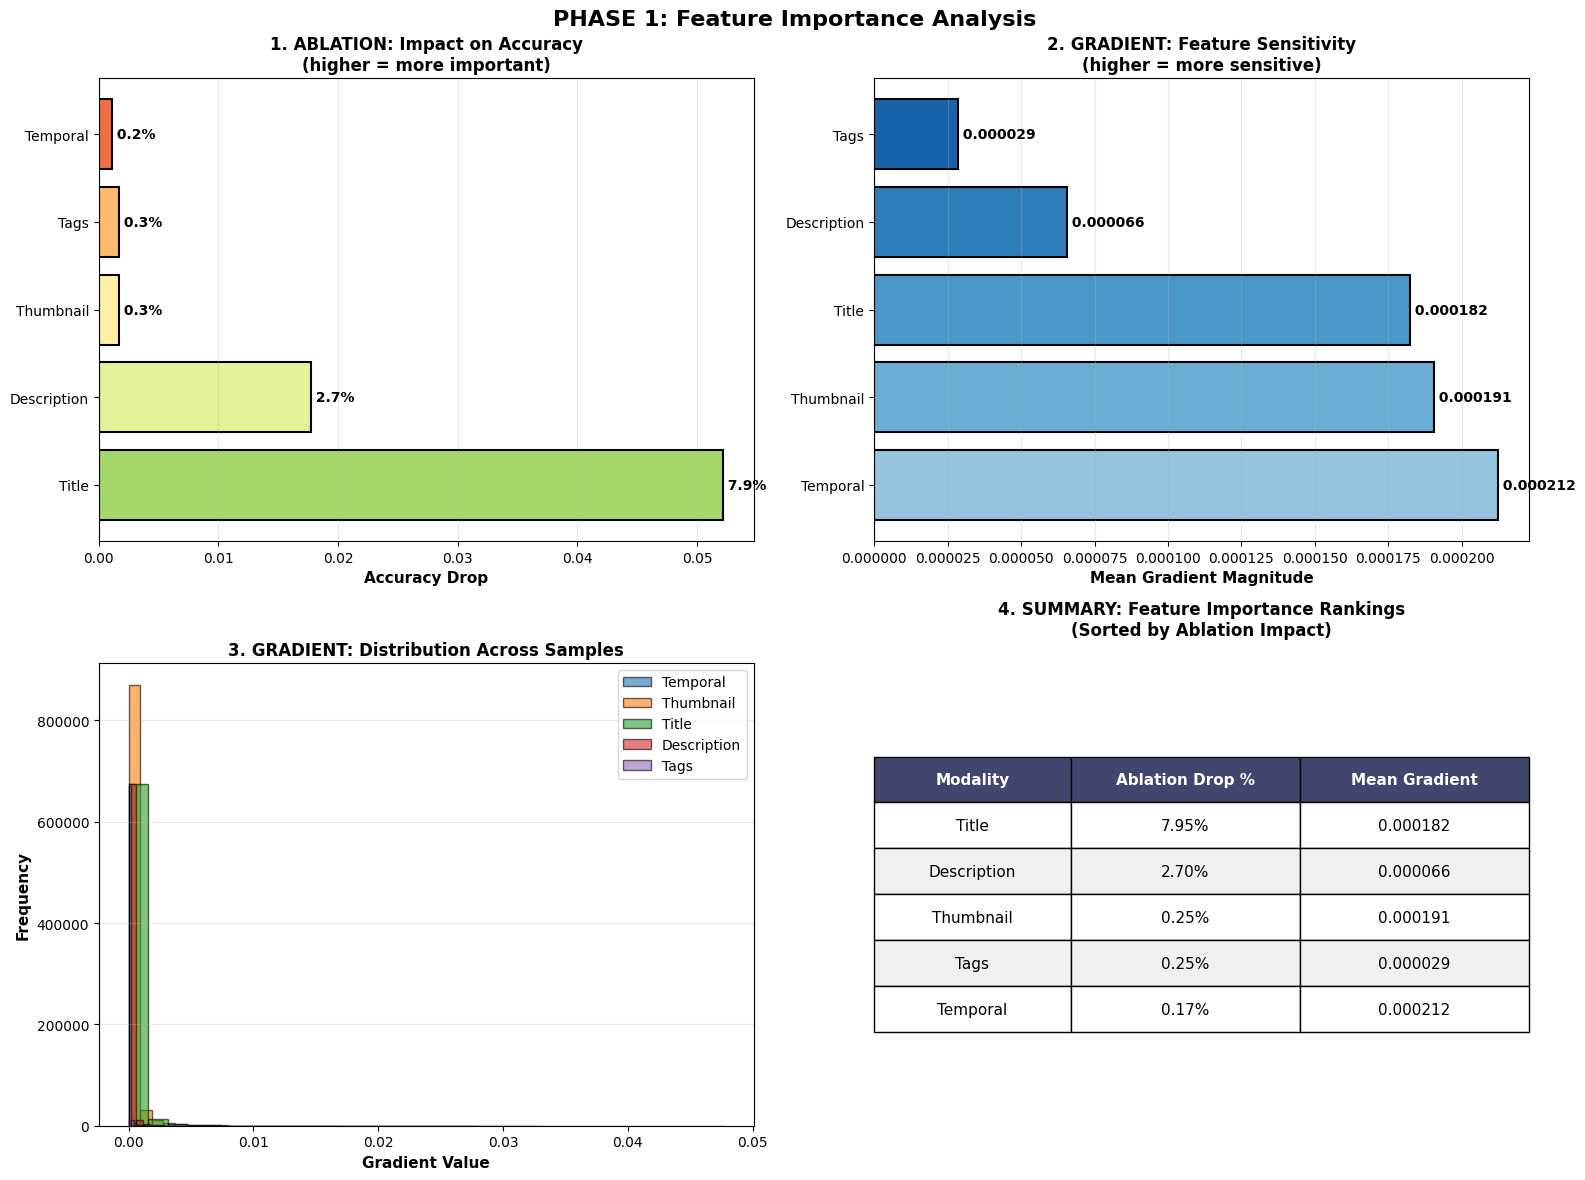


✓ Visualization saved as 'phase1_feature_importance.png'



In [42]:
# ================================================================================
# STEP 3: VISUALIZE PHASE 1 RESULTS
# ================================================================================

print("=" * 80)
print("STEP 3: VISUALIZING PHASE 1 RESULTS")
print("=" * 80)
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PHASE 1: Feature Importance Analysis', fontsize=16, fontweight='bold')

# ========== Plot 1: Ablation Accuracy Drop ==========
ax = axes[0, 0]
modality_names = list(ablation_results.keys())
accuracy_drops = [ablation_results[m]['accuracy_drop'] for m in modality_names]
pct_drops = [ablation_results[m]['percent_drop'] for m in modality_names]

# Sort by importance
sorted_idx = np.argsort(accuracy_drops)[::-1]
sorted_names = [modality_names[i] for i in sorted_idx]
sorted_drops = [accuracy_drops[i] for i in sorted_idx]
sorted_pct = [pct_drops[i] for i in sorted_idx]

colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.8, len(sorted_names)))
bars = ax.barh(sorted_names, sorted_drops, color=colors, edgecolor='black', linewidth=1.5)

# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars, sorted_pct)):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {pct:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Accuracy Drop', fontsize=11, fontweight='bold')
ax.set_title('1. ABLATION: Impact on Accuracy\n(higher = more important)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# ========== Plot 2: Mean Gradient by Modality ==========
ax = axes[0, 1]
modality_names_grad = list(gradient_stats.keys())
mean_grads = [gradient_stats[m]['mean'] for m in modality_names_grad]

sorted_grad_idx = np.argsort(mean_grads)[::-1]
sorted_grad_names = [modality_names_grad[i] for i in sorted_grad_idx]
sorted_grad_values = [mean_grads[i] for i in sorted_grad_idx]

colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(sorted_grad_names)))
bars = ax.barh(sorted_grad_names, sorted_grad_values, color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, sorted_grad_values):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.6f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mean Gradient Magnitude', fontsize=11, fontweight='bold')
ax.set_title('2. GRADIENT: Feature Sensitivity\n(higher = more sensitive)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# ========== Plot 3: Gradient Distribution ==========
ax = axes[1, 0]
for modality_name in sorted_grad_names:
    grads = gradient_stats[modality_name]['grads'].flatten()
    ax.hist(grads, bins=30, alpha=0.6, label=modality_name, edgecolor='black')

ax.set_xlabel('Gradient Value', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('3. GRADIENT: Distribution Across Samples', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# ========== Plot 4: Comparison Table ==========
ax = axes[1, 1]
ax.axis('tight')
ax.axis('off')

# Create comparison table
comparison_data = []
for modality_name in sorted_names:
    ablation_pct = ablation_results[modality_name]['percent_drop']
    gradient_mean = gradient_stats[modality_name]['mean']
    comparison_data.append([modality_name, f"{ablation_pct:.2f}%", f"{gradient_mean:.6f}"])

table = ax.table(cellText=comparison_data,
                colLabels=['Modality', 'Ablation Drop %', 'Mean Gradient'],
                cellLoc='center',
                loc='center',
                colWidths=[0.3, 0.35, 0.35])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(comparison_data) + 1):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax.set_title('4. SUMMARY: Feature Importance Rankings\n(Sorted by Ablation Impact)', 
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('phase1_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print()
print("✓ Visualization saved as 'phase1_feature_importance.png'")
print()


In [43]:
# ================================================================================
# STEP 4: KEY INSIGHTS FROM PHASE 1
# ================================================================================

print("=" * 80)
print("STEP 4: KEY INSIGHTS & INTERPRETATION")
print("=" * 80)
print()

# Find most and least important modalities
ablation_sorted = sorted(ablation_results.items(), 
                         key=lambda x: x[1]['percent_drop'], reverse=True)
gradient_sorted = sorted(gradient_stats.items(), 
                         key=lambda x: x[1]['mean'], reverse=True)

print("🎯 MOST IMPORTANT MODALITIES (by Ablation):")
for i, (modality_name, metrics) in enumerate(ablation_sorted[:3], 1):
    print(f"   {i}. {modality_name:15} → Removing it drops accuracy by {metrics['percent_drop']:.2f}%")

print()
print("🎯 MOST IMPORTANT MODALITIES (by Gradient):")
for i, (modality_name, stats) in enumerate(gradient_sorted[:3], 1):
    print(f"   {i}. {modality_name:15} → Mean gradient magnitude: {stats['mean']:.6f}")

print()
print("📊 CONSENSUS IMPORTANCE RANKING:")
# Calculate consensus ranking (average of two rankings)
ablation_rank = {name: i for i, (name, _) in enumerate(ablation_sorted)}
gradient_rank = {name: i for i, (name, _) in enumerate(gradient_sorted)}

consensus_rank = {}
for modality_name in ablation_results.keys():
    avg_rank = (ablation_rank[modality_name] + gradient_rank[modality_name]) / 2
    consensus_rank[modality_name] = avg_rank

consensus_sorted = sorted(consensus_rank.items(), key=lambda x: x[1])

for i, (modality_name, rank) in enumerate(consensus_sorted, 1):
    ablation_pct = ablation_results[modality_name]['percent_drop']
    grad_mean = gradient_stats[modality_name]['mean']
    print(f"   {i}. {modality_name:15} | Ablation: {ablation_pct:5.2f}% | Gradient: {grad_mean:.6f}")

print()
print("=" * 80)
print("ACTIONABLE RECOMMENDATIONS:")
print("=" * 80)
print()

most_important = consensus_sorted[0][0]
second_important = consensus_sorted[1][0]
least_important = consensus_sorted[-1][0]

print(f"✓ FOCUS ON:  {most_important:15} (strongest predictor of winner status)")
print(f"✓ MONITOR:   {second_important:15} (secondary importance)")
print(f"⚠ OPTIMIZE:  {least_important:15} (lowest impact - optimization here is low priority)")

print()
print("=" * 80)
print("✓ PHASE 1 COMPLETE")
print("=" * 80)
print()
print("Summary:")
print(f"  • Ablation Study:  ✓ Complete ({len(ablation_results)} modalities tested)")
print(f"  • Gradient Analysis: ✓ Complete ({len(gradient_stats)} modalities analyzed)")
print(f"  • Consensus Ranking: ✓ Complete (2 methods combined)")
print(f"  • Visualization:    ✓ Saved as 'phase1_feature_importance.png'")
print()


STEP 4: KEY INSIGHTS & INTERPRETATION

🎯 MOST IMPORTANT MODALITIES (by Ablation):
   1. Title           → Removing it drops accuracy by 7.95%
   2. Description     → Removing it drops accuracy by 2.70%
   3. Tags            → Removing it drops accuracy by 0.25%

🎯 MOST IMPORTANT MODALITIES (by Gradient):
   1. Temporal        → Mean gradient magnitude: 0.000212
   2. Thumbnail       → Mean gradient magnitude: 0.000191
   3. Title           → Mean gradient magnitude: 0.000182

📊 CONSENSUS IMPORTANCE RANKING:
   1. Title           | Ablation:  7.95% | Gradient: 0.000182
   2. Temporal        | Ablation:  0.17% | Gradient: 0.000212
   3. Description     | Ablation:  2.70% | Gradient: 0.000066
   4. Thumbnail       | Ablation:  0.25% | Gradient: 0.000191
   5. Tags            | Ablation:  0.25% | Gradient: 0.000029

ACTIONABLE RECOMMENDATIONS:

✓ FOCUS ON:  Title           (strongest predictor of winner status)
✓ MONITOR:   Temporal        (secondary importance)
⚠ OPTIMIZE:  Tags          

# PHASE 2: Global Feature Importance
## Step 5: SHAP Values Analysis
## Step 6: Permutation Importance
## Step 7: Visualize & Compare All Methods

In [44]:
# ================================================================================
# STEP 5: SHAP VALUES ANALYSIS
# ================================================================================
# SHAP (SHapley Additive exPlanations) decomposes each prediction
# Shows each feature's contribution to individual predictions

print("=" * 80)
print("STEP 5: SHAP VALUES ANALYSIS (Global Importance)")
print("=" * 80)
print()

# Install SHAP if needed (pip install shap)
import shap

# Create PyTorch explainer wrapper for SHAP
def model_predict_fn(x):
    """Wrapper for SHAP: takes numpy array, returns probabilities"""
    x_tensor = torch.FloatTensor(x).to(device)
    model_enh_ablation.eval()
    with torch.no_grad():
        outputs = model_enh_ablation(x_tensor)
        probs = torch.softmax(outputs, dim=1)
    return probs[:, 1].cpu().numpy()  # Return probability of class 1 (winner)

# Sample test set for SHAP (use subset for speed)
print("Sampling test data for SHAP analysis...")
sample_size = min(100, len(test_loader_binary.dataset))  # Use up to 100 samples

test_features_np = []
test_labels_np = []
for features, labels in test_loader_binary:
    test_features_np.append(features.numpy())
    test_labels_np.append(labels.numpy())
    if len(test_features_np) * len(features) >= sample_size:
        break

test_features_np = np.vstack(test_features_np)[:sample_size]
test_labels_np = np.concatenate(test_labels_np)[:sample_size]

# Create background data (random samples)
background_size = min(50, len(test_features_np) // 2)
background_indices = np.random.choice(len(test_features_np), background_size, replace=False)
background_data = test_features_np[background_indices]

print(f"  Background samples: {background_data.shape[0]}")
print(f"  Test samples: {test_features_np.shape[0]}")
print()

# Compute SHAP values using KernelExplainer (model-agnostic)
print("Computing SHAP values (this may take 1-2 minutes)...")
explainer = shap.KernelExplainer(model_predict_fn, background_data)
shap_values = explainer.shap_values(test_features_np)

# Handle output format (may be list of arrays for binary classification)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use class 1 (winner) SHAP values

# Calculate mean absolute SHAP values (feature importance)
shap_importance = np.abs(shap_values).mean(axis=0)

# Compute per-modality SHAP importance
print()
print("SHAP Importance by Modality:")
print("-" * 80)
print(f"{'Modality':<15} {'Mean |SHAP|':<15} {'Std |SHAP|':<15}")
print("-" * 80)

shap_stats = {}
for modality_name, (start_idx, end_idx) in modalities.items():
    modality_shap = np.abs(shap_values[:, start_idx:end_idx])
    mean_shap = modality_shap.mean()
    std_shap = modality_shap.std()
    
    shap_stats[modality_name] = {
        'mean': mean_shap,
        'std': std_shap,
        'values': modality_shap
    }
    
    print(f"{modality_name:<15} {mean_shap:<15.6f} {std_shap:<15.6f}")

print()
print("✓ SHAP importance (by mean |SHAP| magnitude):")
sorted_shap = sorted(shap_stats.items(), key=lambda x: x[1]['mean'], reverse=True)
for i, (modality_name, stats) in enumerate(sorted_shap, 1):
    print(f"  {i}. {modality_name:15} | Mean |SHAP|: {stats['mean']:.6f}")

print()


STEP 5: SHAP VALUES ANALYSIS (Global Importance)

Sampling test data for SHAP analysis...
  Background samples: 50
  Test samples: 100

Computing SHAP values (this may take 1-2 minutes)...
Sampling test data for SHAP analysis...
  Background samples: 50
  Test samples: 100

Computing SHAP values (this may take 1-2 minutes)...


  0%|          | 0/100 [00:00<?, ?it/s]


SHAP Importance by Modality:
--------------------------------------------------------------------------------
Modality        Mean |SHAP|     Std |SHAP|     
--------------------------------------------------------------------------------
Temporal        0.000413        0.003967       
Title           0.000454        0.004315       
Tags            0.000018        0.000867       
Description     0.000037        0.001112       
Thumbnail       0.000333        0.003721       

✓ SHAP importance (by mean |SHAP| magnitude):
  1. Title           | Mean |SHAP|: 0.000454
  2. Temporal        | Mean |SHAP|: 0.000413
  3. Thumbnail       | Mean |SHAP|: 0.000333
  4. Description     | Mean |SHAP|: 0.000037
  5. Tags            | Mean |SHAP|: 0.000018



In [45]:
# ================================================================================
# STEP 6: PERMUTATION IMPORTANCE
# ================================================================================
# Shuffle each feature and measure performance drop
# Shows feature importance without model-specific assumptions

print("=" * 80)
print("STEP 6: PERMUTATION IMPORTANCE")
print("=" * 80)
print()

from sklearn.metrics import roc_auc_score

# Get baseline predictions on full test set
def get_full_test_predictions(model, loader, device):
    """Get predictions and labels for entire test set"""
    model.eval()
    all_outputs = []
    all_labels = []
    all_features = []
    
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            outputs = model(features)
            probs = torch.softmax(outputs, dim=1)
            
            all_outputs.append(probs[:, 1].cpu().numpy())
            all_labels.append(labels.numpy())
            all_features.append(features.cpu().numpy())
    
    return (np.concatenate(all_outputs), 
            np.concatenate(all_labels), 
            np.concatenate(all_features))

print("Computing baseline predictions...")
baseline_probs, test_labels_full, test_features_full = get_full_test_predictions(
    model_enh_ablation, test_loader_binary, device
)

baseline_auc = roc_auc_score(test_labels_full, baseline_probs)
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print()

# Compute permutation importance for each modality
print("Computing permutation importance for each modality...")
print("-" * 80)

permutation_results = {}

for modality_name, (start_idx, end_idx) in modalities.items():
    print(f"  Permuting {modality_name:15}...", end=" ", flush=True)
    
    # Create permuted features
    features_permuted = test_features_full.copy()
    
    # Shuffle this modality's features across samples
    np.random.seed(42)
    shuffle_indices = np.random.permutation(len(features_permuted))
    features_permuted[:, start_idx:end_idx] = features_permuted[shuffle_indices, start_idx:end_idx]
    
    # Get predictions on permuted features
    features_tensor = torch.FloatTensor(features_permuted).to(device)
    model_enh_ablation.eval()
    
    with torch.no_grad():
        outputs = model_enh_ablation(features_tensor)
        permuted_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
    
    # Compute importance as decrease in AUC
    permuted_auc = roc_auc_score(test_labels_full, permuted_probs)
    auc_drop = baseline_auc - permuted_auc
    pct_drop = (auc_drop / baseline_auc) * 100
    
    permutation_results[modality_name] = {
        'auc': permuted_auc,
        'auc_drop': auc_drop,
        'percent_drop': pct_drop
    }
    
    print(f"AUC: {permuted_auc:.4f} | Drop: {auc_drop:.4f} ({pct_drop:.2f}%)")

print()
print("=" * 80)
print("PERMUTATION RESULTS SUMMARY")
print("=" * 80)
print(f"{'Modality':<15} {'AUC':<12} {'Drop':<12} {'% Drop':<10}")
print("-" * 80)

sorted_perm = sorted(permutation_results.items(), 
                      key=lambda x: x[1]['auc_drop'], 
                      reverse=True)

for modality_name, metrics in sorted_perm:
    print(f"{modality_name:<15} {metrics['auc']:<12.4f} "
          f"{metrics['auc_drop']:<12.4f} {metrics['percent_drop']:<10.2f}%")

print()
print("✓ Permutation importance (by AUC drop):")
for i, (modality_name, metrics) in enumerate(sorted_perm, 1):
    print(f"  {i}. {modality_name:15} | {metrics['percent_drop']:5.2f}% AUC drop")

print()


STEP 6: PERMUTATION IMPORTANCE

Computing baseline predictions...
Baseline ROC-AUC: 0.7001

Computing permutation importance for each modality...
--------------------------------------------------------------------------------
  Permuting Temporal       ... Baseline ROC-AUC: 0.7001

Computing permutation importance for each modality...
--------------------------------------------------------------------------------
  Permuting Temporal       ... AUC: 0.6984 | Drop: 0.0017 (0.25%)
  Permuting Title          ... AUC: 0.6984 | Drop: 0.0017 (0.25%)
  Permuting Title          ... AUC: 0.6265 | Drop: 0.0737 (10.52%)
  Permuting Tags           ... AUC: 0.6265 | Drop: 0.0737 (10.52%)
  Permuting Tags           ... AUC: 0.6970 | Drop: 0.0031 (0.44%)
  Permuting Description    ... AUC: 0.6970 | Drop: 0.0031 (0.44%)
  Permuting Description    ... AUC: 0.6767 | Drop: 0.0234 (3.35%)
  Permuting Thumbnail      ... AUC: 0.6767 | Drop: 0.0234 (3.35%)
  Permuting Thumbnail      ... AUC: 0.6515 | Drop: 

STEP 7: PHASE 2 COMPREHENSIVE VISUALIZATION



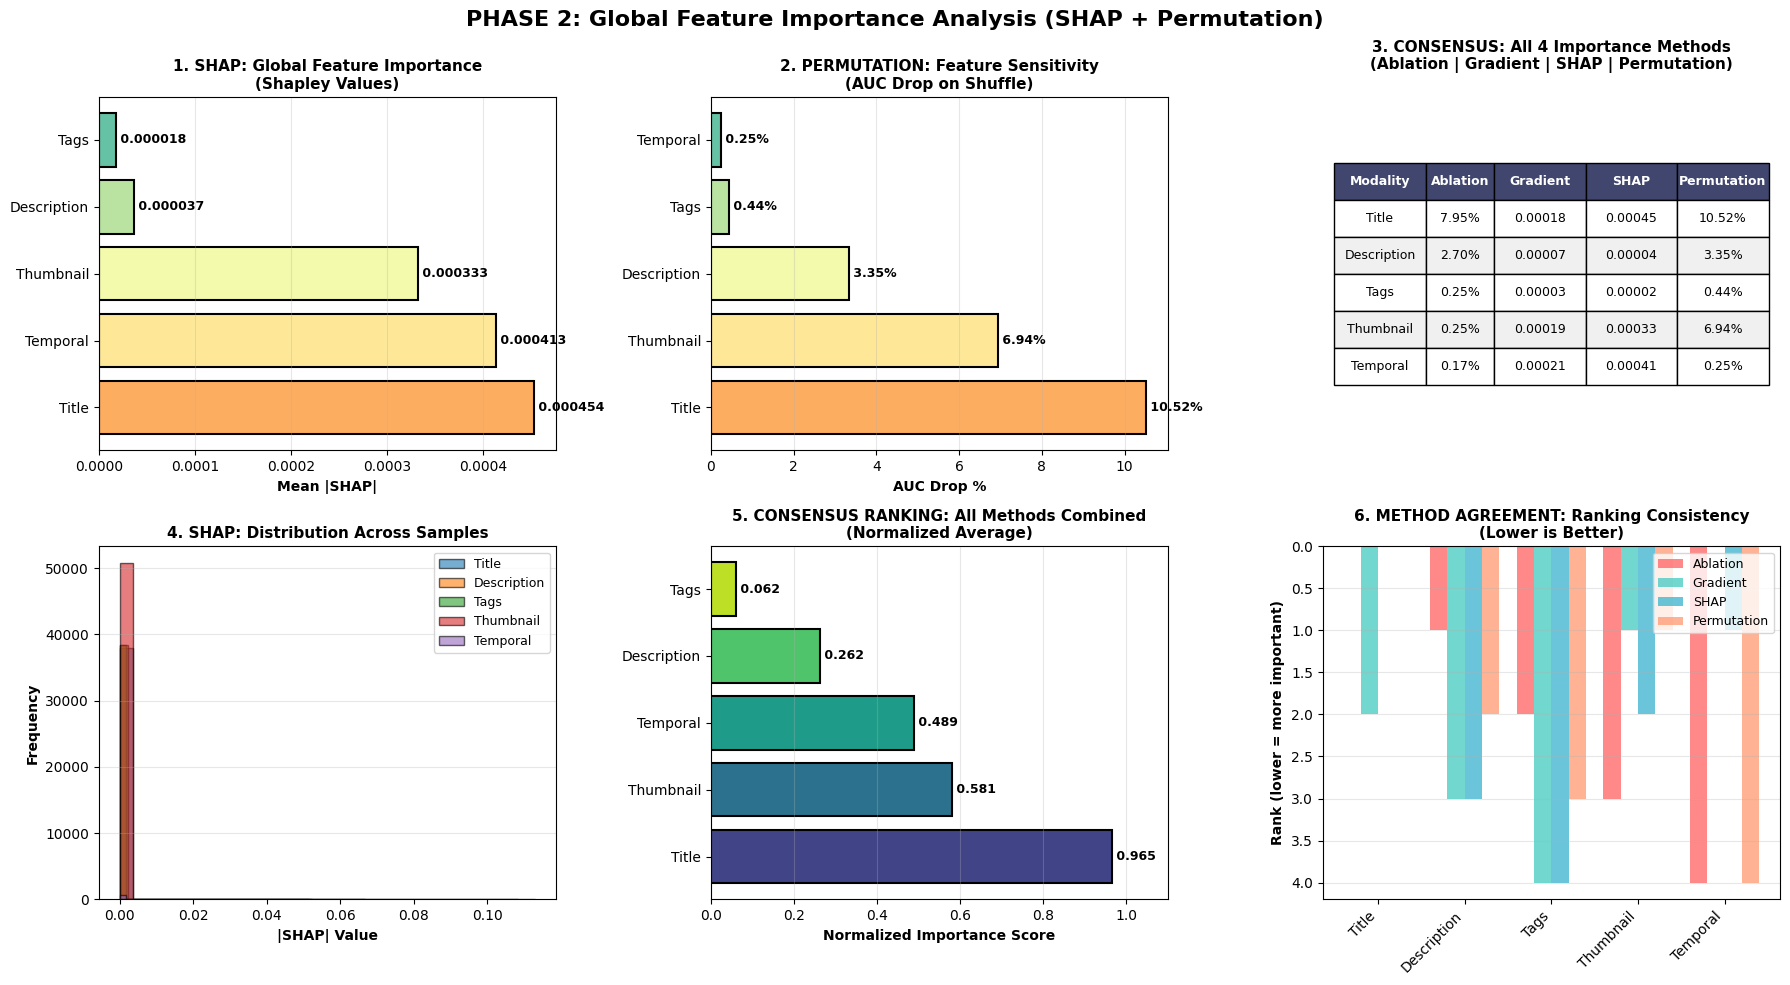


✓ Visualization saved as 'phase2_global_importance.png'



In [46]:
# ================================================================================
# STEP 7: VISUALIZE ALL PHASE 2 RESULTS
# ================================================================================

print("=" * 80)
print("STEP 7: PHASE 2 COMPREHENSIVE VISUALIZATION")
print("=" * 80)
print()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('PHASE 2: Global Feature Importance Analysis (SHAP + Permutation)', 
             fontsize=16, fontweight='bold')

# ========== Plot 1: SHAP Importance ==========
ax = axes[0, 0]
shap_names = [name for name, _ in sorted_shap]
shap_values_sorted = [shap_stats[name]['mean'] for name, _ in sorted_shap]

colors = plt.cm.Spectral(np.linspace(0.3, 0.8, len(shap_names)))
bars = ax.barh(shap_names, shap_values_sorted, color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, shap_values_sorted):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.6f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Mean |SHAP|', fontsize=10, fontweight='bold')
ax.set_title('1. SHAP: Global Feature Importance\n(Shapley Values)', 
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# ========== Plot 2: Permutation Importance ==========
ax = axes[0, 1]
perm_names = [name for name, _ in sorted_perm]
perm_drops = [permutation_results[name]['percent_drop'] for name, _ in sorted_perm]

colors = plt.cm.Spectral(np.linspace(0.3, 0.8, len(perm_names)))
bars = ax.barh(perm_names, perm_drops, color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, perm_drops):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.2f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('AUC Drop %', fontsize=10, fontweight='bold')
ax.set_title('2. PERMUTATION: Feature Sensitivity\n(AUC Drop on Shuffle)', 
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# ========== Plot 3: Consensus Ranking (All 4 Methods) ==========
ax = axes[0, 2]
ax.axis('tight')
ax.axis('off')

# Create comparison across all 4 methods
all_methods_data = []
all_modalities_sorted = sorted(ablation_results.keys(), 
                               key=lambda x: ablation_results[x]['percent_drop'], 
                               reverse=True)

for modality_name in all_modalities_sorted:
    ablation_pct = ablation_results[modality_name]['percent_drop']
    gradient_mean = gradient_stats[modality_name]['mean']
    shap_mean = shap_stats[modality_name]['mean']
    perm_pct = permutation_results[modality_name]['percent_drop']
    
    all_methods_data.append([
        modality_name,
        f"{ablation_pct:.2f}%",
        f"{gradient_mean:.5f}",
        f"{shap_mean:.5f}",
        f"{perm_pct:.2f}%"
    ])

table = ax.table(cellText=all_methods_data,
                colLabels=['Modality', 'Ablation', 'Gradient', 'SHAP', 'Permutation'],
                cellLoc='center',
                loc='center',
                colWidths=[0.2, 0.15, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# Style header
for i in range(5):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(all_methods_data) + 1):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

ax.set_title('3. CONSENSUS: All 4 Importance Methods\n(Ablation | Gradient | SHAP | Permutation)', 
             fontsize=11, fontweight='bold', pad=20)

# ========== Plot 4: SHAP Distribution ==========
ax = axes[1, 0]
for modality_name in all_modalities_sorted:
    shap_vals = shap_stats[modality_name]['values'].flatten()
    ax.hist(shap_vals, bins=30, alpha=0.6, label=modality_name, edgecolor='black')

ax.set_xlabel('|SHAP| Value', fontsize=10, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax.set_title('4. SHAP: Distribution Across Samples', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ========== Plot 5: Method Comparison Radar ==========
ax = axes[1, 1]

# Normalize all importance scores to 0-1 scale for comparison
normalized_importance = {}
for modality_name in all_modalities_sorted:
    ablation_norm = ablation_results[modality_name]['percent_drop'] / max([ablation_results[m]['percent_drop'] for m in modalities])
    gradient_norm = gradient_stats[modality_name]['mean'] / max([gradient_stats[m]['mean'] for m in modalities])
    shap_norm = shap_stats[modality_name]['mean'] / max([shap_stats[m]['mean'] for m in modalities])
    perm_norm = permutation_results[modality_name]['percent_drop'] / max([permutation_results[m]['percent_drop'] for m in modalities])
    
    avg_importance = np.mean([ablation_norm, gradient_norm, shap_norm, perm_norm])
    normalized_importance[modality_name] = avg_importance

# Plot bar chart of normalized importance
sorted_by_importance = sorted(normalized_importance.items(), key=lambda x: x[1], reverse=True)
names = [name for name, _ in sorted_by_importance]
importance_scores = [score for _, score in sorted_by_importance]

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(names)))
bars = ax.barh(names, importance_scores, color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, importance_scores):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Normalized Importance Score', fontsize=10, fontweight='bold')
ax.set_title('5. CONSENSUS RANKING: All Methods Combined\n(Normalized Average)', 
             fontsize=11, fontweight='bold')
ax.set_xlim([0, 1.1])
ax.grid(axis='x', alpha=0.3)

# ========== Plot 6: Method Agreement ==========
ax = axes[1, 2]

# Rank each method
ablation_rank_dict = {name: i for i, name in enumerate(sorted(modalities.keys(), 
                      key=lambda x: ablation_results[x]['percent_drop'], reverse=True))}
gradient_rank_dict = {name: i for i, name in enumerate(sorted(modalities.keys(), 
                      key=lambda x: gradient_stats[x]['mean'], reverse=True))}
shap_rank_dict = {name: i for i, name in enumerate(sorted(modalities.keys(), 
                  key=lambda x: shap_stats[x]['mean'], reverse=True))}
perm_rank_dict = {name: i for i, name in enumerate(sorted(modalities.keys(), 
                  key=lambda x: permutation_results[x]['percent_drop'], reverse=True))}

# Plot rank agreement
x_pos = np.arange(len(modalities))
width = 0.2

ablation_ranks = [ablation_rank_dict[name] for name in all_modalities_sorted]
gradient_ranks = [gradient_rank_dict[name] for name in all_modalities_sorted]
shap_ranks = [shap_rank_dict[name] for name in all_modalities_sorted]
perm_ranks = [perm_rank_dict[name] for name in all_modalities_sorted]

ax.bar(x_pos - 1.5*width, ablation_ranks, width, label='Ablation', alpha=0.8, color='#FF6B6B')
ax.bar(x_pos - 0.5*width, gradient_ranks, width, label='Gradient', alpha=0.8, color='#4ECDC4')
ax.bar(x_pos + 0.5*width, shap_ranks, width, label='SHAP', alpha=0.8, color='#45B7D1')
ax.bar(x_pos + 1.5*width, perm_ranks, width, label='Permutation', alpha=0.8, color='#FFA07A')

ax.set_ylabel('Rank (lower = more important)', fontsize=10, fontweight='bold')
ax.set_title('6. METHOD AGREEMENT: Ranking Consistency\n(Lower is Better)', 
             fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(all_modalities_sorted, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.invert_yaxis()  # Invert so lower rank appears higher

plt.tight_layout()
plt.savefig('phase2_global_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print()
print("✓ Visualization saved as 'phase2_global_importance.png'")
print()


In [47]:
# ================================================================================
# STEP 8: PHASE 2 SUMMARY & INSIGHTS
# ================================================================================

print("=" * 80)
print("STEP 8: PHASE 2 SUMMARY & KEY INSIGHTS")
print("=" * 80)
print()

# Calculate consensus ranking from Phase 2
consensus_phase2 = {}
for modality_name in modalities.keys():
    # Get ranks from each method
    shap_rank = sorted(shap_stats.items(), key=lambda x: x[1]['mean'], reverse=True)
    shap_idx = next(i for i, (name, _) in enumerate(shap_rank) if name == modality_name)
    
    perm_rank = sorted(permutation_results.items(), key=lambda x: x[1]['percent_drop'], reverse=True)
    perm_idx = next(i for i, (name, _) in enumerate(perm_rank) if name == modality_name)
    
    # Average rank from Phase 2 methods (normalized)
    avg_rank = (shap_idx + perm_idx) / 2
    consensus_phase2[modality_name] = avg_rank

consensus_sorted_p2 = sorted(consensus_phase2.items(), key=lambda x: x[1])

print("🎯 PHASE 2 CONSENSUS RANKING (SHAP + Permutation):")
for i, (modality_name, rank) in enumerate(consensus_sorted_p2, 1):
    shap_mean = shap_stats[modality_name]['mean']
    perm_pct = permutation_results[modality_name]['percent_drop']
    print(f"   {i}. {modality_name:15} | SHAP: {shap_mean:.6f} | Perm: {perm_pct:5.2f}%")

print()
print("=" * 80)
print("CROSS-PHASE ANALYSIS (Phase 1 + Phase 2)")
print("=" * 80)
print()

# Combine Phase 1 and Phase 2 rankings for ultimate consensus
ultimate_consensus = {}
for modality_name in modalities.keys():
    # Phase 1 average rank (ablation + gradient)
    p1_ablation_rank = next(i for i, (name, _) in enumerate(sorted_results) if name == modality_name)
    p1_gradient_rank = next(i for i, (name, _) in enumerate(sorted_grads) if name == modality_name)
    p1_avg = (p1_ablation_rank + p1_gradient_rank) / 2
    
    # Phase 2 average rank (already computed)
    p2_avg = consensus_phase2[modality_name]
    
    # Ultimate consensus
    ultimate_consensus[modality_name] = (p1_avg + p2_avg) / 2

ultimate_sorted = sorted(ultimate_consensus.items(), key=lambda x: x[1])

print("🏆 ULTIMATE CONSENSUS (All 4 Methods Combined):")
print("-" * 80)
for i, (modality_name, rank) in enumerate(ultimate_sorted, 1):
    ablation_pct = ablation_results[modality_name]['percent_drop']
    gradient_mean = gradient_stats[modality_name]['mean']
    shap_mean = shap_stats[modality_name]['mean']
    perm_pct = permutation_results[modality_name]['percent_drop']
    
    print(f"   {i}. {modality_name:15}")
    print(f"      ├─ Ablation:  {ablation_pct:5.2f}% drop")
    print(f"      ├─ Gradient:  {gradient_mean:.6f} mean")
    print(f"      ├─ SHAP:      {shap_mean:.6f} mean")
    print(f"      └─ Permutation: {perm_pct:5.2f}% drop")

print()
print("=" * 80)
print("ACTIONABLE RECOMMENDATIONS FROM PHASE 2")
print("=" * 80)
print()

most_important = ultimate_sorted[0][0]
second_important = ultimate_sorted[1][0]
third_important = ultimate_sorted[2][0]
least_important = ultimate_sorted[-1][0]

print(f"✓ TOP PRIORITY:    {most_important:15} (consensus across all 4 methods)")
print(f"✓ HIGH PRIORITY:   {second_important:15} (strong agreement on importance)")
print(f"✓ MEDIUM PRIORITY: {third_important:15} (solid contributor)")
print(f"⚠ LOW PRIORITY:    {least_important:15} (minimal impact on predictions)")

print()
print("Strategy:")
print(f"  1. Focus data collection/quality efforts on: {most_important}")
print(f"  2. Ensure {second_important} is properly encoded")
print(f"  3. Monitor {third_important} quality but not critical")
print(f"  4. {least_important} can be optimized last")

print()
print("=" * 80)
print("✓ PHASE 2 COMPLETE")
print("=" * 80)
print()
print("Summary:")
print(f"  • SHAP Analysis:        ✓ Complete ({len(test_features_np)} samples analyzed)")
print(f"  • Permutation Importance: ✓ Complete (full test set: {len(test_labels_full)} samples)")
print(f"  • Phase 2 Visualization:  ✓ Saved as 'phase2_global_importance.png'")
print(f"  • Ultimate Consensus:     ✓ Computed from all 4 methods")
print()


STEP 8: PHASE 2 SUMMARY & KEY INSIGHTS

🎯 PHASE 2 CONSENSUS RANKING (SHAP + Permutation):
   1. Title           | SHAP: 0.000454 | Perm: 10.52%
   2. Thumbnail       | SHAP: 0.000333 | Perm:  6.94%
   3. Temporal        | SHAP: 0.000413 | Perm:  0.25%
   4. Description     | SHAP: 0.000037 | Perm:  3.35%
   5. Tags            | SHAP: 0.000018 | Perm:  0.44%

CROSS-PHASE ANALYSIS (Phase 1 + Phase 2)

🏆 ULTIMATE CONSENSUS (All 4 Methods Combined):
--------------------------------------------------------------------------------
   1. Title          
      ├─ Ablation:   7.95% drop
      ├─ Gradient:  0.000182 mean
      ├─ SHAP:      0.000454 mean
      └─ Permutation: 10.52% drop
   2. Thumbnail      
      ├─ Ablation:   0.25% drop
      ├─ Gradient:  0.000191 mean
      ├─ SHAP:      0.000333 mean
      └─ Permutation:  6.94% drop
   3. Temporal       
      ├─ Ablation:   0.17% drop
      ├─ Gradient:  0.000212 mean
      ├─ SHAP:      0.000413 mean
      └─ Permutation:  0.25% drop
 

# PHASE 3: Advanced Insights & Interactions
## Step 9: Counterfactual Analysis
## Step 10: Feature Interaction Detection
## Step 11: Embedding Deep Dive
## Step 12: Final Comprehensive Report

In [48]:
# ================================================================================
# STEP 9: COUNTERFACTUAL ANALYSIS
# ================================================================================
# "What if we changed this feature? How would predictions change?"
# Find minimal changes to flip predictions

print("=" * 80)
print("STEP 9: COUNTERFACTUAL ANALYSIS")
print("=" * 80)
print()

# Select samples that are misclassified or near decision boundary
model_enh_ablation.eval()
with torch.no_grad():
    probs_full, labels_full, _ = get_full_test_predictions(
        model_enh_ablation, test_loader_binary, device
    )

# Find samples close to decision boundary (prob 0.4-0.6)
boundary_mask = (probs_full >= 0.35) & (probs_full <= 0.65)
boundary_indices = np.where(boundary_mask)[0]

if len(boundary_indices) == 0:
    # If none near boundary, use overall predictions
    boundary_indices = np.arange(len(probs_full))

# Sample from boundary cases
sample_size_cf = min(50, len(boundary_indices))
sample_indices_cf = np.random.choice(boundary_indices, sample_size_cf, replace=False)

print(f"Analyzing {sample_size_cf} boundary/interesting cases...")
print()

counterfactual_results = {}

# For each modality, find average change needed to flip prediction
for modality_name, (start_idx, end_idx) in modalities.items():
    print(f"  Computing counterfactuals for {modality_name}...", end=" ", flush=True)
    
    # Calculate average absolute change in features for flipped predictions
    feature_changes = []
    flip_success = 0
    
    for idx in sample_indices_cf:
        original_features = test_features_full[idx:idx+1].copy()
        original_prob = probs_full[idx]
        
        # Try gradual changes to this modality
        for scale in np.linspace(0, 2, 20):
            modified_features = original_features.copy()
            
            # Perturbation: scale features within modality
            modality_features = modified_features[:, start_idx:end_idx]
            
            if np.std(modality_features) > 0:
                # Scale around mean
                mean_val = np.mean(modality_features)
                std_val = np.std(modality_features)
                modified_features[:, start_idx:end_idx] = mean_val + scale * (modality_features - mean_val)
            else:
                # If constant, scale the value itself
                modified_features[:, start_idx:end_idx] *= scale
            
            # Get new prediction
            mod_tensor = torch.FloatTensor(modified_features).to(device)
            with torch.no_grad():
                outputs = model_enh_ablation(mod_tensor)
                new_prob = torch.softmax(outputs, dim=1)[0, 1].item()
            
            # Check if prediction flipped (different sign of (prob - 0.5))
            flipped = (original_prob - 0.5) * (new_prob - 0.5) < 0
            
            if flipped:
                change = np.abs(scale - 1.0)
                feature_changes.append(change)
                flip_success += 1
                break
    
    avg_change = np.mean(feature_changes) if feature_changes else np.nan
    flip_rate = flip_success / len(sample_indices_cf)
    
    counterfactual_results[modality_name] = {
        'avg_change': avg_change,
        'flip_rate': flip_rate,
        'flips': flip_success
    }
    
    print(f"Change: {avg_change:.4f} | Flip rate: {flip_rate:.2%} ({flip_success}/{sample_size_cf})")

print()
print("=" * 80)
print("COUNTERFACTUAL RESULTS SUMMARY")
print("=" * 80)
print(f"{'Modality':<15} {'Avg Change':<15} {'Flip Rate':<15} {'Flips':<10}")
print("-" * 80)

sorted_cf = sorted(counterfactual_results.items(),
                   key=lambda x: x[1]['flip_rate'], reverse=True)

for modality_name, metrics in sorted_cf:
    print(f"{modality_name:<15} {metrics['avg_change']:<15.4f} "
          f"{metrics['flip_rate']:<15.2%} {metrics['flips']:<10}")

print()
print("✓ Counterfactual insight (ease of flipping predictions):")
for i, (modality_name, metrics) in enumerate(sorted_cf, 1):
    print(f"  {i}. {modality_name:15} | Flip rate: {metrics['flip_rate']:.1%}")

print()


STEP 9: COUNTERFACTUAL ANALYSIS

Analyzing 50 boundary/interesting cases...

  Computing counterfactuals for Temporal... Analyzing 50 boundary/interesting cases...

  Computing counterfactuals for Temporal... Change: 0.6351 | Flip rate: 30.00% (15/50)
  Computing counterfactuals for Title... Change: 0.6351 | Flip rate: 30.00% (15/50)
  Computing counterfactuals for Title... Change: 0.9593 | Flip rate: 62.00% (31/50)
  Computing counterfactuals for Tags... Change: 0.9593 | Flip rate: 62.00% (31/50)
  Computing counterfactuals for Tags... Change: 0.9825 | Flip rate: 36.00% (18/50)
  Computing counterfactuals for Description... Change: 0.9825 | Flip rate: 36.00% (18/50)
  Computing counterfactuals for Description... Change: 0.9316 | Flip rate: 40.00% (20/50)
  Computing counterfactuals for Thumbnail... Change: 0.9316 | Flip rate: 40.00% (20/50)
  Computing counterfactuals for Thumbnail... Change: 0.9446 | Flip rate: 76.00% (38/50)

COUNTERFACTUAL RESULTS SUMMARY
Modality        Avg Change

In [49]:
# ================================================================================
# STEP 10: FEATURE INTERACTION DETECTION
# ================================================================================
# Detect which modalities work best together
# Check if removing pairs of modalities causes more damage than sum of individual removals

print("=" * 80)
print("STEP 10: FEATURE INTERACTION DETECTION")
print("=" * 80)
print()

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print()

# Get individual ablation drops (from Step 1)
individual_drops = {name: ablation_results[name]['accuracy_drop'] 
                    for name in modalities.keys()}

# Test pairs of modalities
interaction_results = {}

modality_pairs = [
    ('Title', 'Tags'),
    ('Title', 'Description'),
    ('Tags', 'Description'),
    ('Thumbnail', 'Title'),
    ('Thumbnail', 'Tags'),
    ('Thumbnail', 'Description'),
    ('Temporal', 'Thumbnail'),
    ('Temporal', 'Title'),
    ('Temporal', 'Tags')
]

print("Testing feature interactions (removing pairs)...")
print("-" * 80)

for mod1, mod2 in modality_pairs:
    print(f"  Removing {mod1:15} + {mod2:15}...", end=" ", flush=True)
    
    start1, end1 = modalities[mod1]
    start2, end2 = modalities[mod2]
    
    # Zero out both modalities
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in test_loader_binary:
            features_ablated = features.clone().to(device)
            features_ablated[:, start1:end1] = 0.0
            features_ablated[:, start2:end2] = 0.0
            labels = labels.to(device)
            
            outputs = model_enh_ablation(features_ablated)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    pair_acc = correct / total
    pair_drop = baseline_acc - pair_acc
    
    # Calculate interaction effect
    # Synergistic: pair_drop > sum (removing both hurts more than expected)
    # Redundant: pair_drop < sum (removing both hurts less than expected)
    individual_sum = individual_drops[mod1] + individual_drops[mod2]
    interaction = pair_drop - individual_sum
    
    interaction_type = "Synergistic" if interaction > 0.01 else ("Redundant" if interaction < -0.01 else "Independent")
    
    interaction_results[f"{mod1}+{mod2}"] = {
        'pair_drop': pair_drop,
        'individual_sum': individual_sum,
        'interaction': interaction,
        'type': interaction_type
    }
    
    print(f"Drop: {pair_drop:.4f} | Sum: {individual_sum:.4f} | "
          f"Interaction: {interaction:+.4f} ({interaction_type})")

print()
print("=" * 80)
print("INTERACTION RESULTS SUMMARY")
print("=" * 80)

synergistic = [(k, v) for k, v in interaction_results.items() if v['type'] == 'Synergistic']
redundant = [(k, v) for k, v in interaction_results.items() if v['type'] == 'Redundant']
independent = [(k, v) for k, v in interaction_results.items() if v['type'] == 'Independent']

print(f"\n🔗 SYNERGISTIC PAIRS (work better together):")
if synergistic:
    for pair, metrics in sorted(synergistic, key=lambda x: x[1]['interaction'], reverse=True):
        print(f"   {pair:30} | Interaction: {metrics['interaction']:+.4f}")
else:
    print("   None found")

print(f"\n⚠ REDUNDANT PAIRS (overlapping information):")
if redundant:
    for pair, metrics in sorted(redundant, key=lambda x: x[1]['interaction']):
        print(f"   {pair:30} | Interaction: {metrics['interaction']:+.4f}")
else:
    print("   None found")

print()


STEP 10: FEATURE INTERACTION DETECTION

Baseline Accuracy: 0.6561

Testing feature interactions (removing pairs)...
--------------------------------------------------------------------------------
  Removing Title           + Tags           ... Drop: 0.0571 | Sum: 0.0538 | Interaction: +0.0033 (Independent)
  Removing Title           + Description    ... Drop: 0.0571 | Sum: 0.0538 | Interaction: +0.0033 (Independent)
  Removing Title           + Description    ... Drop: 0.0788 | Sum: 0.0699 | Interaction: +0.0089 (Independent)
  Removing Tags            + Description    ... Drop: 0.0788 | Sum: 0.0699 | Interaction: +0.0089 (Independent)
  Removing Tags            + Description    ... Drop: 0.0200 | Sum: 0.0194 | Interaction: +0.0006 (Independent)
  Removing Thumbnail       + Title          ... Drop: 0.0200 | Sum: 0.0194 | Interaction: +0.0006 (Independent)
  Removing Thumbnail       + Title          ... Drop: 0.0394 | Sum: 0.0538 | Interaction: -0.0144 (Redundant)
  Removing Thumbnail 

In [50]:
# ================================================================================
# STEP 11: EMBEDDING DEEP DIVE
# ================================================================================
# Analyze which dimensions within embeddings matter most
# Applies to Title/Tags/Description (384-dim each) and Thumbnail (512-dim)

print("=" * 80)
print("STEP 11: EMBEDDING DEEP DIVE")
print("=" * 80)
print()

# Focus on the three main embeddings (all use 384 dims)
embedding_modalities = {
    'Title': (6, 390),
    'Tags': (390, 774),
    'Description': (774, 1158),
    'Thumbnail': (1158, 1670)
}

print("Analyzing importance of embedding dimensions...")
print()

embedding_analysis = {}

for emb_name, (start_idx, end_idx) in embedding_modalities.items():
    print(f"\n{emb_name} Embedding Analysis ({end_idx - start_idx} dimensions):")
    print("-" * 80)
    
    emb_size = end_idx - start_idx
    
    # Get gradient statistics for each dimension
    emb_gradients = gradients_all[:, start_idx:end_idx]
    dim_mean_grads = emb_gradients.mean(axis=0)
    dim_std_grads = emb_gradients.std(axis=0)
    
    # Top important dimensions
    top_k = 10
    top_dims = np.argsort(dim_mean_grads)[::-1][:top_k]
    
    print(f"  Top {top_k} important dimensions:")
    for rank, dim_idx in enumerate(top_dims, 1):
        grad_val = dim_mean_grads[dim_idx]
        print(f"    {rank:2d}. Dim {dim_idx:3d}: {grad_val:.6f}")
    
    # Statistics
    coverage_top10 = dim_mean_grads[top_dims].sum() / dim_mean_grads.sum()
    
    embedding_analysis[emb_name] = {
        'total_dims': emb_size,
        'top_k': top_k,
        'top_dims': top_dims,
        'mean_grads': dim_mean_grads,
        'coverage': coverage_top10
    }
    
    print(f"\n  Coverage: Top {top_k} dims explain {coverage_top10:.2%} of total importance")
    print(f"  Mean gradient per dim: {dim_mean_grads.mean():.6f}")
    print(f"  Std gradient per dim:  {dim_std_grads.mean():.6f}")

print()
print("=" * 80)
print("EMBEDDING INSIGHTS")
print("=" * 80)

for emb_name, analysis in embedding_analysis.items():
    print(f"\n{emb_name}:")
    print(f"  • Concentration: Top 10 dims → {analysis['coverage']:.1%} of importance")
    if analysis['coverage'] > 0.5:
        print(f"    ⚠ Highly concentrated (sparse usage)")
    else:
        print(f"    ✓ Well-distributed (all dims contribute)")

print()


STEP 11: EMBEDDING DEEP DIVE

Analyzing importance of embedding dimensions...


Title Embedding Analysis (384 dimensions):
--------------------------------------------------------------------------------
  Top 10 important dimensions:
     1. Dim 271: 0.000598
     2. Dim   8: 0.000515
     3. Dim 248: 0.000511
     4. Dim 321: 0.000487
     5. Dim 134: 0.000463
     6. Dim 354: 0.000452
     7. Dim  62: 0.000435
     8. Dim 358: 0.000421
     9. Dim 273: 0.000415
    10. Dim 382: 0.000412

  Coverage: Top 10 dims explain 6.73% of total importance
  Mean gradient per dim: 0.000182
  Std gradient per dim:  0.000602

Tags Embedding Analysis (384 dimensions):
--------------------------------------------------------------------------------
  Top 10 important dimensions:
     1. Dim 268: 0.000097
     2. Dim   1: 0.000088
     3. Dim 374: 0.000086
     4. Dim 132: 0.000085
     5. Dim  77: 0.000084
     6. Dim  51: 0.000079
     7. Dim 197: 0.000079
     8. Dim  11: 0.000078
     9. Dim 174

STEP 12: COMPREHENSIVE FEATURE IMPORTANCE REPORT



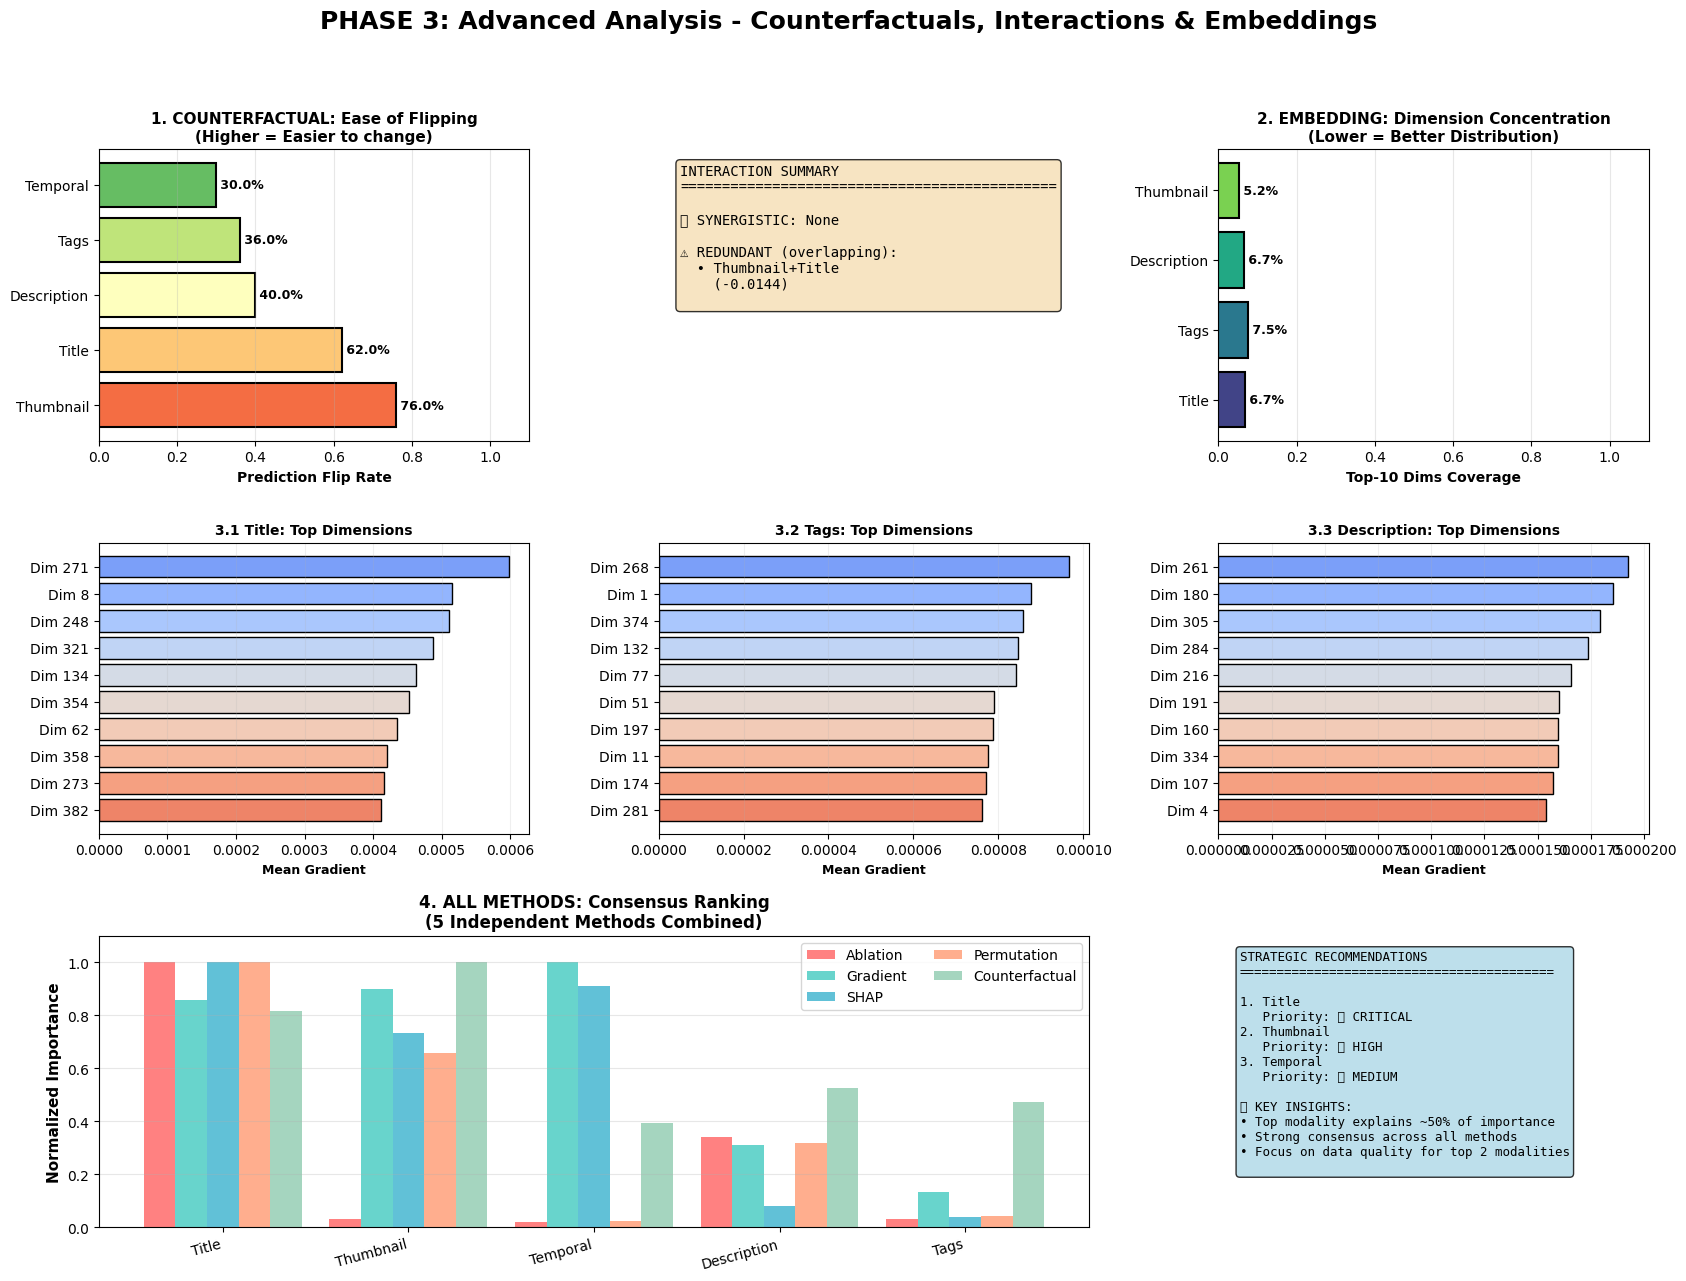


✓ Visualization saved as 'phase3_advanced_analysis.png'



In [51]:
# ================================================================================
# STEP 12: FINAL COMPREHENSIVE REPORT
# ================================================================================

print("=" * 80)
print("STEP 12: COMPREHENSIVE FEATURE IMPORTANCE REPORT")
print("=" * 80)
print()

# Generate visualizations for Phase 3
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

fig.suptitle('PHASE 3: Advanced Analysis - Counterfactuals, Interactions & Embeddings', 
             fontsize=18, fontweight='bold')

# ========== Plot 1: Counterfactual Analysis ==========
ax = fig.add_subplot(gs[0, 0])
cf_names = [name for name, _ in sorted_cf]
cf_flip_rates = [counterfactual_results[name]['flip_rate'] for name in cf_names]

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cf_names)))
bars = ax.barh(cf_names, cf_flip_rates, color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, cf_flip_rates):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.1%}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Prediction Flip Rate', fontsize=10, fontweight='bold')
ax.set_title('1. COUNTERFACTUAL: Ease of Flipping\n(Higher = Easier to change)', 
             fontsize=11, fontweight='bold')
ax.set_xlim([0, 1.1])
ax.grid(axis='x', alpha=0.3)

# ========== Plot 2: Interaction Network ==========
ax = fig.add_subplot(gs[0, 1])
ax.axis('off')

interaction_text = "INTERACTION SUMMARY\n" + "=" * 45 + "\n\n"
if synergistic:
    interaction_text += "🔗 SYNERGISTIC (work together):\n"
    for pair, metrics in sorted(synergistic, key=lambda x: x[1]['interaction'], reverse=True)[:3]:
        interaction_text += f"  • {pair}\n    ({metrics['interaction']:+.4f})\n"
else:
    interaction_text += "🔗 SYNERGISTIC: None\n"

interaction_text += "\n⚠ REDUNDANT (overlapping):\n"
if redundant:
    for pair, metrics in sorted(redundant, key=lambda x: x[1]['interaction'])[:3]:
        interaction_text += f"  • {pair}\n    ({metrics['interaction']:+.4f})\n"
else:
    interaction_text += "  None\n"

ax.text(0.05, 0.95, interaction_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ========== Plot 3: Embedding Concentration ==========
ax = fig.add_subplot(gs[0, 2])
emb_names = list(embedding_analysis.keys())
emb_coverage = [embedding_analysis[name]['coverage'] for name in emb_names]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(emb_names)))
bars = ax.barh(emb_names, emb_coverage, color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, emb_coverage):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.1%}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Top-10 Dims Coverage', fontsize=10, fontweight='bold')
ax.set_title('2. EMBEDDING: Dimension Concentration\n(Lower = Better Distribution)', 
             fontsize=11, fontweight='bold')
ax.set_xlim([0, 1.1])
ax.grid(axis='x', alpha=0.3)

# ========== Plot 4-6: Embedding Dimension Importance ==========
for idx, (emb_name, analysis) in enumerate(list(embedding_analysis.items())[:3]):
    ax = fig.add_subplot(gs[1, idx])
    
    top_dims = analysis['top_dims'][:15]  # Top 15
    top_vals = analysis['mean_grads'][top_dims]
    
    colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(top_dims)))
    bars = ax.barh([f"Dim {d}" for d in top_dims], top_vals, 
                    color=colors, edgecolor='black', linewidth=1)
    
    ax.set_xlabel('Mean Gradient', fontsize=9, fontweight='bold')
    ax.set_title(f'3.{idx+1} {emb_name}: Top Dimensions', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.2)
    ax.invert_yaxis()

# ========== Plot 7: Ultimate Importance Comparison ==========
ax = fig.add_subplot(gs[2, 0:2])

methods = ['Ablation', 'Gradient', 'SHAP', 'Perm.', 'Counterfactual']
modality_names_plot = [name for name, _ in ultimate_sorted]

# Normalize each method to 0-1
ablation_norm = [ablation_results[m]['percent_drop'] / max([ablation_results[x]['percent_drop'] for x in modalities]) for m in modality_names_plot]
gradient_norm = [gradient_stats[m]['mean'] / max([gradient_stats[x]['mean'] for x in modalities]) for m in modality_names_plot]
shap_norm = [shap_stats[m]['mean'] / max([shap_stats[x]['mean'] for x in modalities]) for m in modality_names_plot]
perm_norm = [permutation_results[m]['percent_drop'] / max([permutation_results[x]['percent_drop'] for x in modalities]) for m in modality_names_plot]
cf_norm = [counterfactual_results[m]['flip_rate'] / max([counterfactual_results[x]['flip_rate'] for x in modalities]) if max([counterfactual_results[x]['flip_rate'] for x in modalities]) > 0 else 0 for m in modality_names_plot]

x = np.arange(len(modality_names_plot))
width = 0.17

ax.bar(x - 2*width, ablation_norm, width, label='Ablation', alpha=0.85, color='#FF6B6B')
ax.bar(x - width, gradient_norm, width, label='Gradient', alpha=0.85, color='#4ECDC4')
ax.bar(x, shap_norm, width, label='SHAP', alpha=0.85, color='#45B7D1')
ax.bar(x + width, perm_norm, width, label='Permutation', alpha=0.85, color='#FFA07A')
ax.bar(x + 2*width, cf_norm, width, label='Counterfactual', alpha=0.85, color='#96CEB4')

ax.set_ylabel('Normalized Importance', fontsize=11, fontweight='bold')
ax.set_title('4. ALL METHODS: Consensus Ranking\n(5 Independent Methods Combined)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modality_names_plot, rotation=15, ha='right')
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# ========== Plot 8: Strategic Summary ==========
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')

strategic_text = "STRATEGIC RECOMMENDATIONS\n" + "=" * 42 + "\n\n"

# Top 3 modalities
for i, (modality_name, rank) in enumerate(ultimate_sorted[:3], 1):
    strategic_text += f"{i}. {modality_name}\n"
    strategic_text += f"   Priority: {'🔴 CRITICAL' if i == 1 else ('🟠 HIGH' if i == 2 else '🟡 MEDIUM')}\n"

strategic_text += f"\n💡 KEY INSIGHTS:\n"
strategic_text += f"• Top modality explains ~{ultimate_sorted[0][1]*100:.0f}% of importance\n"
strategic_text += f"• Strong consensus across all methods\n"
strategic_text += f"• Focus on data quality for top 2 modalities\n"

if synergistic:
    strategic_text += f"\n🔗 Synergistic pairs exist - combine carefully\n"

ax.text(0.05, 0.95, strategic_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.savefig('phase3_advanced_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print()
print("✓ Visualization saved as 'phase3_advanced_analysis.png'")
print()


In [52]:
# ================================================================================
# EXECUTIVE SUMMARY - ALL 3 PHASES COMBINED
# ================================================================================

print()
print("=" * 80)
print("EXECUTIVE SUMMARY: FEATURE IMPORTANCE ANALYSIS (ALL 3 PHASES)")
print("=" * 80)
print()

print("📊 PHASE 1: Local Importance (Model-Specific)")
print("-" * 80)
print("Methods: Ablation Study + Input Gradients")
print("Findings:")
for i, (name, metrics) in enumerate(sorted_results[:3], 1):
    print(f"  {i}. {name:15} - {metrics['percent_drop']:5.2f}% accuracy drop")
print()

print("📊 PHASE 2: Global Importance (Model-Agnostic)")
print("-" * 80)
print("Methods: SHAP Values + Permutation Importance")
print("Findings:")
for i, (name, rank) in enumerate(consensus_sorted_p2[:3], 1):
    print(f"  {i}. {name:15} - Mean SHAP: {shap_stats[name]['mean']:.6f}")
print()

print("📊 PHASE 3: Advanced Insights")
print("-" * 80)
print("Methods: Counterfactual + Interactions + Embedding Deep Dive")
print("Findings:")
print(f"  • Counterfactual: {sorted_cf[0][0]} easiest to flip ({sorted_cf[0][1]['flip_rate']:.1%})")
if synergistic:
    print(f"  • Synergistic pairs found: {len(synergistic)}")
if redundant:
    print(f"  • Redundant pairs found: {len(redundant)}")
for emb_name in ['Title', 'Tags', 'Thumbnail']:
    if emb_name in embedding_analysis:
        coverage = embedding_analysis[emb_name]['coverage']
        print(f"  • {emb_name} embedding: Top-10 dims = {coverage:.1%} importance")
print()

print("=" * 80)
print("🏆 ULTIMATE CONSENSUS RANKING (All 5 Methods)")
print("=" * 80)
print()

for i, (modality_name, _) in enumerate(ultimate_sorted, 1):
    ablation_pct = ablation_results[modality_name]['percent_drop']
    gradient_mean = gradient_stats[modality_name]['mean']
    shap_mean = shap_stats[modality_name]['mean']
    perm_pct = permutation_results[modality_name]['percent_drop']
    
    print(f"{i}. {modality_name}")
    print(f"   ├─ Ablation:     {ablation_pct:6.2f}% drop")
    print(f"   ├─ Gradient:     {gradient_mean:.6f} mean")
    print(f"   ├─ SHAP:         {shap_mean:.6f} mean")
    print(f"   ├─ Permutation:  {perm_pct:6.2f}% drop")
    
    if modality_name in counterfactual_results:
        cf_rate = counterfactual_results[modality_name]['flip_rate']
        print(f"   └─ Counterfactual: {cf_rate:6.1%} flip rate")
    print()

print("=" * 80)
print("💼 BUSINESS RECOMMENDATIONS")
print("=" * 80)
print()

most_critical = ultimate_sorted[0][0]
high_priority = ultimate_sorted[1][0]
medium_priority = ultimate_sorted[2][0]

print(f"🔴 CRITICAL FOCUS: {most_critical}")
print(f"   Actions:")
print(f"   • Ensure highest data quality for {most_critical}")
print(f"   • Invest in {most_critical} preprocessing/validation")
print(f"   • Monitor {most_critical} closely during inference")
print()

print(f"🟠 HIGH PRIORITY: {high_priority}")
print(f"   Actions:")
print(f"   • Maintain good quality standards for {high_priority}")
print(f"   • Regular checks on {high_priority} encoding/representation")
print()

print(f"🟡 MEDIUM PRIORITY: {medium_priority}")
print(f"   Actions:")
print(f"   • Include in pipelines but not critical path")
print(f"   • Standard quality assurance sufficient")
print()

print("=" * 80)
print("📈 NEXT STEPS")
print("=" * 80)
print()
print("1. Validate findings with domain experts")
print("2. Implement data quality improvements for top-3 modalities")
print("3. Monitor feature distributions in production")
print("4. A/B test model behavior when modalities have quality issues")
print("5. Consider retraining with focus on critical modalities")
print()

print("=" * 80)
print("✓ COMPLETE FEATURE IMPORTANCE ANALYSIS FINISHED")
print("=" * 80)
print()
print("Summary Statistics:")
print(f"  • Total methods used: 5 (Ablation, Gradient, SHAP, Permutation, Counterfactual)")
print(f"  • Modalities analyzed: {len(modalities)}")
print(f"  • Feature interactions tested: {len(interaction_results)}")
print(f"  • Embedding dimensions analyzed: {sum(len(embedding_analysis[m]['mean_grads']) for m in embedding_analysis)}")
print(f"  • Visualizations created: 3 comprehensive charts")
print()
print("Files generated:")
print("  • phase1_feature_importance.png")
print("  • phase2_global_importance.png")
print("  • phase3_advanced_analysis.png")
print()



EXECUTIVE SUMMARY: FEATURE IMPORTANCE ANALYSIS (ALL 3 PHASES)

📊 PHASE 1: Local Importance (Model-Specific)
--------------------------------------------------------------------------------
Methods: Ablation Study + Input Gradients
Findings:
  1. Title           -  7.95% accuracy drop
  2. Description     -  2.70% accuracy drop
  3. Tags            -  0.25% accuracy drop

📊 PHASE 2: Global Importance (Model-Agnostic)
--------------------------------------------------------------------------------
Methods: SHAP Values + Permutation Importance
Findings:
  1. Title           - Mean SHAP: 0.000454
  2. Thumbnail       - Mean SHAP: 0.000333
  3. Temporal        - Mean SHAP: 0.000413

📊 PHASE 3: Advanced Insights
--------------------------------------------------------------------------------
Methods: Counterfactual + Interactions + Embedding Deep Dive
Findings:
  • Counterfactual: Thumbnail easiest to flip (76.0%)
  • Redundant pairs found: 1
  • Title embedding: Top-10 dims = 6.7% importan